## Quantum Run - Maxcut GSet

We use polar coordinates for opt, mf density = Tensor_prod($\rho_i$), each density = 1/2 (I + $x_i \sigma_x + z_i \sigma_z$)

$x_i = R_i \sin{\theta_i} \ $
$z_i = R_i \cos{\theta_i}$

Try with both Adam, SGD and RMSprop, right now test with same params as vanilla run for direct performance benchmarking, hyperparams are already defined in the very beginning.

In [7]:
from pathlib import Path
import time
import math

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [9]:
DATA_GSET_DIR = Path("../data-gset")

VANILLA_RESULTS_PATH = Path("naive_vanilla_fem_G1-G54_full_results.csv")
VALIDATION_PATH = Path("gset_validation.txt")

OUTPUT_DIR = Path("qefem_v1_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

### Use same settings as naive vanilla for gset maxcut

In [10]:
N_STEPS = 1000
REPLICAS = 128
SEED = 0
PRINT_EVERY = 100

DTYPE = torch.float32

BETA_MIN = 2.0
BETA_MAX = 12500.0
BETA_SCHEDULE_KIND = "linear"

LR = 0.01
OPTIMIZER_NAME = "Adam"

For now just do linear gamma, later try with poly/ exponent

In [11]:
# R is Bloch length. It must start small.
R_INIT = 1e-2

# theta starts near pi/2 so rx is initially active and rz is initially small.
THETA_CENTER = math.pi / 2
THETA_NOISE = 1e-3

# Gamma sanity test and real QEFEM schedule.
GAMMA_ZERO = 0.0

GAMMA_MAX = 1.0
GAMMA_MIN = 0.0
GAMMA_SCHEDULE_KIND = "linear"


print("\nGlobal settings:")
print("N_STEPS:", N_STEPS)
print("REPLICAS:", REPLICAS)
print("SEED:", SEED)
print("BETA:", BETA_MIN, "->", BETA_MAX)
print("LR:", LR)
print("R_INIT:", R_INIT)
print("THETA_CENTER:", THETA_CENTER)
print("THETA_NOISE:", THETA_NOISE)
print("GAMMA full schedule:", GAMMA_MAX, "->", GAMMA_MIN)


Global settings:
N_STEPS: 1000
REPLICAS: 128
SEED: 0
BETA: 2.0 -> 12500.0
LR: 0.01
R_INIT: 0.01
THETA_CENTER: 1.5707963267948966
THETA_NOISE: 0.001
GAMMA full schedule: 1.0 -> 0.0


#### Load Vanilla FEM baseline for comparison!

In [12]:
if not VANILLA_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find vanilla baseline CSV:\n{VANILLA_RESULTS_PATH.resolve()}\n\n"
        "Place naive_vanilla_fem_G1-G54_full_results.csv in the same directory as this notebook."
    )

vanilla_results_df = pd.read_csv(VANILLA_RESULTS_PATH)

print("Loaded vanilla baseline:")
print("Rows:", len(vanilla_results_df))
print("Columns:")
print(list(vanilla_results_df.columns))

Loaded vanilla baseline:
Rows: 54
Columns:
['batch', 'g_index', 'instance', 'N', 'edges', 'best_known_cut', 'vanilla_fem_best_cut', 'gap', 'accuracy', 'percent_accuracy', 'runtime_sec', 'best_replica', 'R', 'N_steps', 'beta_min', 'beta_max', 'schedule_kind', 'lr', 'seed']


In [13]:
display(vanilla_results_df.head())

,batch,g_index,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed
0,1,1,G1,800,19176,11624,11446.0,178.0,0.984687,98.468685,4.368305,10,128,1000,2.0,12500.0,linear,0.01,0
1,1,2,G2,800,19176,11620,11435.0,185.0,0.984079,98.407917,4.299664,55,128,1000,2.0,12500.0,linear,0.01,0
2,1,3,G3,800,19176,11622,11443.0,179.0,0.984598,98.459818,4.356321,14,128,1000,2.0,12500.0,linear,0.01,0
3,1,4,G4,800,19176,11646,11503.0,143.0,0.987721,98.772111,4.275009,75,128,1000,2.0,12500.0,linear,0.01,0
4,1,5,G5,800,19176,11631,11450.0,181.0,0.984438,98.443814,4.161925,106,128,1000,2.0,12500.0,linear,0.01,0


In [14]:
vanilla_compare_df = vanilla_results_df.copy()

# Keep only the comparison columns we actually need.
vanilla_compare_df = vanilla_compare_df[
    [
        "instance",
        "N",
        "edges",
        "best_known_cut",
        "vanilla_fem_best_cut",
        "gap",
        "accuracy",
        "percent_accuracy",
        "runtime_sec",
    ]
].rename(
    columns={
        "N": "nodes",
        "best_known_cut": "best_value",
        "vanilla_fem_best_cut": "vanilla_cut",
        "gap": "vanilla_gap",
        "accuracy": "vanilla_accuracy",
        "percent_accuracy": "vanilla_percent_accuracy",
        "runtime_sec": "vanilla_tts_seconds",
    }
)

vanilla_compare_df["instance"] = vanilla_compare_df["instance"].astype(str)

print("\nStandardized vanilla comparison dataframe:")


Standardized vanilla comparison dataframe:


In [15]:
display(vanilla_compare_df.head())

,instance,nodes,edges,best_value,vanilla_cut,vanilla_gap,vanilla_accuracy,vanilla_percent_accuracy,vanilla_tts_seconds
0,G1,800,19176,11624,11446.0,178.0,0.984687,98.468685,4.368305
1,G2,800,19176,11620,11435.0,185.0,0.984079,98.407917,4.299664
2,G3,800,19176,11622,11443.0,179.0,0.984598,98.459818,4.356321
3,G4,800,19176,11646,11503.0,143.0,0.987721,98.772111,4.275009
4,G5,800,19176,11631,11450.0,181.0,0.984438,98.443814,4.161925


### GSet historical validation table

In [16]:
if not VALIDATION_PATH.exists():
    raise FileNotFoundError(
        f"Could not find validation file:\n{VALIDATION_PATH.resolve()}\n\n"
        "Place gset_validation.txt in the same directory as this notebook."
    )

records = []

with VALIDATION_PATH.open("r") as f:
    for line_no, line in enumerate(f, start=1):
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) != 2:
            raise ValueError(
                f"Bad line {line_no}: {line!r}. "
                "Expected format: <gset_index> <best_known_cut>"
            )

        g_index = int(parts[0])
        best_known_cut = int(parts[1])

        records.append(
            {
                "g_index": g_index,
                "instance": f"G{g_index}",
                "best_known_cut": best_known_cut,
            }
        )

gset_all_best_df = (
    pd.DataFrame(records)
    .sort_values("g_index")
    .reset_index(drop=True)
)

GSET_BEST_KNOWN_ALL = dict(
    zip(gset_all_best_df["instance"], gset_all_best_df["best_known_cut"])
)

print("\nLoaded Gset validation:")
print("Rows:", len(gset_all_best_df))
display(gset_all_best_df.head(10))


Loaded Gset validation:
Rows: 71


,g_index,instance,best_known_cut
0,1,G1,11624
1,2,G2,11620
2,3,G3,11622
3,4,G4,11646
4,5,G5,11631
5,6,G6,2178
6,7,G7,2006
7,8,G8,2005
8,9,G9,2054
9,10,G10,2000


In [17]:
merged_vanilla_validation_check = vanilla_compare_df.merge(
    gset_all_best_df[["instance", "best_known_cut"]],
    on="instance",
    how="left",
)

bad_rows = merged_vanilla_validation_check[
    merged_vanilla_validation_check["best_value"]
    != merged_vanilla_validation_check["best_known_cut"]
]

if len(bad_rows) > 0:
    print("\nWARNING: Vanilla CSV best-known values do not match gset_validation.txt:")
    display(bad_rows)
else:
    print("\nSanity check passed:")
    print("Vanilla CSV best-known values match gset_validation.txt.")


Sanity check passed:
Vanilla CSV best-known values match gset_validation.txt.


In [18]:
# ----------------------------
# Active benchmark scopes
# ----------------------------
GSET_G1_G10 = [f"G{i}" for i in range(1, 11)]
GSET_G1_G54 = [f"G{i}" for i in range(1, 55)]

print("\nBenchmark scopes:")
print("G1-G10:", GSET_G1_G10)


Benchmark scopes:
G1-G10: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']


#### Define Gset Batch partitions

In [19]:
GSET_BATCHES = {
    1: [f"G{i}" for i in range(1, 11)],    # G1-G10
    2: [f"G{i}" for i in range(11, 14)],   # G11-G13
    3: [f"G{i}" for i in range(14, 22)],   # G14-G21
    4: [f"G{i}" for i in range(22, 32)],   # G22-G31
    5: [f"G{i}" for i in range(32, 35)],   # G32-G34
    6: [f"G{i}" for i in range(35, 43)],   # G35-G42
    7: [f"G{i}" for i in range(43, 48)],   # G43-G47
    8: [f"G{i}" for i in range(48, 51)],   # G48-G50
    9: [f"G{i}" for i in range(51, 55)],   # G51-G54
}

print("Gset benchmark batches:")
for batch_id, instances in GSET_BATCHES.items():
    print(
        f"Batch {batch_id}: "
        f"{instances[0]}-{instances[-1]} | "
        f"{len(instances)} instances | "
        f"{instances}"
    )

Gset benchmark batches:
Batch 1: G1-G10 | 10 instances | ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Batch 2: G11-G13 | 3 instances | ['G11', 'G12', 'G13']
Batch 3: G14-G21 | 8 instances | ['G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21']
Batch 4: G22-G31 | 10 instances | ['G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31']
Batch 5: G32-G34 | 3 instances | ['G32', 'G33', 'G34']
Batch 6: G35-G42 | 8 instances | ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']
Batch 7: G43-G47 | 5 instances | ['G43', 'G44', 'G45', 'G46', 'G47']
Batch 8: G48-G50 | 3 instances | ['G48', 'G49', 'G50']
Batch 9: G51-G54 | 4 instances | ['G51', 'G52', 'G53', 'G54']


In [20]:
# ----------------------------
# Flatten full benchmark list
# ----------------------------
GSET_ALL_INSTANCES = []

for batch_id in sorted(GSET_BATCHES.keys()):
    GSET_ALL_INSTANCES.extend(GSET_BATCHES[batch_id])

print("\nTotal Gset instances in benchmark:", len(GSET_ALL_INSTANCES))
print("First instance:", GSET_ALL_INSTANCES[0])
print("Last instance:", GSET_ALL_INSTANCES[-1])


Total Gset instances in benchmark: 54
First instance: G1
Last instance: G54


In [21]:
# ----------------------------
# Sanity checks against validation and vanilla baseline
# ----------------------------
missing_from_validation = [
    instance for instance in GSET_ALL_INSTANCES
    if instance not in GSET_BEST_KNOWN_ALL
]

missing_from_vanilla = [
    instance for instance in GSET_ALL_INSTANCES
    if instance not in set(vanilla_compare_df["instance"])
]

if missing_from_validation:
    raise ValueError(
        "These benchmark instances are missing from gset_validation.txt:\n"
        f"{missing_from_validation}"
    )

if missing_from_vanilla:
    raise ValueError(
        "These benchmark instances are missing from vanilla baseline CSV:\n"
        f"{missing_from_vanilla}"
    )

print("\nSanity check passed:")
print("All G1-G54 instances exist in validation file and vanilla baseline CSV.")


# ----------------------------
# Useful scopes for later cells
# ----------------------------
GSET_SANITY_INSTANCE = "G1"
GSET_FIRST_SWEEP = GSET_BATCHES[1]
GSET_PROBLEM_BATCH = GSET_BATCHES[6]

print("\nUseful scopes:")
print("Single sanity instance:", GSET_SANITY_INSTANCE)
print("First sweep:", GSET_FIRST_SWEEP)
print("Problem batch:", GSET_PROBLEM_BATCH)


Sanity check passed:
All G1-G54 instances exist in validation file and vanilla baseline CSV.

Useful scopes:
Single sanity instance: G1
First sweep: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Problem batch: ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']


### Loading the adjacency matrix : 
First test with G1

In [22]:
def load_gset_dense(path, device=device, dtype=DTYPE, index_start=1):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find Gset file:\n{path.resolve()}")

    with path.open("r") as f:
        first = f.readline().strip().split()

        if len(first) != 2:
            raise ValueError(f"Bad first line in {path}: {first}")

        n, m = map(int, first)

        # Fill on CPU first. MPS scalar writes are slow and petty.
        W_cpu = torch.zeros((n, n), dtype=dtype, device="cpu")

        edge_count = 0
        total_weight_edges = 0.0
        positive_edges = 0
        negative_edges = 0
        zero_edges = 0
        self_edges = 0

        for line_id, line in enumerate(f, start=2):
            parts = line.strip().split()

            if not parts:
                continue

            if len(parts) != 3:
                raise ValueError(
                    f"Bad line {line_id} in {path}: {line!r}. "
                    "Expected format: i j w"
                )

            i_raw, j_raw, w_raw = parts

            i = int(i_raw) - index_start
            j = int(j_raw) - index_start
            w = float(w_raw)

            if not (0 <= i < n and 0 <= j < n):
                raise IndexError(
                    f"Node index out of range at line {line_id}: "
                    f"i={i}, j={j}, n={n}"
                )

            if i == j:
                self_edges += 1

            if w > 0:
                positive_edges += 1
            elif w < 0:
                negative_edges += 1
            else:
                zero_edges += 1

            W_cpu[i, j] = w
            W_cpu[j, i] = w

            edge_count += 1
            total_weight_edges += w

    W = W_cpu.to(device=device, dtype=dtype)

    with torch.no_grad():
        diag = torch.diag(W)
        W_sum = float(W.sum().detach().cpu())
        symmetric = bool(torch.allclose(W, W.T))
        diag_zero = bool(torch.allclose(diag, torch.zeros_like(diag)))
        nonzero_directed_entries = int(torch.count_nonzero(W).detach().cpu())

    info = {
        "path": str(path),
        "n": n,
        "m_header": m,
        "m_loaded": edge_count,
        "total_weight_edges": total_weight_edges,
        "positive_edges": positive_edges,
        "negative_edges": negative_edges,
        "zero_edges": zero_edges,
        "self_edges": self_edges,
        "W_sum": W_sum,
        "nonzero_directed_entries": nonzero_directed_entries,
        "expected_directed_entries": 2 * edge_count,
        "symmetric": symmetric,
        "diag_zero": diag_zero,
        "device": str(W.device),
        "dtype": str(W.dtype),
    }

    if edge_count != m:
        print(
            "WARNING: loaded edge count does not match header:",
            edge_count,
            "!=",
            m,
        )

    if not symmetric:
        print("WARNING: W is not symmetric. That is not cute.")

    if not diag_zero:
        print("WARNING: W diagonal is not zero.")

    return W, info

In [23]:
g1_path = DATA_GSET_DIR / "G1"

print("G1 path:", g1_path.resolve())
print("G1 exists?", g1_path.exists())

G1 path: /Users/ronit/Desktop/QeFEM/main/data-gset/G1
G1 exists? True


In [24]:
instance = GSET_SANITY_INSTANCE   # "G1"
gset_path = DATA_GSET_DIR / instance

print("Loading instance:", instance)
print("Path:", gset_path.resolve())


# ----------------------------
# Load dense W
# ----------------------------
W, graph_info = load_gset_dense(
    gset_path,
    device=device,
    dtype=DTYPE,
    index_start=1,
)

N = W.shape[0]
best_known = GSET_BEST_KNOWN_ALL[instance]


# ----------------------------
# Print graph metadata
# ----------------------------
print("\nGraph info:")
for key, value in graph_info.items():
    print(f"{key}: {value}")

print("\nBenchmark info:")
print("Instance:", instance)
print("N:", N)
print("Best-known cut:", best_known)

Loading instance: G1
Path: /Users/ronit/Desktop/QeFEM/main/data-gset/G1

Graph info:
path: ../data-gset/G1
n: 800
m_header: 19176
m_loaded: 19176
total_weight_edges: 19176.0
positive_edges: 19176
negative_edges: 0
zero_edges: 0
self_edges: 0
W_sum: 38352.0
nonzero_directed_entries: 38352
expected_directed_entries: 38352
symmetric: True
diag_zero: True
device: mps:0
dtype: torch.float32

Benchmark info:
Instance: G1
N: 800
Best-known cut: 11624


In [25]:
print("\nGraph info:")
for key, value in graph_info.items():
    print(f"{key}: {value}")

print("\nBenchmark info:")
print("Instance:", instance)
print("N:", N)
print("Best-known cut:", best_known)


# ----------------------------
# Hard sanity assertions
# ----------------------------
assert graph_info["m_loaded"] == graph_info["m_header"], (
    "Loaded edge count does not match header. "
    "Tiny loader goblin detected."
)

assert graph_info["symmetric"] is True, "W must be symmetric."

assert graph_info["diag_zero"] is True, "W diagonal must be zero."

assert graph_info["nonzero_directed_entries"] == graph_info["expected_directed_entries"], (
    "Directed nonzero entries should be exactly 2 * edge_count "
    "for a symmetric undirected graph."
)

assert instance in vanilla_compare_df["instance"].values, (
    f"{instance} missing from vanilla baseline dataframe."
)


# ----------------------------
# Pull vanilla baseline for this instance
# ----------------------------
vanilla_row = vanilla_compare_df.query("instance == @instance").iloc[0]

print("\nVanilla baseline for this instance:")
print("Vanilla cut:", vanilla_row["vanilla_cut"])
print("Vanilla best-known:", vanilla_row["best_value"])
print("Vanilla gap:", vanilla_row["vanilla_gap"])
print("Vanilla accuracy %:", vanilla_row["vanilla_percent_accuracy"])
print("Vanilla runtime sec:", vanilla_row["vanilla_tts_seconds"])


Graph info:
path: ../data-gset/G1
n: 800
m_header: 19176
m_loaded: 19176
total_weight_edges: 19176.0
positive_edges: 19176
negative_edges: 0
zero_edges: 0
self_edges: 0
W_sum: 38352.0
nonzero_directed_entries: 38352
expected_directed_entries: 38352
symmetric: True
diag_zero: True
device: mps:0
dtype: torch.float32

Benchmark info:
Instance: G1
N: 800
Best-known cut: 11624

Vanilla baseline for this instance:
Vanilla cut: 11446.0
Vanilla best-known: 11624
Vanilla gap: 178.0
Vanilla accuracy %: 98.46868547832072
Vanilla runtime sec: 4.368304967880249


### Define Cut function

In [26]:
def discrete_cut(W, spins):

    single_input = False

    if spins.dim() == 1:
        spins = spins.unsqueeze(0)
        single_input = True

    spins = spins.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum("ri,ij,rj->r", spins, W, spins)
    cut = 0.25 * (W.sum() - quad)

    if single_input:
        return cut.squeeze(0)

    return cut

### Define the Bloch parameterization

In [27]:
def bloch_from_raw(raw_R, theta):

    # R = sigmoid(raw_R) ---> trainable latent raw_R like fields give Bloch radius
    
    R = torch.sigmoid(raw_R)

    rx = R * torch.sin(theta)
    rz = R * torch.cos(theta)

    return R, rx, rz


def raw_R_from_init_value(R_init, device=device, dtype=DTYPE):
    """
    Convert a desired initial Bloch radius R_init into raw_R
    such that sigmoid(raw_R) = R_init.
    """
    
    # raw_R = logit(R) ---> opposite of previous function
    
    if not (0.0 < R_init < 1.0):
        raise ValueError("R_init must be strictly between 0 and 1. Humanity survives by constraints.")

    R_init_tensor = torch.tensor(R_init, device=device, dtype=dtype)
    raw_value = torch.logit(R_init_tensor)

    return raw_value

In [28]:
raw_R_test_value = raw_R_from_init_value(R_INIT)

raw_R_test = raw_R_test_value * torch.ones(
    REPLICAS,
    N,
    device=device,
    dtype=DTYPE,
)

theta_test = THETA_CENTER + THETA_NOISE * torch.randn(
    REPLICAS,
    N,
    device=device,
    dtype=DTYPE,
)

R_test, rx_test, rz_test = bloch_from_raw(raw_R_test, theta_test)

print("raw_R init value:", float(raw_R_test_value.detach().cpu()))
print("R_test shape:", R_test.shape)
print("rx_test shape:", rx_test.shape)
print("rz_test shape:", rz_test.shape)

print("\nInitial Bloch stats:")
print("R mean:", float(R_test.mean().detach().cpu()))
print("R min:", float(R_test.min().detach().cpu()))
print("R max:", float(R_test.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean:", float(rx_test.mean().detach().cpu()))
print("rx abs mean:", float(rx_test.abs().mean().detach().cpu()))
print("rz mean:", float(rz_test.mean().detach().cpu()))
print("rz abs mean:", float(rz_test.abs().mean().detach().cpu()))

# Since theta starts near pi/2:
# rx should be close to R_INIT, rz should be tiny.
assert torch.all(R_test > 0), "R must be positive."
assert torch.all(R_test < 1), "R must be less than 1."

raw_R init value: -4.595119476318359
R_test shape: torch.Size([128, 800])
rx_test shape: torch.Size([128, 800])
rz_test shape: torch.Size([128, 800])

Initial Bloch stats:
R mean: 0.01000000350177288
R min: 0.01000000350177288
R max: 0.01000000350177288

Initial component stats:
rx mean: 0.009999998845160007
rx abs mean: 0.009999998845160007
rz mean: -1.7262834717257647e-08
rz abs mean: 7.956688932608813e-06


### Define Quantum entropy

In [29]:
def quantum_entropy_from_R(R, eps=1e-12):

    single_input = False

    if R.dim() == 1:
        R = R.unsqueeze(0)
        single_input = True

    R = R.clamp(eps, 1.0 - eps)

    lambda_plus = 0.5 * (1.0 + R)
    lambda_minus = 0.5 * (1.0 - R)

    entropy_per_spin = -(
        lambda_plus * torch.log(lambda_plus)
        + lambda_minus * torch.log(lambda_minus)
    )

    entropy = entropy_per_spin.sum(dim=1)

    if single_input:
        return entropy.squeeze(0)

    return entropy

In [30]:
S_test = quantum_entropy_from_R(R_test)

print("Entropy shape:", S_test.shape)
print("Entropy mean:", float(S_test.mean().detach().cpu()))
print("Entropy min:", float(S_test.min().detach().cpu()))
print("Entropy max:", float(S_test.max().detach().cpu()))

# For R near 0, each qubit has entropy close to log(2).
max_entropy_per_replica = N * math.log(2.0)

print("\nTheoretical max entropy per replica, N log 2:")
print(max_entropy_per_replica)

print("\nEntropy mean / max entropy:")
print(float(S_test.mean().detach().cpu() / max_entropy_per_replica))

# R_INIT = 1e-2 should give entropy very close to N log 2.
assert torch.all(S_test > 0), "Entropy should be positive."
assert torch.all(S_test <= max_entropy_per_replica + 1e-3), (
    "Entropy exceeded N log 2. Entropy goblin detected."
)

Entropy shape: torch.Size([128])
Entropy mean: 554.4776611328125
Entropy min: 554.4776611328125
Entropy max: 554.4776611328125

Theoretical max entropy per replica, N log 2:
554.5177444479563

Entropy mean / max entropy:
0.9999276995658875


### Expected Cut

In [31]:
def quantum_expected_cut(W, rz):
    
    single_input = False

    if rz.dim() == 1:
        rz = rz.unsqueeze(0)
        single_input = True

    rz = rz.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum("ri,ij,rj->r", rz, W, rz)
    expected_cut = 0.25 * (W.sum() - quad)

    if single_input:
        return expected_cut.squeeze(0)

    return expected_cut

In [32]:
expected_cut_test = quantum_expected_cut(W, rz_test)

print("Expected cut shape:", expected_cut_test.shape)
print("Expected cut mean:", float(expected_cut_test.mean().detach().cpu()))
print("Expected cut min:", float(expected_cut_test.min().detach().cpu()))
print("Expected cut max:", float(expected_cut_test.max().detach().cpu()))

print("\nBest-known cut:", best_known)
print("Vanilla FEM cut:", vanilla_row["vanilla_cut"])

# Since rz starts close to 0, expected cut should be close to W.sum()/4.
soft_uniform_cut = 0.25 * float(W.sum().detach().cpu())

print("\nSoft uniform reference W.sum()/4:")
print(soft_uniform_cut)

print("\nMean expected cut - W.sum()/4:")       #should be 0 because E[C] = 1/4 (\sum W_ij - z^T W z)..... 
# z (init) -->0 thus diff => E[C] - 0.25 \sum W = 0 is expected...

print(float(expected_cut_test.mean().detach().cpu()) - soft_uniform_cut)

Expected cut shape: torch.Size([128])
Expected cut mean: 9588.0
Expected cut min: 9588.0
Expected cut max: 9588.0

Best-known cut: 11624
Vanilla FEM cut: 11446.0

Soft uniform reference W.sum()/4:
9588.0

Mean expected cut - W.sum()/4:
0.0


### Build the Transverse Mixer/ Driver

In [33]:
def transverse_driver_energy(rx, gamma):

    single_input = False

    if rx.dim() == 1:
        rx = rx.unsqueeze(0)
        single_input = True

    gamma = torch.as_tensor(
        gamma,
        device=rx.device,
        dtype=rx.dtype,
    )

    driver_energy = -gamma * rx.sum(dim=1)

    if single_input:
        return driver_energy.squeeze(0)

    return driver_energy

In [34]:
driver_zero_test = transverse_driver_energy(rx_test, gamma=0.0)
driver_full_test = transverse_driver_energy(rx_test, gamma=GAMMA_MAX)

print("Driver energy shape:", driver_full_test.shape)

print("\nGamma = 0 driver stats:")
print("mean:", float(driver_zero_test.mean().detach().cpu()))
print("min:", float(driver_zero_test.min().detach().cpu()))
print("max:", float(driver_zero_test.max().detach().cpu()))

print("\nGamma = 1 driver stats:")
print("mean:", float(driver_full_test.mean().detach().cpu()))
print("min:", float(driver_full_test.min().detach().cpu()))
print("max:", float(driver_full_test.max().detach().cpu()))

# With theta near pi/2 and R_INIT=1e-2:
# rx.sum() should be close to N * R_INIT.
expected_initial_driver = -GAMMA_MAX * N * R_INIT

print("\nExpected rough initial driver energy for gamma=1:")
print(expected_initial_driver)

print("\nObserved mean driver energy for gamma=1:")
print(float(driver_full_test.mean().detach().cpu()))

Driver energy shape: torch.Size([128])

Gamma = 0 driver stats:
mean: 0.0
min: -0.0
max: -0.0

Gamma = 1 driver stats:
mean: -7.999999046325684
min: -7.999999523162842
max: -7.999998092651367

Expected rough initial driver energy for gamma=1:
-8.0

Observed mean driver energy for gamma=1:
-7.999999046325684


In [35]:
assert torch.allclose(
    driver_zero_test,
    torch.zeros_like(driver_zero_test),
    atol=1e-6,
    rtol=1e-6,
), "Driver energy should be exactly zero when gamma=0. The transverse goblin is lying."

assert driver_full_test.mean() < 0, (
    "Initial driver energy should be negative because rx starts positive near pi/2."
)

------------------------------------------------------------------------------------------------------
## Building the QeFEM complete functional using : 
$F_{QMF} = - E[Q] - \Gamma \sum x_i - \frac{1}{\beta} S[Q]$

In [36]:
def qefem_free_energy_maxcut(W, raw_R, theta, beta, gamma):

    beta = torch.as_tensor(beta, device=W.device, dtype=W.dtype)
    gamma = torch.as_tensor(gamma, device=W.device, dtype=W.dtype)

    R, rx, rz = bloch_from_raw(raw_R, theta)

    expected_cut = quantum_expected_cut(W, rz)
    entropy = quantum_entropy_from_R(R)
    driver_energy = transverse_driver_energy(rx, gamma)

    internal_energy_cut = -expected_cut

    F = internal_energy_cut + driver_energy - entropy / beta

    aux = {
        "R": R,
        "rx": rx,
        "rz": rz,
        "expected_cut": expected_cut,
        "entropy": entropy,
        "driver_energy": driver_energy,
        "internal_energy_cut": internal_energy_cut,
        "free_energy": F,
        "beta": beta,
        "gamma": gamma,
    }

    return F, aux

In [37]:
beta_test = BETA_MIN
gamma_test_zero = 0.0
gamma_test_full = GAMMA_MAX

F_zero_test, aux_zero_test = qefem_free_energy_maxcut(
    W=W,
    raw_R=raw_R_test,
    theta=theta_test,
    beta=beta_test,
    gamma=gamma_test_zero,
)

F_full_test, aux_full_test = qefem_free_energy_maxcut(
    W=W,
    raw_R=raw_R_test,
    theta=theta_test,
    beta=beta_test,
    gamma=gamma_test_full,
)


print("Free energy shape:", F_zero_test.shape)

print("\nGamma = 0 initial stats:")
print("F mean:", float(F_zero_test.mean().detach().cpu()))
print("Expected cut mean:", float(aux_zero_test["expected_cut"].mean().detach().cpu()))
print("Entropy mean:", float(aux_zero_test["entropy"].mean().detach().cpu()))
print("Driver mean:", float(aux_zero_test["driver_energy"].mean().detach().cpu()))

print("\nGamma = 1 initial stats:")
print("F mean:", float(F_full_test.mean().detach().cpu()))
print("Expected cut mean:", float(aux_full_test["expected_cut"].mean().detach().cpu()))
print("Entropy mean:", float(aux_full_test["entropy"].mean().detach().cpu()))
print("Driver mean:", float(aux_full_test["driver_energy"].mean().detach().cpu()))

print("\nDifference F(gamma=1) - F(gamma=0):")
print(float((F_full_test.mean() - F_zero_test.mean()).detach().cpu()))

print("\nExpected rough driver shift:")
print(-GAMMA_MAX * N * R_INIT)

Free energy shape: torch.Size([128])

Gamma = 0 initial stats:
F mean: -9865.2392578125
Expected cut mean: 9588.0
Entropy mean: 554.4776611328125
Driver mean: 0.0

Gamma = 1 initial stats:
F mean: -9873.2392578125
Expected cut mean: 9588.0
Entropy mean: 554.4776611328125
Driver mean: -7.999999046325684

Difference F(gamma=1) - F(gamma=0):
-8.0

Expected rough driver shift:
-8.0


In [38]:
# ----------------------------
# Basic consistency checks
# ----------------------------
assert F_zero_test.shape == torch.Size([REPLICAS]), (
    "Free energy should return one value per replica."
)

assert torch.allclose(
    aux_zero_test["driver_energy"],
    torch.zeros_like(aux_zero_test["driver_energy"]),
    atol=1e-6,
    rtol=1e-6,
), "Driver energy should vanish when gamma=0."

assert aux_zero_test["expected_cut"].mean() > 0, (
    "Expected cut should be positive at initialization."
)

assert aux_zero_test["entropy"].mean() > 0, (
    "Entropy should be positive at initialization."
)

assert F_full_test.mean() < F_zero_test.mean(), (
    "With positive rx and gamma=1, driver should lower the free energy initially."
)

## Build annealing schedules!

In [39]:
def make_beta_schedule(
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    n_steps=N_STEPS,
    kind=BETA_SCHEDULE_KIND,
    device=device,
    dtype=DTYPE,
):
    # CONSISTENCY WITH VANILLA RUN USE SAME VALUES FOR BETA ANNEAL !!!
    
    if n_steps <= 0:
        raise ValueError("n_steps must be positive. Time must move, sadly.")

    if kind == "linear":
        beta_schedule = torch.linspace(
            beta_min,
            beta_max,
            n_steps,
            device=device,
            dtype=dtype,
        )

    elif kind == "exponential":
        if beta_min <= 0 or beta_max <= 0:
            raise ValueError("Exponential beta schedule needs positive beta_min and beta_max.")

        beta_schedule = torch.exp(
            torch.linspace(
                math.log(beta_min),
                math.log(beta_max),
                n_steps,
                device=device,
                dtype=dtype,
            )
        )

    else:
        raise ValueError(f"Unknown beta schedule kind: {kind}")

    return beta_schedule

In [40]:
def make_gamma_schedule(
    gamma_mode,
    gamma_max=GAMMA_MAX,
    gamma_min=GAMMA_MIN,
    n_steps=N_STEPS,
    kind=GAMMA_SCHEDULE_KIND,
    device=device,
    dtype=DTYPE,
):

    if n_steps <= 0:
        raise ValueError("n_steps must be positive. Even annealing needs time to suffer.")

    if gamma_mode == "zero":
        gamma_schedule = torch.zeros(
            n_steps,
            device=device,
            dtype=dtype,
        )

    elif gamma_mode == "anneal":
        if kind == "linear":
            gamma_schedule = torch.linspace(
                gamma_max,
                gamma_min,
                n_steps,
                device=device,
                dtype=dtype,
            )

        elif kind == "exponential":
            if gamma_min <= 0 or gamma_max <= 0:
                raise ValueError(
                    "Exponential gamma schedule needs positive gamma_min and gamma_max. "
                    "Use linear if gamma_min = 0."
                )

            gamma_schedule = torch.exp(
                torch.linspace(
                    math.log(gamma_max),
                    math.log(gamma_min),
                    n_steps,
                    device=device,
                    dtype=dtype,
                )
            )

        else:
            raise ValueError(f"Unknown gamma schedule kind: {kind}")

    else:
        raise ValueError(
            f"Unknown gamma_mode: {gamma_mode}. "
            "Use 'zero' or 'anneal'."
        )

    return gamma_schedule

In [41]:
# ----------------------------
# Build schedules
# ----------------------------
beta_schedule = make_beta_schedule()

gamma_zero_schedule = make_gamma_schedule(gamma_mode="zero")
gamma_anneal_schedule = make_gamma_schedule(gamma_mode="anneal")


# ----------------------------
# Print schedule sanity
# ----------------------------
print("Beta schedule:")
print("shape:", beta_schedule.shape)
print("first:", float(beta_schedule[0].detach().cpu()))
print("last:", float(beta_schedule[-1].detach().cpu()))

print("\nGamma zero schedule:")
print("shape:", gamma_zero_schedule.shape)
print("first:", float(gamma_zero_schedule[0].detach().cpu()))
print("last:", float(gamma_zero_schedule[-1].detach().cpu()))

print("\nGamma anneal schedule:")
print("shape:", gamma_anneal_schedule.shape)
print("first:", float(gamma_anneal_schedule[0].detach().cpu()))
print("last:", float(gamma_anneal_schedule[-1].detach().cpu()))

Beta schedule:
shape: torch.Size([1000])
first: 2.0
last: 12500.0

Gamma zero schedule:
shape: torch.Size([1000])
first: 0.0
last: 0.0

Gamma anneal schedule:
shape: torch.Size([1000])
first: 1.0
last: 0.0


In [42]:
assert beta_schedule.shape[0] == N_STEPS
assert gamma_zero_schedule.shape[0] == N_STEPS
assert gamma_anneal_schedule.shape[0] == N_STEPS

assert torch.all(beta_schedule > 0), "Beta must stay positive."

assert torch.allclose(
    gamma_zero_schedule,
    torch.zeros_like(gamma_zero_schedule),
), "gamma_mode='zero' should give all zeros."

assert gamma_anneal_schedule[0] == GAMMA_MAX, (
    "Annealed gamma schedule should start at GAMMA_MAX."
)

assert gamma_anneal_schedule[-1] == GAMMA_MIN, (
    "Annealed gamma schedule should end at GAMMA_MIN."
)

### Single SANITY run for G1

In [43]:
def initialize_qefem_variables(
    n,
    replicas=REPLICAS,
    seed=SEED,
    R_init=R_INIT,
    theta_center=THETA_CENTER,
    theta_noise=THETA_NOISE,
    device=device,
    dtype=DTYPE,
):

    torch.manual_seed(seed)

    raw_R_center = raw_R_from_init_value(
        R_init,
        device=device,
        dtype=dtype,
    )

    raw_R = raw_R_center + 1e-3 * torch.randn(
        replicas,
        n,
        device=device,
        dtype=dtype,
    )

    theta = theta_center + theta_noise * torch.randn(
        replicas,
        n,
        device=device,
        dtype=dtype,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    return raw_R, theta

def make_qefem_optimizer(raw_R, theta, lr=LR):

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=lr,
    )

    return optimizer

In [44]:
raw_R, theta = initialize_qefem_variables(
    n=N,
    replicas=REPLICAS,
    seed=SEED,
)

optimizer = make_qefem_optimizer(
    raw_R=raw_R,
    theta=theta,
    lr=LR,
)

In [45]:
with torch.no_grad():
    R_init_check, rx_init_check, rz_init_check = bloch_from_raw(raw_R, theta)

print("Initialized QEFEM variables:")
print("raw_R shape:", raw_R.shape)
print("theta shape:", theta.shape)

print("\nTrainability:")
print("raw_R requires_grad:", raw_R.requires_grad)
print("theta requires_grad:", theta.requires_grad)

print("\nInitial Bloch stats:")
print("R mean:", float(R_init_check.mean().detach().cpu()))
print("R min:", float(R_init_check.min().detach().cpu()))
print("R max:", float(R_init_check.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean:", float(rx_init_check.mean().detach().cpu()))
print("rx abs mean:", float(rx_init_check.abs().mean().detach().cpu()))
print("rz mean:", float(rz_init_check.mean().detach().cpu()))
print("rz abs mean:", float(rz_init_check.abs().mean().detach().cpu()))

print("\nOptimizer:")
print(optimizer)


# ----------------------------
# Sanity assertions
# ----------------------------
assert raw_R.shape == torch.Size([REPLICAS, N])
assert theta.shape == torch.Size([REPLICAS, N])

assert raw_R.requires_grad is True
assert theta.requires_grad is True

assert torch.all(R_init_check > 0), "R must be positive."
assert torch.all(R_init_check < 1), "R must be less than 1."

assert rx_init_check.abs().mean() > rz_init_check.abs().mean(), (
    "Initial state should be mostly transverse: |rx| should exceed |rz|."
)

Initialized QEFEM variables:
raw_R shape: torch.Size([128, 800])
theta shape: torch.Size([128, 800])

Trainability:
raw_R requires_grad: True
theta requires_grad: True

Initial Bloch stats:
R mean: 0.009999999776482582
R min: 0.009957408532500267
R max: 0.010043280199170113

Initial component stats:
rx mean: 0.009999995119869709
rx abs mean: 0.009999995119869709
rz mean: -2.542237353964083e-08
rz abs mean: 7.966298653627746e-06

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [46]:
raw_R_zero, theta_zero = initialize_qefem_variables(
    n=N,
    replicas=REPLICAS,
    seed=SEED,
)

optimizer_zero = make_qefem_optimizer(
    raw_R=raw_R_zero,
    theta=theta_zero,
    lr=LR,
)

In [47]:
# just verifying if R = \sqrt{ rx**2 + rz**2} is properly maintained!

with torch.no_grad():
    R_check, rx_check, rz_check = bloch_from_raw(raw_R_zero, theta_zero)

    reconstructed_R = torch.sqrt(rx_check**2 + rz_check**2)

    max_error = torch.max(torch.abs(R_check - reconstructed_R))

print("|R - sqrt(rx^2 + rz^2)|:", float(max_error.detach().cpu()))

|R - sqrt(rx^2 + rz^2)|: 1.862645149230957e-09


### We do the first run with Gamma equal zero 
to theoretically make sense of that fact that gamma = 0 training should yield equivalent result to that of VANILLA FEM!

In [48]:
# ----------------------------
# Schedules
# ----------------------------
beta_schedule_zero = make_beta_schedule()
gamma_schedule_zero = make_gamma_schedule(gamma_mode="zero")


# ----------------------------
# Storage
# ----------------------------
history_zero = []

best_cut_zero = -float("inf")
best_step_zero = None
best_replica_zero = None
best_spins_zero = None

start_time_zero = time.time()

print("Starting G1 QEFEM sanity run with gamma = 0")
print("Instance:", instance)
print("N:", N)
print("REPLICAS:", REPLICAS)
print("N_STEPS:", N_STEPS)
print("LR:", LR)
print("Beta:", BETA_MIN, "->", BETA_MAX)
print("Gamma mode: zero")
print("Best-known cut:", best_known)
print("Vanilla FEM cut:", vanilla_row["vanilla_cut"])
print("-" * 80)

Starting G1 QEFEM sanity run with gamma = 0
Instance: G1
N: 800
REPLICAS: 128
N_STEPS: 1000
LR: 0.01
Beta: 2.0 -> 12500.0
Gamma mode: zero
Best-known cut: 11624
Vanilla FEM cut: 11446.0
--------------------------------------------------------------------------------


In [49]:
# ----------------------------
# Training loop
# ----------------------------
for step in range(N_STEPS):
    beta_t = beta_schedule_zero[step]
    gamma_t = gamma_schedule_zero[step]

    optimizer_zero.zero_grad()

    F, aux = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_zero,
        theta=theta_zero,
        beta=beta_t,
        gamma=gamma_t,
    )

    loss = F.mean()
    loss.backward()

    grad_norm_raw_R = raw_R_zero.grad.detach().norm().item()
    grad_norm_theta = theta_zero.grad.detach().norm().item()

    optimizer_zero.step()

    # ----------------------------
    # Hard readout for tracking
    # ----------------------------
    with torch.no_grad():
        R_now, rx_now, rz_now = bloch_from_raw(raw_R_zero, theta_zero)

        spins_now = torch.where(
            rz_now >= 0,
            torch.ones_like(rz_now),
            -torch.ones_like(rz_now),
        )

        hard_cuts_now = discrete_cut(W, spins_now)

        step_best_cut = float(hard_cuts_now.max().detach().cpu())
        step_best_replica = int(torch.argmax(hard_cuts_now).detach().cpu())

        if step_best_cut > best_cut_zero:
            best_cut_zero = step_best_cut
            best_step_zero = step
            best_replica_zero = step_best_replica
            best_spins_zero = spins_now[step_best_replica].detach().cpu().clone()

        row = {
            "step": step,
            "beta": float(beta_t.detach().cpu()),
            "gamma": float(gamma_t.detach().cpu()),

            "loss_mean": float(loss.detach().cpu()),
            "free_energy_mean": float(F.mean().detach().cpu()),

            "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
            "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),

            "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
            "hard_cut_max": float(hard_cuts_now.max().detach().cpu()),
            "best_cut_so_far": best_cut_zero,

            "entropy_mean": float(aux["entropy"].mean().detach().cpu()),
            "driver_energy_mean": float(aux["driver_energy"].mean().detach().cpu()),

            "R_mean": float(R_now.mean().detach().cpu()),
            "R_min": float(R_now.min().detach().cpu()),
            "R_max": float(R_now.max().detach().cpu()),

            "rx_mean": float(rx_now.mean().detach().cpu()),
            "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

            "rz_mean": float(rz_now.mean().detach().cpu()),
            "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

            "grad_norm_raw_R": grad_norm_raw_R,
            "grad_norm_theta": grad_norm_theta,
        }

        history_zero.append(row)

    # ----------------------------
    # Print progress
    # ----------------------------
    if (
        step == 0
        or (step + 1) % PRINT_EVERY == 0
        or step == N_STEPS - 1
    ):
        elapsed = time.time() - start_time_zero

        print(
            f"step {step + 1:4d}/{N_STEPS} | "
            f"beta={row['beta']:.2f} | "
            f"gamma={row['gamma']:.4f} | "
            f"F={row['free_energy_mean']:.4f} | "
            f"Ecut_mean={row['expected_cut_mean']:.2f} | "
            f"hard_max={row['hard_cut_max']:.0f} | "
            f"best={row['best_cut_so_far']:.0f} | "
            f"S={row['entropy_mean']:.2f} | "
            f"R_mean={row['R_mean']:.4f} | "
            f"|rz|={row['rz_abs_mean']:.4f} | "
            f"elapsed={elapsed:.2f}s"
        )

step    1/1000 | beta=2.00 | gamma=0.0000 | F=-9865.2393 | Ecut_mean=9588.00 | hard_max=10367 | best=10367 | S=554.48 | R_mean=0.0099 | |rz|=0.0000 | elapsed=0.11s
step  100/1000 | beta=1240.54 | gamma=0.0000 | F=-9590.1289 | Ecut_mean=9589.68 | hard_max=11396 | best=11396 | S=554.15 | R_mean=0.0305 | |rz|=0.0297 | elapsed=1.50s
step  200/1000 | beta=2491.59 | gamma=0.0000 | F=-9720.6074 | Ecut_mean=9720.40 | hard_max=11401 | best=11401 | S=526.28 | R_mean=0.2654 | |rz|=0.2653 | elapsed=3.10s
step  300/1000 | beta=3742.64 | gamma=0.0000 | F=-10726.4824 | Ecut_mean=10726.41 | hard_max=11419 | best=11419 | S=267.07 | R_mean=0.7862 | |rz|=0.7854 | elapsed=4.54s
step  400/1000 | beta=4993.69 | gamma=0.0000 | F=-11119.0801 | Ecut_mean=11119.05 | hard_max=11428 | best=11428 | S=130.91 | R_mean=0.9205 | |rz|=0.9177 | elapsed=6.22s
step  500/1000 | beta=6244.74 | gamma=0.0000 | F=-11240.1504 | Ecut_mean=11240.14 | hard_max=11443 | best=11443 | S=80.70 | R_mean=0.9580 | |rz|=0.9554 | elapsed=8.

In [50]:
# ----------------------------
# Finalize history dataframe
# ----------------------------
runtime_zero = time.time() - start_time_zero

history_zero_df = pd.DataFrame(history_zero)

gap_zero = best_known - best_cut_zero
accuracy_zero = 100.0 * best_cut_zero / best_known

print("\n" + "=" * 80)
print("G1 QEFEM gamma=0 sanity run complete")
print("=" * 80)
print("Best cut:", best_cut_zero)
print("Best-known:", best_known)
print("Gap:", gap_zero)
print("Accuracy %:", accuracy_zero)
print("Best step:", best_step_zero)
print("Best replica:", best_replica_zero)
print("Runtime seconds:", runtime_zero)

print("\nVanilla reference:")
print("Vanilla cut:", vanilla_row["vanilla_cut"])
print("Vanilla gap:", vanilla_row["vanilla_gap"])
print("Vanilla accuracy %:", vanilla_row["vanilla_percent_accuracy"])

print("\nDelta vs vanilla:")
print("QEFEM gamma=0 cut - vanilla cut:", best_cut_zero - vanilla_row["vanilla_cut"])
print("QEFEM gamma=0 accuracy - vanilla accuracy:", accuracy_zero - vanilla_row["vanilla_percent_accuracy"])


G1 QEFEM gamma=0 sanity run complete
Best cut: 11473.0
Best-known: 11624
Gap: 151.0
Accuracy %: 98.70096352374398
Best step: 763
Best replica: 58
Runtime seconds: 18.59985876083374

Vanilla reference:
Vanilla cut: 11446.0
Vanilla gap: 178.0
Vanilla accuracy %: 98.46868547832072

Delta vs vanilla:
QEFEM gamma=0 cut - vanilla cut: 27.0
QEFEM gamma=0 accuracy - vanilla accuracy: 0.23227804542325714


#### QeFEM outperforms Vanilla FEM run by 0.23%

### Now we inspect! 

In [51]:
# Make sure history exists
assert "history_zero_df" in globals(), "Run Cell 14 first. The dataframe cannot be summoned from vibes."
assert len(history_zero_df) > 0, "history_zero_df is empty."

print("History shape:", history_zero_df.shape)
display(history_zero_df.head())
display(history_zero_df.tail())


# ----------------------------
# Save gamma=0 history
# ----------------------------
history_zero_path = OUTPUT_DIR / f"{instance}_qefem_gamma0_history.csv"
history_zero_df.to_csv(history_zero_path, index=False)

print("\nSaved gamma=0 history to:")
print(history_zero_path.resolve())

History shape: (1000, 21)


,step,beta,gamma,loss_mean,free_energy_mean,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,best_cut_so_far,...,driver_energy_mean,R_mean,R_min,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta
0,0,2.000000,0.0,-9865.239258,-9865.239258,9588.0,9588.0,9888.617188,10367.0,10367.0,...,0.0,0.009904,0.009862,0.009947,0.009904,0.009904,2.929965e-07,0.000018,0.000124,8.666158e-07
1,1,14.510510,0.0,-9626.211914,-9626.211914,9588.0,9588.0,9582.593750,10881.0,10881.0,...,0.0,0.009832,0.009790,0.009874,0.009832,0.009832,-8.833248e-07,0.000036,0.000017,3.643227e-06
2,2,27.021021,0.0,-9608.520508,-9608.520508,9588.0,9588.0,10725.585938,10958.0,10958.0,...,0.0,0.009773,0.009731,0.009815,0.009773,0.009773,2.875068e-07,0.000054,0.000009,9.716818e-06
3,3,39.531532,0.0,-9602.026367,-9602.026367,9588.0,9588.0,10717.890625,11036.0,11036.0,...,0.0,0.009723,0.009682,0.009765,0.009722,0.009722,7.129265e-07,0.000085,0.000006,8.699752e-06
4,4,52.042042,0.0,-9598.654297,-9598.654297,9588.0,9588.0,10909.617188,11072.0,11072.0,...,0.0,0.009679,0.009638,0.009721,0.009678,0.009678,3.718265e-07,0.000122,0.000004,1.417477e-05


,step,beta,gamma,loss_mean,free_energy_mean,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,best_cut_so_far,...,driver_energy_mean,R_mean,R_min,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta
995,995,12449.958008,0.0,-11365.125000,-11365.125000,11365.123047,11439.845703,11397.242188,11473.0,11473.0,...,0.0,0.989812,0.007842,0.999467,-0.000055,0.000979,-0.000706,0.989362,0.113041,0.038974
996,996,12462.468750,0.0,-11365.203125,-11365.203125,11365.201172,11439.908203,11397.257812,11473.0,11473.0,...,0.0,0.989830,0.007850,0.999469,-0.000057,0.000975,-0.000704,0.989384,0.112834,0.038854
997,997,12474.978516,0.0,-11365.281250,-11365.281250,11365.279297,11439.971680,11397.281250,11473.0,11473.0,...,0.0,0.989849,0.007858,0.999470,-0.000061,0.000972,-0.000703,0.989407,0.112627,0.038731
998,998,12487.489258,0.0,-11365.358398,-11365.358398,11365.356445,11440.034180,11397.281250,11473.0,11473.0,...,0.0,0.989867,0.007865,0.999472,-0.000065,0.000969,-0.000702,0.989428,0.112421,0.038611
999,999,12500.000000,0.0,-11365.435547,-11365.435547,11365.433594,11440.097656,11397.289062,11473.0,11473.0,...,0.0,0.989886,0.007873,0.999474,-0.000068,0.000965,-0.000701,0.989448,0.112216,0.038492



Saved gamma=0 history to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/G1_qefem_gamma0_history.csv


In [52]:
qefem_gamma0_g1_summary = {
    "instance": instance,
    "nodes": N,
    "mode": "gamma_zero",
    "gamma_max": 0.0,
    "gamma_min": 0.0,
    "n_steps": N_STEPS,
    "replicas": REPLICAS,
    "seed": SEED,
    "lr": LR,
    "beta_min": BETA_MIN,
    "beta_max": BETA_MAX,
    "best_cut": best_cut_zero,
    "best_value": best_known,
    "gap": gap_zero,
    "percent_accuracy": accuracy_zero,
    "best_step": best_step_zero,
    "best_replica": best_replica_zero,
    "runtime_sec": runtime_zero,
    "vanilla_cut": float(vanilla_row["vanilla_cut"]),
    "vanilla_gap": float(vanilla_row["vanilla_gap"]),
    "vanilla_percent_accuracy": float(vanilla_row["vanilla_percent_accuracy"]),
    "delta_cut_vs_vanilla": best_cut_zero - float(vanilla_row["vanilla_cut"]),
    "delta_accuracy_vs_vanilla": accuracy_zero - float(vanilla_row["vanilla_percent_accuracy"]),
}

qefem_gamma0_g1_summary_df = pd.DataFrame([qefem_gamma0_g1_summary])

summary_zero_path = OUTPUT_DIR / f"{instance}_qefem_gamma0_summary.csv"
qefem_gamma0_g1_summary_df.to_csv(summary_zero_path, index=False)

print("\nGamma=0 G1 summary:")
display(qefem_gamma0_g1_summary_df)

print("\nSaved gamma=0 summary to:")
print(summary_zero_path.resolve())


Gamma=0 G1 summary:


,instance,nodes,mode,gamma_max,gamma_min,n_steps,replicas,seed,lr,beta_min,...,gap,percent_accuracy,best_step,best_replica,runtime_sec,vanilla_cut,vanilla_gap,vanilla_percent_accuracy,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla
0,G1,800,gamma_zero,0.0,0.0,1000,128,0,0.01,2.0,...,151.0,98.700964,763,58,18.599859,11446.0,178.0,98.468685,27.0,0.232278



Saved gamma=0 summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/G1_qefem_gamma0_summary.csv


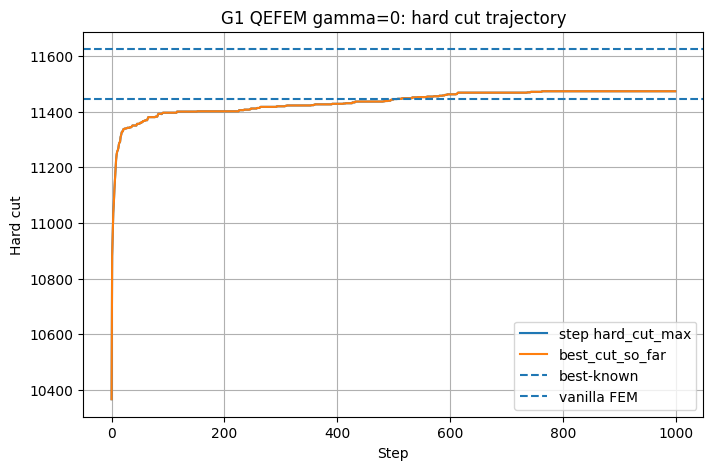

In [53]:
# ----------------------------
# Plot: hard cut trajectory
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["hard_cut_max"], label="step hard_cut_max")
plt.plot(history_zero_df["step"], history_zero_df["best_cut_so_far"], label="best_cut_so_far")
plt.axhline(best_known, linestyle="--", label="best-known")
plt.axhline(float(vanilla_row["vanilla_cut"]), linestyle="--", label="vanilla FEM")
plt.xlabel("Step")
plt.ylabel("Hard cut")
plt.title(f"{instance} QEFEM gamma=0: hard cut trajectory")
plt.legend()
plt.grid(True)
plt.show()

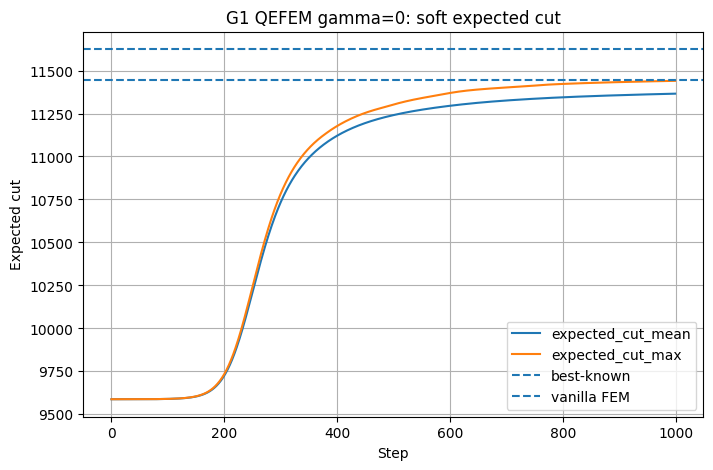

In [54]:
# ----------------------------
# Plot: expected cut trajectory
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["expected_cut_mean"], label="expected_cut_mean")
plt.plot(history_zero_df["step"], history_zero_df["expected_cut_max"], label="expected_cut_max")
plt.axhline(best_known, linestyle="--", label="best-known")
plt.axhline(float(vanilla_row["vanilla_cut"]), linestyle="--", label="vanilla FEM")
plt.xlabel("Step")
plt.ylabel("Expected cut")
plt.title(f"{instance} QEFEM gamma=0: soft expected cut")
plt.legend()
plt.grid(True)
plt.show()

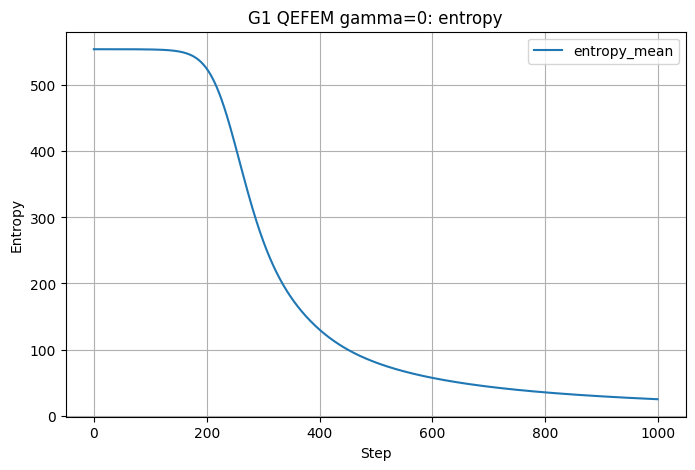

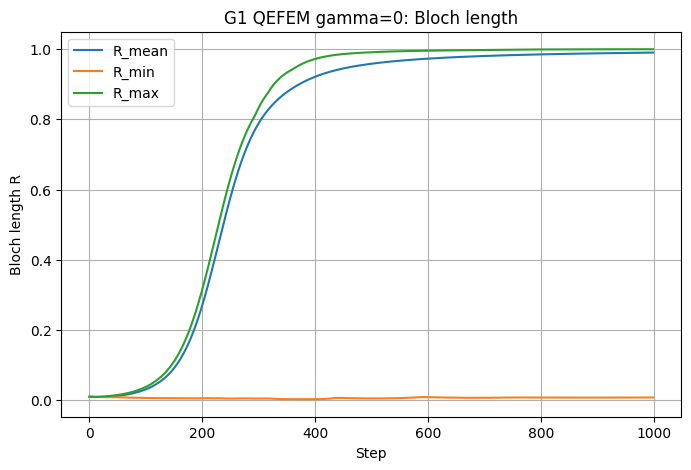

In [55]:
# ----------------------------
# Plot: entropy and Bloch length
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["entropy_mean"], label="entropy_mean")
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.title(f"{instance} QEFEM gamma=0: entropy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["R_mean"], label="R_mean")
plt.plot(history_zero_df["step"], history_zero_df["R_min"], label="R_min")
plt.plot(history_zero_df["step"], history_zero_df["R_max"], label="R_max")
plt.xlabel("Step")
plt.ylabel("Bloch length R")
plt.title(f"{instance} QEFEM gamma=0: Bloch length")
plt.legend()
plt.grid(True)
plt.show()

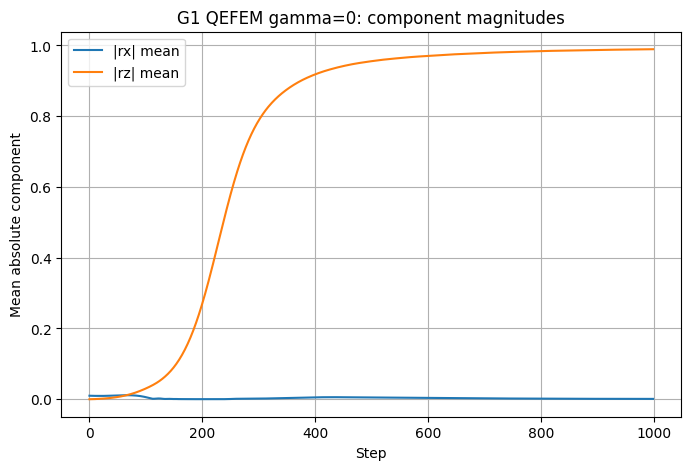

In [56]:
# ----------------------------
# Plot: rx and rz behavior
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["rx_abs_mean"], label="|rx| mean")
plt.plot(history_zero_df["step"], history_zero_df["rz_abs_mean"], label="|rz| mean")
plt.xlabel("Step")
plt.ylabel("Mean absolute component")
plt.title(f"{instance} QEFEM gamma=0: component magnitudes")
plt.legend()
plt.grid(True)
plt.show()

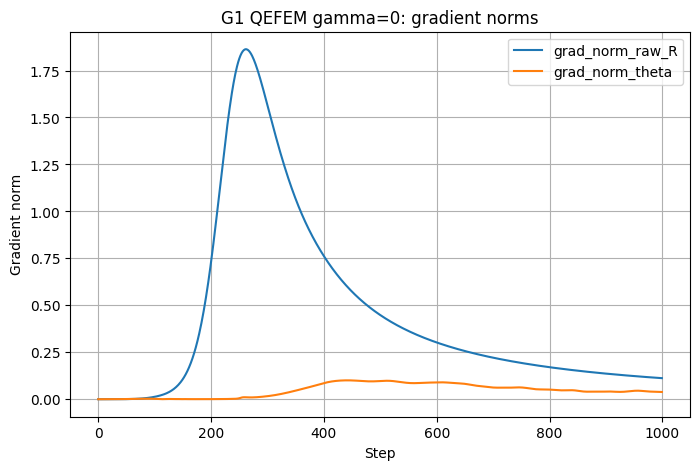

In [57]:
# ----------------------------
# Plot: gradient norms
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["grad_norm_raw_R"], label="grad_norm_raw_R")
plt.plot(history_zero_df["step"], history_zero_df["grad_norm_theta"], label="grad_norm_theta")
plt.xlabel("Step")
plt.ylabel("Gradient norm")
plt.title(f"{instance} QEFEM gamma=0: gradient norms")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# ----------------------------
# Final interpretation printout
# ----------------------------
print("\nInterpretation:")
print(f"Best gamma=0 QEFEM cut: {best_cut_zero:.0f}")
print(f"Vanilla FEM cut: {float(vanilla_row['vanilla_cut']):.0f}")
print(f"Best-known cut: {best_known}")
print(f"Delta cut vs vanilla: {best_cut_zero - float(vanilla_row['vanilla_cut']):.0f}")
print(f"Delta accuracy vs vanilla: {accuracy_zero - float(vanilla_row['vanilla_percent_accuracy']):.4f} percentage points")

if best_cut_zero >= float(vanilla_row["vanilla_cut"]):
    print("\nVerdict: gamma=0 QEFEM is vanilla-esque and slightly better on this run.")
else:
    print("\nVerdict: gamma=0 QEFEM is below vanilla, but check closeness.")


Interpretation:
Best gamma=0 QEFEM cut: 11473
Vanilla FEM cut: 11446
Best-known cut: 11624
Delta cut vs vanilla: 27
Delta accuracy vs vanilla: 0.2323 percentage points

Verdict: gamma=0 QEFEM is vanilla-esque and slightly better on this run.


This is performing exactly as expected due to gamma reward = 0, rx (mixing) never grows!

#### Build single instance QeFEM runner 
for when multiple instances shall be built for different GSets in the for loop

In [59]:
def run_qefem_single_gset(
    instance_name,
    gamma_mode="anneal",
    replicas=REPLICAS,
    n_steps=N_STEPS,
    seed=SEED,
    lr=LR,
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    gamma_max=GAMMA_MAX,
    gamma_min=GAMMA_MIN,
    R_init=R_INIT,
    theta_center=THETA_CENTER,
    theta_noise=THETA_NOISE,
    print_every=PRINT_EVERY,
    save_history=True,
    output_dir=OUTPUT_DIR,
    device=device,
    dtype=DTYPE,
):

    # ----------------------------
    # Load graph
    # ----------------------------
    instance_path = DATA_GSET_DIR / instance_name

    W_local, graph_info_local = load_gset_dense(
        instance_path,
        device=device,
        dtype=dtype,
        index_start=1,
    )

    n_local = W_local.shape[0]
    best_value_local = GSET_BEST_KNOWN_ALL[instance_name]

    vanilla_match = vanilla_compare_df.query("instance == @instance_name")

    if len(vanilla_match) != 1:
        raise ValueError(
            f"Expected exactly one vanilla baseline row for {instance_name}, "
            f"found {len(vanilla_match)}."
        )

    vanilla_row_local = vanilla_match.iloc[0]


    # ----------------------------
    # Initialize variables
    # ----------------------------
    raw_R_local, theta_local = initialize_qefem_variables(
        n=n_local,
        replicas=replicas,
        seed=seed,
        R_init=R_init,
        theta_center=theta_center,
        theta_noise=theta_noise,
        device=device,
        dtype=dtype,
    )

    optimizer_local = make_qefem_optimizer(
        raw_R=raw_R_local,
        theta=theta_local,
        lr=lr,
    )


    # ----------------------------
    # Build schedules
    # ----------------------------
    beta_schedule_local = make_beta_schedule(
        beta_min=beta_min,
        beta_max=beta_max,
        n_steps=n_steps,
        kind=BETA_SCHEDULE_KIND,
        device=device,
        dtype=dtype,
    )

    gamma_schedule_local = make_gamma_schedule(
        gamma_mode=gamma_mode,
        gamma_max=gamma_max,
        gamma_min=gamma_min,
        n_steps=n_steps,
        kind=GAMMA_SCHEDULE_KIND,
        device=device,
        dtype=dtype,
    )


    # ----------------------------
    # Run bookkeeping
    # ----------------------------
    history = []

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    start_time = time.time()

    print("=" * 80)
    print(f"Running QEFEM single instance: {instance_name}")
    print("=" * 80)
    print("gamma_mode:", gamma_mode)
    print("N:", n_local)
    print("replicas:", replicas)
    print("n_steps:", n_steps)
    print("lr:", lr)
    print("beta:", beta_min, "->", beta_max)

    if gamma_mode == "zero":
        print("gamma: 0.0 fixed")
    elif gamma_mode == "anneal":
        print("gamma:", gamma_max, "->", gamma_min)

    print("best-known:", best_value_local)
    print("vanilla cut:", vanilla_row_local["vanilla_cut"])
    print("-" * 80)


    # ----------------------------
    # Training loop
    # ----------------------------
    for step in range(n_steps):
        beta_t = beta_schedule_local[step]
        gamma_t = gamma_schedule_local[step]

        optimizer_local.zero_grad()

        F, aux = qefem_free_energy_maxcut(
            W=W_local,
            raw_R=raw_R_local,
            theta=theta_local,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()
        loss.backward()

        grad_norm_raw_R = raw_R_local.grad.detach().norm().item()
        grad_norm_theta = theta_local.grad.detach().norm().item()

        optimizer_local.step()

        with torch.no_grad():
            R_now, rx_now, rz_now = bloch_from_raw(raw_R_local, theta_local)

            spins_now = torch.where(
                rz_now >= 0,
                torch.ones_like(rz_now),
                -torch.ones_like(rz_now),
            )

            hard_cuts_now = discrete_cut(W_local, spins_now)

            step_best_cut = float(hard_cuts_now.max().detach().cpu())
            step_best_replica = int(torch.argmax(hard_cuts_now).detach().cpu())

            if step_best_cut > best_cut:
                best_cut = step_best_cut
                best_step = step
                best_replica = step_best_replica
                best_spins = spins_now[step_best_replica].detach().cpu().clone()

            row = {
                "instance": instance_name,
                "step": step,
                "beta": float(beta_t.detach().cpu()),
                "gamma": float(gamma_t.detach().cpu()),

                "loss_mean": float(loss.detach().cpu()),
                "free_energy_mean": float(F.mean().detach().cpu()),

                "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),

                "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                "hard_cut_max": float(hard_cuts_now.max().detach().cpu()),
                "best_cut_so_far": best_cut,

                "entropy_mean": float(aux["entropy"].mean().detach().cpu()),
                "driver_energy_mean": float(aux["driver_energy"].mean().detach().cpu()),

                "R_mean": float(R_now.mean().detach().cpu()),
                "R_min": float(R_now.min().detach().cpu()),
                "R_max": float(R_now.max().detach().cpu()),

                "rx_mean": float(rx_now.mean().detach().cpu()),
                "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

                "rz_mean": float(rz_now.mean().detach().cpu()),
                "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

                "grad_norm_raw_R": grad_norm_raw_R,
                "grad_norm_theta": grad_norm_theta,
            }

            history.append(row)

        if (
            step == 0
            or (step + 1) % print_every == 0
            or step == n_steps - 1
        ):
            elapsed = time.time() - start_time

            print(
                f"{instance_name} | "
                f"step {step + 1:4d}/{n_steps} | "
                f"beta={row['beta']:.2f} | "
                f"gamma={row['gamma']:.4f} | "
                f"hard_max={row['hard_cut_max']:.0f} | "
                f"best={row['best_cut_so_far']:.0f} | "
                f"|rx|={row['rx_abs_mean']:.4f} | "
                f"|rz|={row['rz_abs_mean']:.4f} | "
                f"elapsed={elapsed:.2f}s"
            )


    # ----------------------------
    # Finalize
    # ----------------------------
    runtime = time.time() - start_time
    history_df = pd.DataFrame(history)

    gap = best_value_local - best_cut
    percent_accuracy = 100.0 * best_cut / best_value_local

    vanilla_cut = float(vanilla_row_local["vanilla_cut"])
    vanilla_gap = float(vanilla_row_local["vanilla_gap"])
    vanilla_percent_accuracy = float(vanilla_row_local["vanilla_percent_accuracy"])
    vanilla_runtime = float(vanilla_row_local["vanilla_tts_seconds"])

    summary = {
        "instance": instance_name,
        "nodes": n_local,
        "edges": graph_info_local["m_loaded"],

        "mode": f"qefem_{gamma_mode}",
        "gamma_mode": gamma_mode,
        "gamma_max": gamma_max if gamma_mode == "anneal" else 0.0,
        "gamma_min": gamma_min if gamma_mode == "anneal" else 0.0,

        "n_steps": n_steps,
        "replicas": replicas,
        "seed": seed,
        "lr": lr,
        "beta_min": beta_min,
        "beta_max": beta_max,

        "best_cut": best_cut,
        "best_value": best_value_local,
        "gap": gap,
        "percent_accuracy": percent_accuracy,
        "best_step": best_step,
        "best_replica": best_replica,
        "runtime_sec": runtime,

        "vanilla_cut": vanilla_cut,
        "vanilla_gap": vanilla_gap,
        "vanilla_percent_accuracy": vanilla_percent_accuracy,
        "vanilla_runtime_sec": vanilla_runtime,

        "delta_cut_vs_vanilla": best_cut - vanilla_cut,
        "delta_gap_vs_vanilla": vanilla_gap - gap,
        "delta_accuracy_vs_vanilla": percent_accuracy - vanilla_percent_accuracy,
        "runtime_ratio_vs_vanilla": runtime / vanilla_runtime if vanilla_runtime > 0 else np.nan,
    }


    # ----------------------------
    # Save history if requested
    # ----------------------------
    if save_history:
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True)

        history_path = output_dir / f"{instance_name}_qefem_{gamma_mode}_history.csv"
        history_df.to_csv(history_path, index=False)

        summary_path = output_dir / f"{instance_name}_qefem_{gamma_mode}_summary.csv"
        pd.DataFrame([summary]).to_csv(summary_path, index=False)

        summary["history_path"] = str(history_path)
        summary["summary_path"] = str(summary_path)


    print("\nFinished:", instance_name)
    print("Best cut:", best_cut)
    print("Best-known:", best_value_local)
    print("Gap:", gap)
    print("Accuracy %:", percent_accuracy)
    print("Vanilla cut:", vanilla_cut)
    print("Delta cut vs vanilla:", best_cut - vanilla_cut)
    print("Runtime sec:", runtime)
    print("-" * 80)

    return summary, history_df

### Run Batch 1 ---> {G1,..G10}

In [60]:
assert "run_qefem_single_gset" in globals(), "Run Cell 18 first. Wrapper function is missing."

qefem_g1_g10_summaries = []
qefem_g1_g10_histories = {}

g1_g10_output_path = OUTPUT_DIR / "qefem_anneal_G1_G10_partial_results.csv"

print("=" * 80)
print("Starting QEFEM gamma anneal sweep: G1-G10")
print("=" * 80)
print("Instances:", GSET_FIRST_SWEEP)
print("Partial results will be saved to:")
print(g1_g10_output_path.resolve())
print("=" * 80)

Starting QEFEM gamma anneal sweep: G1-G10
Instances: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Partial results will be saved to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G1_G10_partial_results.csv


In [61]:
for run_idx, instance_name in enumerate(GSET_FIRST_SWEEP, start=1):
    print("\n\n" + "#" * 80)
    print(f"G1-G10 sweep item {run_idx}/{len(GSET_FIRST_SWEEP)}: {instance_name}")
    print("#" * 80)

    summary, history_df = run_qefem_single_gset(
        instance_name=instance_name,
        gamma_mode="anneal",
        replicas=REPLICAS,
        n_steps=N_STEPS,
        seed=SEED,
        lr=LR,
        beta_min=BETA_MIN,
        beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX,
        gamma_min=GAMMA_MIN,
        R_init=R_INIT,
        theta_center=THETA_CENTER,
        theta_noise=THETA_NOISE,
        print_every=PRINT_EVERY,
        save_history=True,
        output_dir=OUTPUT_DIR,
        device=device,
        dtype=DTYPE,
    )

    qefem_g1_g10_summaries.append(summary)
    qefem_g1_g10_histories[instance_name] = history_df

    # Save partial summary after every graph because notebooks enjoy dying at bad times.
    qefem_g1_g10_results_df = pd.DataFrame(qefem_g1_g10_summaries)
    qefem_g1_g10_results_df.to_csv(g1_g10_output_path, index=False)

    print("\nCurrent partial G1-G10 results:")
    display(qefem_g1_g10_results_df[
        [
            "instance",
            "best_cut",
            "best_value",
            "gap",
            "percent_accuracy",
            "vanilla_cut",
            "delta_cut_vs_vanilla",
            "delta_accuracy_vs_vanilla",
            "runtime_sec",
        ]
    ])



################################################################################
G1-G10 sweep item 1/10: G1
################################################################################
Running QEFEM single instance: G1
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 11624
vanilla cut: 11446.0
--------------------------------------------------------------------------------
G1 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=9647 | best=9647 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G1 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=9788 | best=9904 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.84s
G1 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=7848 | best=9904 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.91s
G1 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=11600 | best=11600 | |rx|=0.1821 | |rz|=0.6212 | elapsed=5.98s
G1 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=11610

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349




################################################################################
G1-G10 sweep item 2/10: G2
################################################################################
Running QEFEM single instance: G2
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 11620
vanilla cut: 11435.0
--------------------------------------------------------------------------------
G2 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=9723 | best=9723 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G2 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=9803 | best=9912 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.62s
G2 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=3731 | best=9912 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.67s
G2 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=11594 | best=11594 | |rx|=0.1816 | |rz|=0.6219 | elapsed=5.79s
G2 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=11610

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.147006




################################################################################
G1-G10 sweep item 3/10: G3
################################################################################
Running QEFEM single instance: G3
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 11622
vanilla cut: 11443.0
--------------------------------------------------------------------------------
G3 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=9716 | best=9716 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G3 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=9784 | best=9901 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.63s
G3 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=7408 | best=9901 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.75s
G3 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=11601 | best=11601 | |rx|=0.1812 | |rz|=0.6223 | elapsed=5.84s
G3 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=11608

...

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.147006
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.713759
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,20.273321
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,19.919531
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,20.543701
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.921516
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,20.028873




################################################################################
G1-G10 sweep item 9/10: G9
################################################################################
Running QEFEM single instance: G9
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2054
vanilla cut: 1840.0
--------------------------------------------------------------------------------
G9 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=80 | best=80 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G9 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=177 | best=272 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.64s
G9 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1655 | best=1655 | |rx|=0.1512 | |rz|=0.0003 | elapsed=3.66s
G9 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=2040 | best=2040 | |rx|=0.1762 | |rz|=0.6353 | elapsed=5.70s
G9 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=2041 | best=204

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.147006
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.713759
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,20.273321
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,19.919531
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,20.543701
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.921516
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,20.028873
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.823088




################################################################################
G1-G10 sweep item 10/10: G10
################################################################################
Running QEFEM single instance: G10
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2000
vanilla cut: 1819.0
--------------------------------------------------------------------------------
G10 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=27 | best=27 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G10 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=111 | best=226 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.45s
G10 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1428 | best=1428 | |rx|=0.1512 | |rz|=0.0003 | elapsed=3.49s
G10 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=1983 | best=1983 | |rx|=0.1769 | |rz|=0.6343 | elapsed=5.61s
G10 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=1991 | 

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.147006
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.713759
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,20.273321
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,19.919531
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,20.543701
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.921516
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,20.028873
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.823088
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.065519


In [62]:

# ----------------------------
# Finalize G1-G10 result file
# ----------------------------
qefem_g1_g10_results_df = pd.DataFrame(qefem_g1_g10_summaries)

final_g1_g10_path = OUTPUT_DIR / "qefem_anneal_G1_G10_final_results.csv"
qefem_g1_g10_results_df.to_csv(final_g1_g10_path, index=False)

print("\n" + "=" * 80)
print("G1-G10 QEFEM gamma anneal sweep complete")
print("=" * 80)

display(qefem_g1_g10_results_df[
    [
        "instance",
        "best_cut",
        "best_value",
        "gap",
        "percent_accuracy",
        "vanilla_cut",
        "delta_cut_vs_vanilla",
        "delta_accuracy_vs_vanilla",
        "runtime_sec",
    ]
])

print("\nSaved final G1-G10 results to:")
print(final_g1_g10_path.resolve())


G1-G10 QEFEM gamma anneal sweep complete


,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.147006
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.713759
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,20.273321
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,19.919531
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,20.543701
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.921516
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,20.028873
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.823088
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.065519



Saved final G1-G10 results to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G1_G10_final_results.csv


In [63]:
# ----------------------------
# Aggregate summary
# ----------------------------
num_wins = int((qefem_g1_g10_results_df["delta_cut_vs_vanilla"] > 0).sum())
num_ties = int((qefem_g1_g10_results_df["delta_cut_vs_vanilla"] == 0).sum())
num_losses = int((qefem_g1_g10_results_df["delta_cut_vs_vanilla"] < 0).sum())

mean_delta_cut = float(qefem_g1_g10_results_df["delta_cut_vs_vanilla"].mean())
mean_delta_accuracy = float(qefem_g1_g10_results_df["delta_accuracy_vs_vanilla"].mean())
mean_accuracy = float(qefem_g1_g10_results_df["percent_accuracy"].mean())
mean_runtime = float(qefem_g1_g10_results_df["runtime_sec"].mean())

print("\nAggregate G1-G10 summary:")
print("Wins vs vanilla:", num_wins)
print("Ties vs vanilla:", num_ties)
print("Losses vs vanilla:", num_losses)
print("Mean delta cut vs vanilla:", mean_delta_cut)
print("Mean delta accuracy vs vanilla:", mean_delta_accuracy)
print("Mean QEFEM accuracy %:", mean_accuracy)
print("Mean runtime sec:", mean_runtime)


Aggregate G1-G10 summary:
Wins vs vanilla: 10
Ties vs vanilla: 0
Losses vs vanilla: 0
Mean delta cut vs vanilla: 168.7
Mean delta accuracy vs vanilla: 4.958854252385012
Mean QEFEM accuracy %: 99.6885551831717
Mean runtime sec: 19.977666282653807


### Inference & Diagnostics

In [64]:
# ============================================================
# Cell 20: Analyze G1-G10 QEFEM vs vanilla results
# ============================================================

# This cell does NOT rerun anything.
# It analyzes the completed G1-G10 QEFEM anneal sweep from Cell 19.

assert "qefem_g1_g10_results_df" in globals(), (
    "Run Cell 19 first. qefem_g1_g10_results_df does not exist."
)

assert len(qefem_g1_g10_results_df) > 0, (
    "qefem_g1_g10_results_df is empty. The dataframe goblin ate your sweep."
)


# ----------------------------
# Make clean comparison dataframe
# ----------------------------
g1_g10_analysis_df = qefem_g1_g10_results_df.copy()

# Helpful columns
g1_g10_analysis_df["cut_improvement_percent_vs_vanilla"] = (
    100.0
    * g1_g10_analysis_df["delta_cut_vs_vanilla"]
    / g1_g10_analysis_df["vanilla_cut"]
)

g1_g10_analysis_df["gap_reduction_percent_vs_vanilla"] = (
    100.0
    * g1_g10_analysis_df["delta_gap_vs_vanilla"]
    / g1_g10_analysis_df["vanilla_gap"]
)

g1_g10_analysis_df["qefem_minus_best_known"] = (
    g1_g10_analysis_df["best_cut"] - g1_g10_analysis_df["best_value"]
)

g1_g10_analysis_df["hit_best_known"] = (
    g1_g10_analysis_df["best_cut"] >= g1_g10_analysis_df["best_value"]
)

g1_g10_analysis_df["winner"] = np.where(
    g1_g10_analysis_df["delta_cut_vs_vanilla"] > 0,
    "QEFEM",
    np.where(
        g1_g10_analysis_df["delta_cut_vs_vanilla"] < 0,
        "Vanilla",
        "Tie",
    )
)

In [65]:
# ----------------------------
# Display main table
# ----------------------------
main_cols = [
    "instance",
    "best_cut",
    "vanilla_cut",
    "best_value",
    "gap",
    "vanilla_gap",
    "percent_accuracy",
    "vanilla_percent_accuracy",
    "delta_cut_vs_vanilla",
    "cut_improvement_percent_vs_vanilla",
    "delta_accuracy_vs_vanilla",
    "gap_reduction_percent_vs_vanilla",
    "runtime_sec",
    "vanilla_runtime_sec",
    "runtime_ratio_vs_vanilla",
    "winner",
]

print("G1-G10 QEFEM vs vanilla comparison:")
display(g1_g10_analysis_df[main_cols])


# ----------------------------
# Save analysis table
# ----------------------------
g1_g10_analysis_path = OUTPUT_DIR / "qefem_anneal_G1_G10_analysis_vs_vanilla.csv"
g1_g10_analysis_df.to_csv(g1_g10_analysis_path, index=False)

print("\nSaved G1-G10 analysis to:")
print(g1_g10_analysis_path.resolve())

G1-G10 QEFEM vs vanilla comparison:


,instance,best_cut,vanilla_cut,best_value,gap,vanilla_gap,percent_accuracy,vanilla_percent_accuracy,delta_cut_vs_vanilla,cut_improvement_percent_vs_vanilla,delta_accuracy_vs_vanilla,gap_reduction_percent_vs_vanilla,runtime_sec,vanilla_runtime_sec,runtime_ratio_vs_vanilla,winner
0,G1,11611.0,11446.0,11624,13.0,178.0,99.888162,98.468685,165.0,1.441552,1.419477,92.696629,20.340349,4.368305,4.656348,QEFEM
1,G2,11610.0,11435.0,11620,10.0,185.0,99.913941,98.407917,175.0,1.530389,1.506024,94.594595,20.147006,4.299664,4.685716,QEFEM
2,G3,11610.0,11443.0,11622,12.0,179.0,99.896748,98.459818,167.0,1.459407,1.436930,93.296089,19.713759,4.356321,4.525323,QEFEM
3,G4,11637.0,11503.0,11646,9.0,143.0,99.922720,98.772111,134.0,1.164914,1.150610,93.706294,20.273321,4.275009,4.742287,QEFEM
4,G5,11622.0,11450.0,11631,9.0,181.0,99.922621,98.443814,172.0,1.502183,1.478807,95.027624,19.919531,4.161925,4.786134,QEFEM
5,G6,2173.0,1978.0,2178,5.0,200.0,99.770432,90.817264,195.0,9.858443,8.953168,97.500000,20.543701,4.394011,4.675387,QEFEM
6,G7,1992.0,1822.0,2006,14.0,184.0,99.302094,90.827517,170.0,9.330406,8.474576,92.391304,19.921516,4.333263,4.597348,QEFEM
7,G8,1991.0,1856.0,2005,14.0,149.0,99.301746,92.568579,135.0,7.273707,6.733167,90.604027,20.028873,4.411136,4.540525,QEFEM
8,G9,2041.0,1840.0,2054,13.0,214.0,99.367089,89.581305,201.0,10.923913,9.785784,93.925234,19.823088,4.523476,4.382269,QEFEM
9,G10,1992.0,1819.0,2000,8.0,181.0,99.600000,90.950000,173.0,9.510720,8.650000,95.580110,19.065519,4.260001,4.475473,QEFEM



Saved G1-G10 analysis to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G1_G10_analysis_vs_vanilla.csv


In [66]:
# ----------------------------
# Aggregate statistics
# ----------------------------
num_instances = len(g1_g10_analysis_df)

wins = int((g1_g10_analysis_df["winner"] == "QEFEM").sum())
ties = int((g1_g10_analysis_df["winner"] == "Tie").sum())
losses = int((g1_g10_analysis_df["winner"] == "Vanilla").sum())

mean_qefem_cut = float(g1_g10_analysis_df["best_cut"].mean())
mean_vanilla_cut = float(g1_g10_analysis_df["vanilla_cut"].mean())
mean_best_value = float(g1_g10_analysis_df["best_value"].mean())

mean_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].mean())
median_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].median())
min_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].min())
max_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].max())

mean_cut_improvement_percent = float(
    g1_g10_analysis_df["cut_improvement_percent_vs_vanilla"].mean()
)

mean_qefem_accuracy = float(g1_g10_analysis_df["percent_accuracy"].mean())
mean_vanilla_accuracy = float(g1_g10_analysis_df["vanilla_percent_accuracy"].mean())
mean_delta_accuracy = float(g1_g10_analysis_df["delta_accuracy_vs_vanilla"].mean())

mean_gap = float(g1_g10_analysis_df["gap"].mean())
mean_vanilla_gap = float(g1_g10_analysis_df["vanilla_gap"].mean())
mean_gap_reduction = float(g1_g10_analysis_df["delta_gap_vs_vanilla"].mean())
mean_gap_reduction_percent = float(
    g1_g10_analysis_df["gap_reduction_percent_vs_vanilla"].mean()
)

best_known_hits = int(g1_g10_analysis_df["hit_best_known"].sum())

mean_runtime = float(g1_g10_analysis_df["runtime_sec"].mean())
mean_vanilla_runtime = float(g1_g10_analysis_df["vanilla_runtime_sec"].mean())
mean_runtime_ratio = float(g1_g10_analysis_df["runtime_ratio_vs_vanilla"].mean())


g1_g10_aggregate_summary = {
    "num_instances": num_instances,

    "wins_vs_vanilla": wins,
    "ties_vs_vanilla": ties,
    "losses_vs_vanilla": losses,

    "mean_qefem_cut": mean_qefem_cut,
    "mean_vanilla_cut": mean_vanilla_cut,
    "mean_best_value": mean_best_value,

    "mean_delta_cut_vs_vanilla": mean_delta_cut,
    "median_delta_cut_vs_vanilla": median_delta_cut,
    "min_delta_cut_vs_vanilla": min_delta_cut,
    "max_delta_cut_vs_vanilla": max_delta_cut,
    "mean_cut_improvement_percent_vs_vanilla": mean_cut_improvement_percent,

    "mean_qefem_accuracy_percent": mean_qefem_accuracy,
    "mean_vanilla_accuracy_percent": mean_vanilla_accuracy,
    "mean_delta_accuracy_percentage_points": mean_delta_accuracy,

    "mean_qefem_gap": mean_gap,
    "mean_vanilla_gap": mean_vanilla_gap,
    "mean_gap_reduction": mean_gap_reduction,
    "mean_gap_reduction_percent": mean_gap_reduction_percent,

    "best_known_hits": best_known_hits,

    "mean_qefem_runtime_sec": mean_runtime,
    "mean_vanilla_runtime_sec": mean_vanilla_runtime,
    "mean_runtime_ratio_vs_vanilla": mean_runtime_ratio,
}

g1_g10_aggregate_summary_df = pd.DataFrame([g1_g10_aggregate_summary])

aggregate_path = OUTPUT_DIR / "qefem_anneal_G1_G10_aggregate_summary.csv"
g1_g10_aggregate_summary_df.to_csv(aggregate_path, index=False)

print("\nAggregate G1-G10 summary:")
display(g1_g10_aggregate_summary_df)

print("\nSaved aggregate summary to:")
print(aggregate_path.resolve())


Aggregate G1-G10 summary:


,num_instances,wins_vs_vanilla,ties_vs_vanilla,losses_vs_vanilla,mean_qefem_cut,mean_vanilla_cut,mean_best_value,mean_delta_cut_vs_vanilla,median_delta_cut_vs_vanilla,min_delta_cut_vs_vanilla,...,mean_vanilla_accuracy_percent,mean_delta_accuracy_percentage_points,mean_qefem_gap,mean_vanilla_gap,mean_gap_reduction,mean_gap_reduction_percent,best_known_hits,mean_qefem_runtime_sec,mean_vanilla_runtime_sec,mean_runtime_ratio_vs_vanilla
0,10,10,0,0,6827.9,6659.2,6838.6,168.7,171.0,134.0,...,94.729701,4.958854,10.7,179.4,168.7,93.932191,0,19.977666,4.338311,4.606681



Saved aggregate summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G1_G10_aggregate_summary.csv


In [67]:
# ----------------------------
# Pretty print key results
# ----------------------------
print("\n" + "=" * 80)
print("G1-G10 HEAD-TO-HEAD SUMMARY")
print("=" * 80)
print(f"Wins / ties / losses vs vanilla: {wins} / {ties} / {losses}")
print(f"Mean QEFEM accuracy: {mean_qefem_accuracy:.4f}%")
print(f"Mean vanilla accuracy: {mean_vanilla_accuracy:.4f}%")
print(f"Mean accuracy gain: {mean_delta_accuracy:.4f} percentage points")
print(f"Mean cut gain: {mean_delta_cut:.2f}")
print(f"Mean cut-value improvement vs vanilla: {mean_cut_improvement_percent:.4f}%")
print(f"Mean vanilla gap: {mean_vanilla_gap:.2f}")
print(f"Mean QEFEM gap: {mean_gap:.2f}")
print(f"Mean gap reduction: {mean_gap_reduction:.2f}")
print(f"Mean gap reduction percent: {mean_gap_reduction_percent:.2f}%")
print(f"Best-known hits: {best_known_hits}/{num_instances}")
print(f"Mean QEFEM runtime: {mean_runtime:.2f}s")
print(f"Mean vanilla runtime: {mean_vanilla_runtime:.2f}s")
print(f"Runtime ratio QEFEM/vanilla: {mean_runtime_ratio:.2f}x")
print("=" * 80)


G1-G10 HEAD-TO-HEAD SUMMARY
Wins / ties / losses vs vanilla: 10 / 0 / 0
Mean QEFEM accuracy: 99.6886%
Mean vanilla accuracy: 94.7297%
Mean accuracy gain: 4.9589 percentage points
Mean cut gain: 168.70
Mean cut-value improvement vs vanilla: 5.3996%
Mean vanilla gap: 179.40
Mean QEFEM gap: 10.70
Mean gap reduction: 168.70
Mean gap reduction percent: 93.93%
Best-known hits: 0/10
Mean QEFEM runtime: 19.98s
Mean vanilla runtime: 4.34s
Runtime ratio QEFEM/vanilla: 4.61x


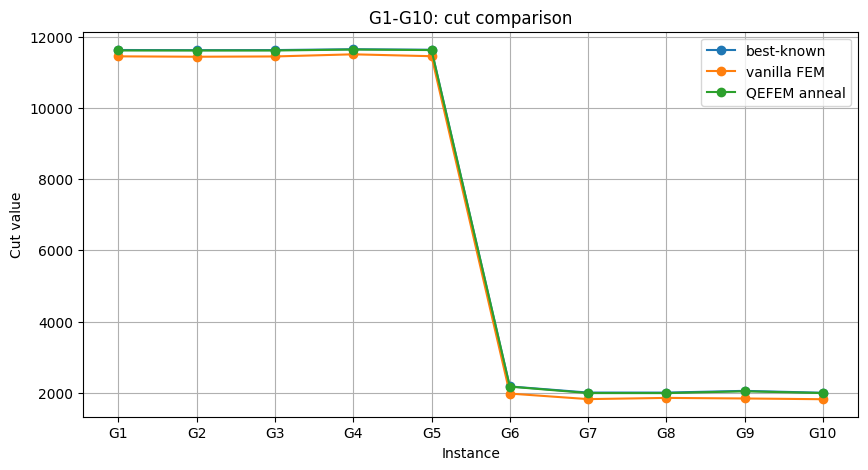

In [68]:
# ----------------------------
# Plot: cut comparison
# ----------------------------
x = np.arange(len(g1_g10_analysis_df))
labels = g1_g10_analysis_df["instance"].tolist()

plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["best_value"], marker="o", label="best-known")
plt.plot(x, g1_g10_analysis_df["vanilla_cut"], marker="o", label="vanilla FEM")
plt.plot(x, g1_g10_analysis_df["best_cut"], marker="o", label="QEFEM anneal")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Cut value")
plt.title("G1-G10: cut comparison")
plt.legend()
plt.grid(True)
plt.show()

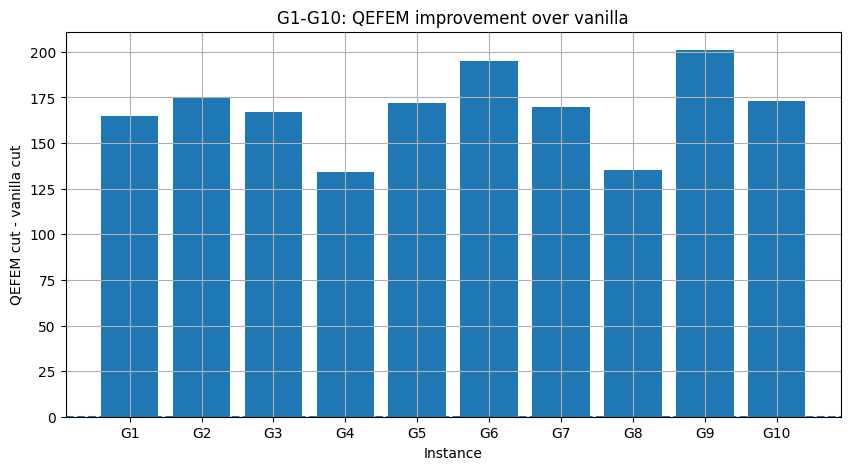

In [69]:
# ----------------------------
# Plot: delta cut vs vanilla
# ----------------------------
plt.figure(figsize=(10, 5))
plt.bar(g1_g10_analysis_df["instance"], g1_g10_analysis_df["delta_cut_vs_vanilla"])
plt.axhline(0, linestyle="--")
plt.xlabel("Instance")
plt.ylabel("QEFEM cut - vanilla cut")
plt.title("G1-G10: QEFEM improvement over vanilla")
plt.grid(True)
plt.show()

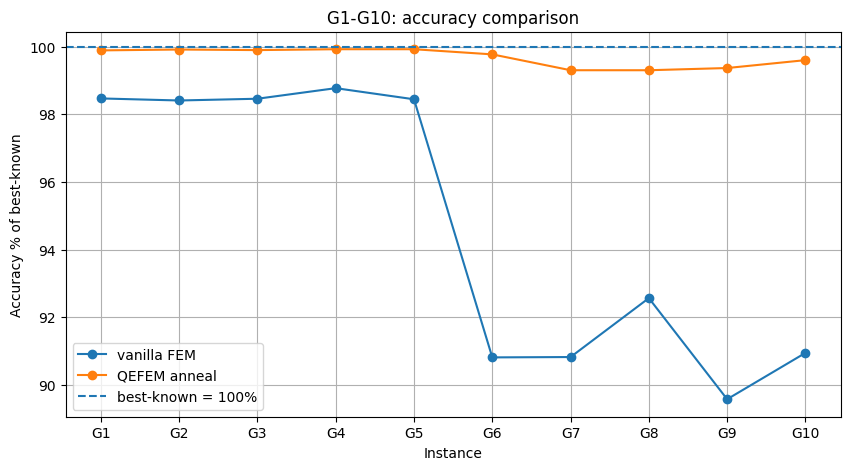

In [70]:
# ----------------------------
# Plot: accuracy comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["vanilla_percent_accuracy"], marker="o", label="vanilla FEM")
plt.plot(x, g1_g10_analysis_df["percent_accuracy"], marker="o", label="QEFEM anneal")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Accuracy % of best-known")
plt.title("G1-G10: accuracy comparison")
plt.legend()
plt.grid(True)
plt.show()

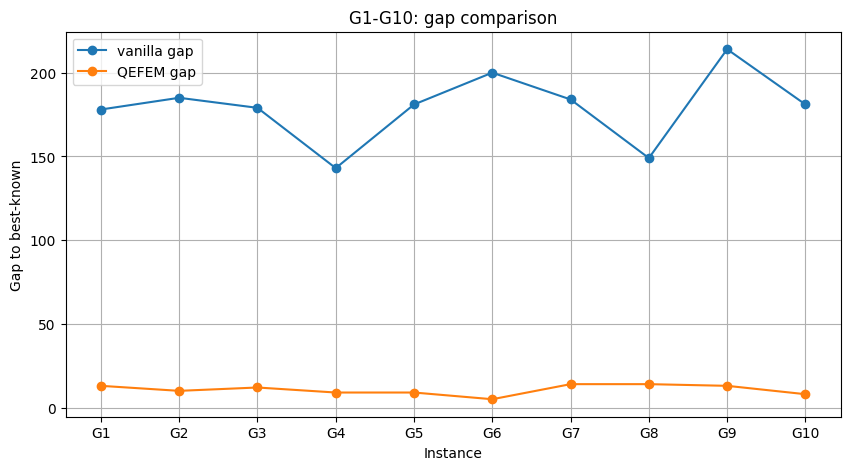

In [71]:
# ----------------------------
# Plot: gap comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["vanilla_gap"], marker="o", label="vanilla gap")
plt.plot(x, g1_g10_analysis_df["gap"], marker="o", label="QEFEM gap")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Gap to best-known")
plt.title("G1-G10: gap comparison")
plt.legend()
plt.grid(True)
plt.show()


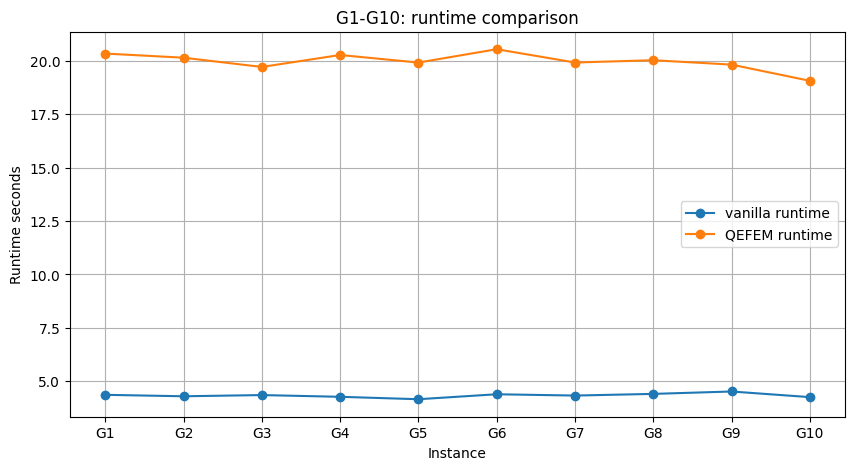

In [72]:
# ----------------------------
# Plot: runtime comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["vanilla_runtime_sec"], marker="o", label="vanilla runtime")
plt.plot(x, g1_g10_analysis_df["runtime_sec"], marker="o", label="QEFEM runtime")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Runtime seconds")
plt.title("G1-G10: runtime comparison")
plt.legend()
plt.grid(True)
plt.show()

In [73]:
# ----------------------------
# Final verdict
# ----------------------------
print("\nVerdict:")

if wins == num_instances:
    print(
        f"QEFEM anneal beats vanilla on all {num_instances}/{num_instances} G1-G10 instances. "
        "This is a very strong first mini-benchmark."
    )
elif wins > losses:
    print(
        "QEFEM anneal wins more often than it loses on G1-G10. Encouraging, but inspect instance-level behavior."
    )
else:
    print(
        "QEFEM anneal does not clearly beat vanilla on G1-G10. Inspect schedules, initialization, and diagnostics."
    )


Verdict:
QEFEM anneal beats vanilla on all 10/10 G1-G10 instances. This is a very strong first mini-benchmark.


### Run PROBLEM BATCH : 
Batch 6 - {35,...,42}

In [74]:
assert "run_qefem_single_gset" in globals(), "Run Cell 18 first. Wrapper function is missing."

qefem_g35_g42_summaries = []
qefem_g35_g42_histories = {}

g35_g42_output_path = OUTPUT_DIR / "qefem_anneal_G35_G42_partial_results.csv"

print("=" * 80)
print("Starting QEFEM gamma anneal sweep: G35-G42 problem batch")
print("=" * 80)
print("Instances:", GSET_PROBLEM_BATCH)
print("Partial results will be saved to:")
print(g35_g42_output_path.resolve())
print("=" * 80)

Starting QEFEM gamma anneal sweep: G35-G42 problem batch
Instances: ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']
Partial results will be saved to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G35_G42_partial_results.csv


In [75]:
for run_idx, instance_name in enumerate(GSET_PROBLEM_BATCH, start=1):
    print("\n\n" + "#" * 80)
    print(f"G35-G42 sweep item {run_idx}/{len(GSET_PROBLEM_BATCH)}: {instance_name}")
    print("#" * 80)

    summary, history_df = run_qefem_single_gset(
        instance_name=instance_name,
        gamma_mode="anneal",
        replicas=REPLICAS,
        n_steps=N_STEPS,
        seed=SEED,
        lr=LR,
        beta_min=BETA_MIN,
        beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX,
        gamma_min=GAMMA_MIN,
        R_init=R_INIT,
        theta_center=THETA_CENTER,
        theta_noise=THETA_NOISE,
        print_every=PRINT_EVERY,
        save_history=True,
        output_dir=OUTPUT_DIR,
        device=device,
        dtype=DTYPE,
    )

    qefem_g35_g42_summaries.append(summary)
    qefem_g35_g42_histories[instance_name] = history_df

    # Save partial summary after every graph because notebooks die with theatrical timing.
    qefem_g35_g42_results_df = pd.DataFrame(qefem_g35_g42_summaries)
    qefem_g35_g42_results_df.to_csv(g35_g42_output_path, index=False)

    print("\nCurrent partial G35-G42 results:")
    display(qefem_g35_g42_results_df[
        [
            "instance",
            "best_cut",
            "best_value",
            "gap",
            "percent_accuracy",
            "vanilla_cut",
            "delta_cut_vs_vanilla",
            "delta_accuracy_vs_vanilla",
            "runtime_sec",
        ]
    ])



################################################################################
G35-G42 sweep item 1/8: G35
################################################################################
Running QEFEM single instance: G35
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 7687
vanilla cut: 7523.0
--------------------------------------------------------------------------------
G35 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=6023 | best=6023 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.12s
G35 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=5938 | best=6182 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.99s
G35 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=4309 | best=6182 | |rx|=0.1512 | |rz|=0.0001 | elapsed=5.87s
G35 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=7537 | best=7539 | |rx|=0.4199 | |rz|=0.3550 | elapsed=8.85s
G35 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=7

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.15483




################################################################################
G35-G42 sweep item 2/8: G36
################################################################################
Running QEFEM single instance: G36
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 7680
vanilla cut: 7515.0
--------------------------------------------------------------------------------
G36 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=5961 | best=5961 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G36 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=5949 | best=6184 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.32s
G36 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=4592 | best=6184 | |rx|=0.1512 | |rz|=0.0001 | elapsed=5.29s
G36 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=7517 | best=7517 | |rx|=0.4207 | |rz|=0.3553 | elapsed=8.29s
G36 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=7

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679




################################################################################
G35-G42 sweep item 3/8: G37
################################################################################
Running QEFEM single instance: G37
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 7691
vanilla cut: 7520.0
--------------------------------------------------------------------------------
G37 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=5987 | best=5987 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G37 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=5977 | best=6202 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.39s
G37 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=4476 | best=6202 | |rx|=0.1512 | |rz|=0.0001 | elapsed=4.33s
G37 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=7548 | best=7548 | |rx|=0.4196 | |rz|=0.3575 | elapsed=7.30s
G37 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=7

...

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,27.966833
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,29.442648
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,29.048542
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.897351




################################################################################
G35-G42 sweep item 7/8: G41
################################################################################
Running QEFEM single instance: G41
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2405
vanilla cut: 2193.0
--------------------------------------------------------------------------------
G41 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=116 | best=116 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G41 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=50 | best=261 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.35s
G41 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1473 | best=1473 | |rx|=0.1512 | |rz|=0.0010 | elapsed=4.30s
G41 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=2252 | best=2252 | |rx|=0.3566 | |rz|=0.4401 | elapsed=7.26s
G41 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=2286 |

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,27.966833
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,29.442648
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,29.048542
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.897351
6,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,27.832200




################################################################################
G35-G42 sweep item 8/8: G42
################################################################################
Running QEFEM single instance: G42
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2481
vanilla cut: 2273.0
--------------------------------------------------------------------------------
G42 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=207 | best=207 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G42 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=95 | best=325 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.41s
G42 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1636 | best=1636 | |rx|=0.1512 | |rz|=0.0013 | elapsed=5.37s
G42 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=2333 | best=2333 | |rx|=0.3536 | |rz|=0.4458 | elapsed=8.35s
G42 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=2380 |

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,27.966833
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,29.442648
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,29.048542
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.897351
6,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,27.832200
7,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.917619


In [76]:
# ----------------------------
# Finalize G35-G42 result file
# ----------------------------
qefem_g35_g42_results_df = pd.DataFrame(qefem_g35_g42_summaries)

final_g35_g42_path = OUTPUT_DIR / "qefem_anneal_G35_G42_final_results.csv"
qefem_g35_g42_results_df.to_csv(final_g35_g42_path, index=False)

print("\n" + "=" * 80)
print("G35-G42 QEFEM gamma anneal sweep complete")
print("=" * 80)

display(qefem_g35_g42_results_df[
    [
        "instance",
        "best_cut",
        "best_value",
        "gap",
        "percent_accuracy",
        "vanilla_cut",
        "delta_cut_vs_vanilla",
        "delta_accuracy_vs_vanilla",
        "runtime_sec",
    ]
])

print("\nSaved final G35-G42 results to:")
print(final_g35_g42_path.resolve())


G35-G42 QEFEM gamma anneal sweep complete


,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,27.966833
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,29.442648
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,29.048542
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.897351
6,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,27.832200
7,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.917619



Saved final G35-G42 results to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G35_G42_final_results.csv


In [77]:
# ----------------------------
# Aggregate summary
# ----------------------------
num_wins = int((qefem_g35_g42_results_df["delta_cut_vs_vanilla"] > 0).sum())
num_ties = int((qefem_g35_g42_results_df["delta_cut_vs_vanilla"] == 0).sum())
num_losses = int((qefem_g35_g42_results_df["delta_cut_vs_vanilla"] < 0).sum())

mean_delta_cut = float(qefem_g35_g42_results_df["delta_cut_vs_vanilla"].mean())
mean_delta_accuracy = float(qefem_g35_g42_results_df["delta_accuracy_vs_vanilla"].mean())
mean_accuracy = float(qefem_g35_g42_results_df["percent_accuracy"].mean())
mean_runtime = float(qefem_g35_g42_results_df["runtime_sec"].mean())

mean_gap = float(qefem_g35_g42_results_df["gap"].mean())
mean_vanilla_gap = float(qefem_g35_g42_results_df["vanilla_gap"].mean())
mean_gap_reduction = float(qefem_g35_g42_results_df["delta_gap_vs_vanilla"].mean())

print("\nAggregate G35-G42 summary:")
print("Wins vs vanilla:", num_wins)
print("Ties vs vanilla:", num_ties)
print("Losses vs vanilla:", num_losses)
print("Mean delta cut vs vanilla:", mean_delta_cut)
print("Mean delta accuracy vs vanilla:", mean_delta_accuracy)
print("Mean QEFEM accuracy %:", mean_accuracy)
print("Mean QEFEM gap:", mean_gap)
print("Mean vanilla gap:", mean_vanilla_gap)
print("Mean gap reduction:", mean_gap_reduction)
print("Mean runtime sec:", mean_runtime)


Aggregate G35-G42 summary:
Wins vs vanilla: 8
Ties vs vanilla: 0
Losses vs vanilla: 0
Mean delta cut vs vanilla: 104.875
Mean delta accuracy vs vanilla: 3.0080988557006485
Mean QEFEM accuracy %: 97.48995893702156
Mean QEFEM gap: 86.5
Mean vanilla gap: 191.375
Mean gap reduction: 104.875
Mean runtime sec: 28.765087723731995


#### Diagnostics & inference

In [78]:
assert "qefem_g35_g42_results_df" in globals(), (
    "Run Cell 21 first. qefem_g35_g42_results_df does not exist."
)

assert len(qefem_g35_g42_results_df) > 0, (
    "qefem_g35_g42_results_df is empty. The problem-batch goblin ate your results."
)


# ----------------------------
# Make clean comparison dataframe
# ----------------------------
g35_g42_analysis_df = qefem_g35_g42_results_df.copy()

g35_g42_analysis_df["cut_improvement_percent_vs_vanilla"] = (
    100.0
    * g35_g42_analysis_df["delta_cut_vs_vanilla"]
    / g35_g42_analysis_df["vanilla_cut"]
)

g35_g42_analysis_df["gap_reduction_percent_vs_vanilla"] = (
    100.0
    * g35_g42_analysis_df["delta_gap_vs_vanilla"]
    / g35_g42_analysis_df["vanilla_gap"]
)

g35_g42_analysis_df["qefem_minus_best_known"] = (
    g35_g42_analysis_df["best_cut"] - g35_g42_analysis_df["best_value"]
)

g35_g42_analysis_df["hit_best_known"] = (
    g35_g42_analysis_df["best_cut"] >= g35_g42_analysis_df["best_value"]
)

g35_g42_analysis_df["winner"] = np.where(
    g35_g42_analysis_df["delta_cut_vs_vanilla"] > 0,
    "QEFEM",
    np.where(
        g35_g42_analysis_df["delta_cut_vs_vanilla"] < 0,
        "Vanilla",
        "Tie",
    )
)

In [79]:
# ----------------------------
# Display main comparison table
# ----------------------------
main_cols = [
    "instance",
    "best_cut",
    "vanilla_cut",
    "best_value",
    "gap",
    "vanilla_gap",
    "percent_accuracy",
    "vanilla_percent_accuracy",
    "delta_cut_vs_vanilla",
    "cut_improvement_percent_vs_vanilla",
    "delta_accuracy_vs_vanilla",
    "gap_reduction_percent_vs_vanilla",
    "runtime_sec",
    "vanilla_runtime_sec",
    "runtime_ratio_vs_vanilla",
    "winner",
]

print("G35-G42 QEFEM vs vanilla comparison:")
display(g35_g42_analysis_df[main_cols])


# ----------------------------
# Save analysis table
# ----------------------------
g35_g42_analysis_path = OUTPUT_DIR / "qefem_anneal_G35_G42_analysis_vs_vanilla.csv"
g35_g42_analysis_df.to_csv(g35_g42_analysis_path, index=False)

print("\nSaved G35-G42 analysis to:")
print(g35_g42_analysis_path.resolve())

G35-G42 QEFEM vs vanilla comparison:


,instance,best_cut,vanilla_cut,best_value,gap,vanilla_gap,percent_accuracy,vanilla_percent_accuracy,delta_cut_vs_vanilla,cut_improvement_percent_vs_vanilla,delta_accuracy_vs_vanilla,gap_reduction_percent_vs_vanilla,runtime_sec,vanilla_runtime_sec,runtime_ratio_vs_vanilla,winner
0,G35,7612.0,7523.0,7687,75.0,164.0,99.024327,97.866528,89.0,1.183039,1.157799,54.268293,29.154830,8.681002,3.358464,QEFEM
1,G36,7599.0,7515.0,7680,81.0,165.0,98.945312,97.851562,84.0,1.117764,1.093750,50.909091,28.860679,8.722572,3.308735,QEFEM
2,G37,7619.0,7520.0,7691,72.0,171.0,99.063841,97.776622,99.0,1.316489,1.287219,57.894737,27.966833,8.150533,3.431289,QEFEM
3,G38,7616.0,7514.0,7688,72.0,174.0,99.063476,97.736733,102.0,1.357466,1.326743,58.620690,29.442648,8.672927,3.394776,QEFEM
4,G39,2336.0,2188.0,2408,72.0,220.0,97.009967,90.863787,148.0,6.764168,6.146179,67.272727,29.048542,8.836483,3.287342,QEFEM
5,G40,2296.0,2183.0,2400,104.0,217.0,95.666667,90.958333,113.0,5.176363,4.708333,52.073733,28.897351,8.739482,3.306529,QEFEM
6,G41,2289.0,2193.0,2405,116.0,212.0,95.176715,91.185031,96.0,4.377565,3.991684,45.283019,27.832200,8.396403,3.314777,QEFEM
7,G42,2381.0,2273.0,2481,100.0,208.0,95.969367,91.616284,108.0,4.751430,4.353083,51.923077,28.917619,8.138303,3.553274,QEFEM



Saved G35-G42 analysis to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G35_G42_analysis_vs_vanilla.csv


In [80]:
# ----------------------------
# Aggregate statistics
# ----------------------------
num_instances = len(g35_g42_analysis_df)

wins = int((g35_g42_analysis_df["winner"] == "QEFEM").sum())
ties = int((g35_g42_analysis_df["winner"] == "Tie").sum())
losses = int((g35_g42_analysis_df["winner"] == "Vanilla").sum())

mean_qefem_cut = float(g35_g42_analysis_df["best_cut"].mean())
mean_vanilla_cut = float(g35_g42_analysis_df["vanilla_cut"].mean())
mean_best_value = float(g35_g42_analysis_df["best_value"].mean())

mean_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].mean())
median_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].median())
min_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].min())
max_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].max())

mean_cut_improvement_percent = float(
    g35_g42_analysis_df["cut_improvement_percent_vs_vanilla"].mean()
)

mean_qefem_accuracy = float(g35_g42_analysis_df["percent_accuracy"].mean())
mean_vanilla_accuracy = float(g35_g42_analysis_df["vanilla_percent_accuracy"].mean())
mean_delta_accuracy = float(g35_g42_analysis_df["delta_accuracy_vs_vanilla"].mean())

mean_gap = float(g35_g42_analysis_df["gap"].mean())
mean_vanilla_gap = float(g35_g42_analysis_df["vanilla_gap"].mean())
mean_gap_reduction = float(g35_g42_analysis_df["delta_gap_vs_vanilla"].mean())
mean_gap_reduction_percent = float(
    g35_g42_analysis_df["gap_reduction_percent_vs_vanilla"].mean()
)

best_known_hits = int(g35_g42_analysis_df["hit_best_known"].sum())

mean_runtime = float(g35_g42_analysis_df["runtime_sec"].mean())
mean_vanilla_runtime = float(g35_g42_analysis_df["vanilla_runtime_sec"].mean())
mean_runtime_ratio = float(g35_g42_analysis_df["runtime_ratio_vs_vanilla"].mean())


g35_g42_aggregate_summary = {
    "num_instances": num_instances,

    "wins_vs_vanilla": wins,
    "ties_vs_vanilla": ties,
    "losses_vs_vanilla": losses,

    "mean_qefem_cut": mean_qefem_cut,
    "mean_vanilla_cut": mean_vanilla_cut,
    "mean_best_value": mean_best_value,

    "mean_delta_cut_vs_vanilla": mean_delta_cut,
    "median_delta_cut_vs_vanilla": median_delta_cut,
    "min_delta_cut_vs_vanilla": min_delta_cut,
    "max_delta_cut_vs_vanilla": max_delta_cut,
    "mean_cut_improvement_percent_vs_vanilla": mean_cut_improvement_percent,

    "mean_qefem_accuracy_percent": mean_qefem_accuracy,
    "mean_vanilla_accuracy_percent": mean_vanilla_accuracy,
    "mean_delta_accuracy_percentage_points": mean_delta_accuracy,

    "mean_qefem_gap": mean_gap,
    "mean_vanilla_gap": mean_vanilla_gap,
    "mean_gap_reduction": mean_gap_reduction,
    "mean_gap_reduction_percent": mean_gap_reduction_percent,

    "best_known_hits": best_known_hits,

    "mean_qefem_runtime_sec": mean_runtime,
    "mean_vanilla_runtime_sec": mean_vanilla_runtime,
    "mean_runtime_ratio_vs_vanilla": mean_runtime_ratio,
}

g35_g42_aggregate_summary_df = pd.DataFrame([g35_g42_aggregate_summary])

aggregate_path = OUTPUT_DIR / "qefem_anneal_G35_G42_aggregate_summary.csv"
g35_g42_aggregate_summary_df.to_csv(aggregate_path, index=False)

print("\nAggregate G35-G42 summary:")
display(g35_g42_aggregate_summary_df)

print("\nSaved aggregate summary to:")
print(aggregate_path.resolve())


Aggregate G35-G42 summary:


,num_instances,wins_vs_vanilla,ties_vs_vanilla,losses_vs_vanilla,mean_qefem_cut,mean_vanilla_cut,mean_best_value,mean_delta_cut_vs_vanilla,median_delta_cut_vs_vanilla,min_delta_cut_vs_vanilla,...,mean_vanilla_accuracy_percent,mean_delta_accuracy_percentage_points,mean_qefem_gap,mean_vanilla_gap,mean_gap_reduction,mean_gap_reduction_percent,best_known_hits,mean_qefem_runtime_sec,mean_vanilla_runtime_sec,mean_runtime_ratio_vs_vanilla
0,8,8,0,0,4968.5,4863.625,5055.0,104.875,100.5,84.0,...,94.48186,3.008099,86.5,191.375,104.875,54.780671,0,28.765088,8.542213,3.369398



Saved aggregate summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G35_G42_aggregate_summary.csv


In [81]:
# ----------------------------
# Pretty print key results
# ----------------------------
print("\n" + "=" * 80)
print("G35-G42 PROBLEM-BATCH HEAD-TO-HEAD SUMMARY")
print("=" * 80)
print(f"Wins / ties / losses vs vanilla: {wins} / {ties} / {losses}")
print(f"Mean QEFEM accuracy: {mean_qefem_accuracy:.4f}%")
print(f"Mean vanilla accuracy: {mean_vanilla_accuracy:.4f}%")
print(f"Mean accuracy gain: {mean_delta_accuracy:.4f} percentage points")
print(f"Mean cut gain: {mean_delta_cut:.2f}")
print(f"Mean cut-value improvement vs vanilla: {mean_cut_improvement_percent:.4f}%")
print(f"Mean vanilla gap: {mean_vanilla_gap:.2f}")
print(f"Mean QEFEM gap: {mean_gap:.2f}")
print(f"Mean gap reduction: {mean_gap_reduction:.2f}")
print(f"Mean gap reduction percent: {mean_gap_reduction_percent:.2f}%")
print(f"Best-known hits: {best_known_hits}/{num_instances}")
print(f"Mean QEFEM runtime: {mean_runtime:.2f}s")
print(f"Mean vanilla runtime: {mean_vanilla_runtime:.2f}s")
print(f"Runtime ratio QEFEM/vanilla: {mean_runtime_ratio:.2f}x")
print("=" * 80)


G35-G42 PROBLEM-BATCH HEAD-TO-HEAD SUMMARY
Wins / ties / losses vs vanilla: 8 / 0 / 0
Mean QEFEM accuracy: 97.4900%
Mean vanilla accuracy: 94.4819%
Mean accuracy gain: 3.0081 percentage points
Mean cut gain: 104.88
Mean cut-value improvement vs vanilla: 3.2555%
Mean vanilla gap: 191.38
Mean QEFEM gap: 86.50
Mean gap reduction: 104.88
Mean gap reduction percent: 54.78%
Best-known hits: 0/8
Mean QEFEM runtime: 28.77s
Mean vanilla runtime: 8.54s
Runtime ratio QEFEM/vanilla: 3.37x


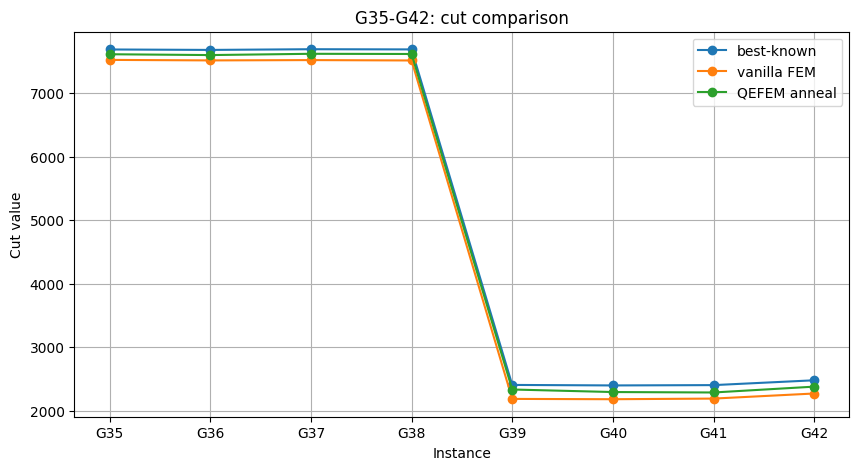

In [82]:
# ----------------------------
# Plot: cut comparison
# ----------------------------
x = np.arange(len(g35_g42_analysis_df))
labels = g35_g42_analysis_df["instance"].tolist()

plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["best_value"], marker="o", label="best-known")
plt.plot(x, g35_g42_analysis_df["vanilla_cut"], marker="o", label="vanilla FEM")
plt.plot(x, g35_g42_analysis_df["best_cut"], marker="o", label="QEFEM anneal")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Cut value")
plt.title("G35-G42: cut comparison")
plt.legend()
plt.grid(True)
plt.show()

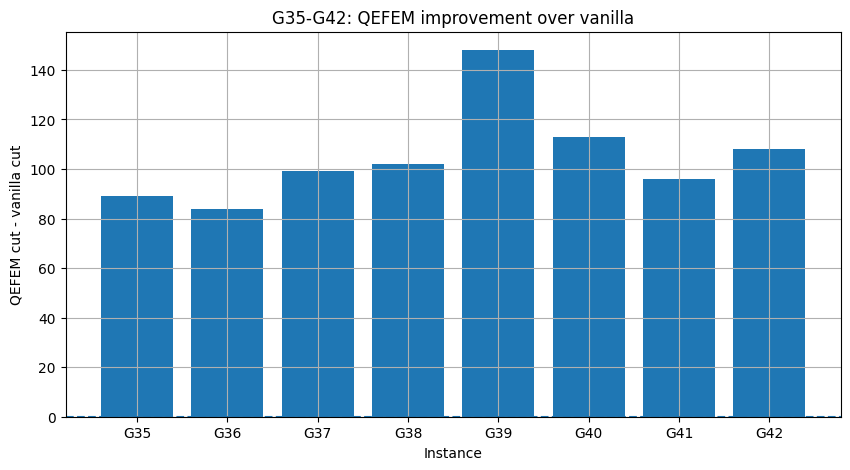

In [83]:
# ----------------------------
# Plot: delta cut vs vanilla
# ----------------------------
plt.figure(figsize=(10, 5))
plt.bar(g35_g42_analysis_df["instance"], g35_g42_analysis_df["delta_cut_vs_vanilla"])
plt.axhline(0, linestyle="--")
plt.xlabel("Instance")
plt.ylabel("QEFEM cut - vanilla cut")
plt.title("G35-G42: QEFEM improvement over vanilla")
plt.grid(True)
plt.show()

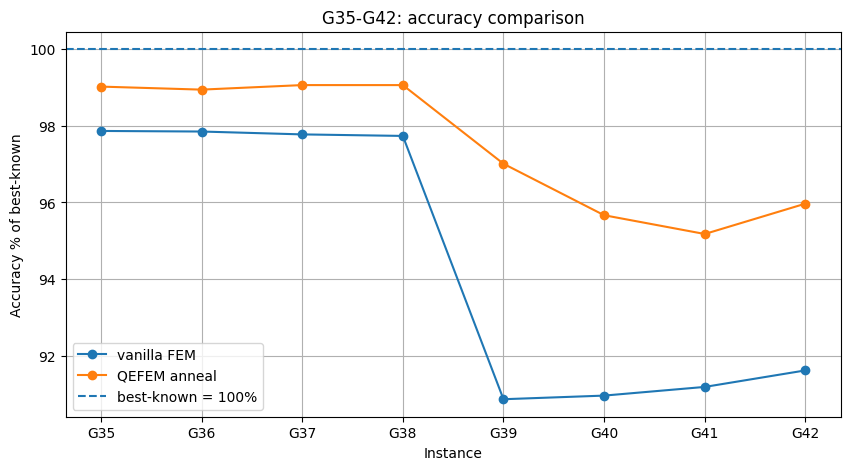

In [84]:
# ----------------------------
# Plot: accuracy comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["vanilla_percent_accuracy"], marker="o", label="vanilla FEM")
plt.plot(x, g35_g42_analysis_df["percent_accuracy"], marker="o", label="QEFEM anneal")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Accuracy % of best-known")
plt.title("G35-G42: accuracy comparison")
plt.legend()
plt.grid(True)
plt.show()

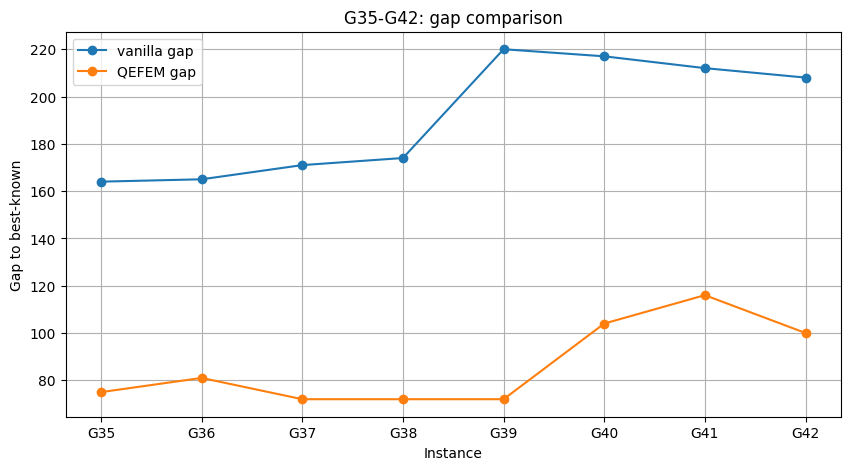

In [85]:
# ----------------------------
# Plot: gap comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["vanilla_gap"], marker="o", label="vanilla gap")
plt.plot(x, g35_g42_analysis_df["gap"], marker="o", label="QEFEM gap")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Gap to best-known")
plt.title("G35-G42: gap comparison")
plt.legend()
plt.grid(True)
plt.show()

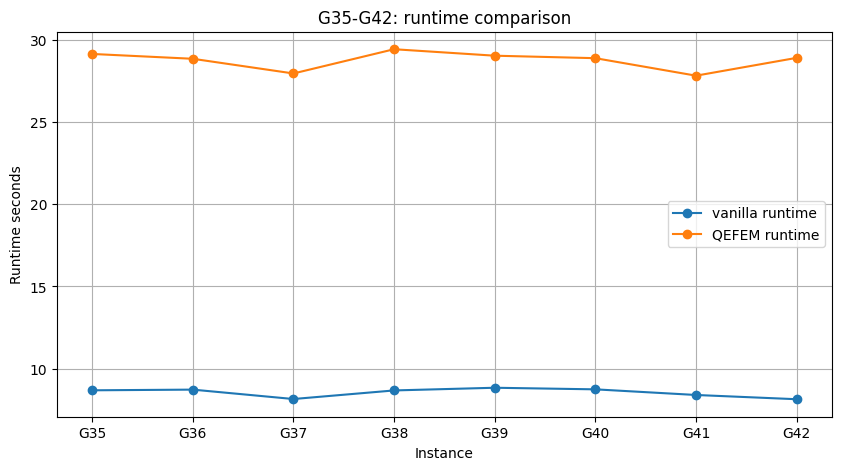

In [86]:
# ----------------------------
# Plot: runtime comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["vanilla_runtime_sec"], marker="o", label="vanilla runtime")
plt.plot(x, g35_g42_analysis_df["runtime_sec"], marker="o", label="QEFEM runtime")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Runtime seconds")
plt.title("G35-G42: runtime comparison")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
# ----------------------------
# Final verdict
# ----------------------------
print("\nVerdict:")

if wins == num_instances:
    print(
        f"QEFEM anneal beats vanilla on all {num_instances}/{num_instances} G35-G42 problem-batch instances. "
        "This would be a very strong sign that the method helps exactly where vanilla struggled." 
    )
elif wins > losses:
    print(
        "QEFEM anneal wins more often than it loses on G35-G42. Encouraging."
    )
else:
    print(
        "QEFEM anneal does not clearly beat vanilla on G35-G42. Inspect gamma schedule, rx/rz behavior, and per-instance traces."
    )


Verdict:
QEFEM anneal beats vanilla on all 8/8 G35-G42 problem-batch instances. This would be a very strong sign that the method helps exactly where vanilla struggled.


### Full RUN
G1-G54 ===> all 9 batches

In [88]:
assert "run_qefem_single_gset" in globals(), "Run Cell 18 first. Wrapper function is missing."
# ----------------------------
# Full benchmark target
# ----------------------------
FULL_BENCHMARK_INSTANCES = GSET_ALL_INSTANCES.copy()

print("Full benchmark target:")
print(FULL_BENCHMARK_INSTANCES)
print("Total instances:", len(FULL_BENCHMARK_INSTANCES))


# ----------------------------
# Collect already-computed results
# ----------------------------
existing_result_dfs = []

if "qefem_g1_g10_results_df" in globals():
    print("\nFound existing G1-G10 QEFEM results.")
    existing_result_dfs.append(qefem_g1_g10_results_df.copy())

if "qefem_g35_g42_results_df" in globals():
    print("Found existing G35-G42 QEFEM results.")
    existing_result_dfs.append(qefem_g35_g42_results_df.copy())


if len(existing_result_dfs) > 0:
    qefem_full_results_df = pd.concat(
        existing_result_dfs,
        ignore_index=True,
    )

    # If an instance somehow appears twice, keep the first result.
    # The notebook goblin occasionally duplicates things when humans panic-run cells.
    qefem_full_results_df = (
        qefem_full_results_df
        .drop_duplicates(subset=["instance"], keep="first")
        .reset_index(drop=True)
    )

else:
    qefem_full_results_df = pd.DataFrame()


already_done_instances = set(qefem_full_results_df["instance"]) if len(qefem_full_results_df) > 0 else set()

missing_instances = [
    instance_name
    for instance_name in FULL_BENCHMARK_INSTANCES
    if instance_name not in already_done_instances
]

print("\nAlready done instances:")
print(sorted(already_done_instances, key=lambda x: int(x[1:])))

print("\nMissing instances to run:")
print(missing_instances)

print("\nNumber already done:", len(already_done_instances))
print("Number missing:", len(missing_instances))

Full benchmark target:
['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31', 'G32', 'G33', 'G34', 'G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42', 'G43', 'G44', 'G45', 'G46', 'G47', 'G48', 'G49', 'G50', 'G51', 'G52', 'G53', 'G54']
Total instances: 54

Found existing G1-G10 QEFEM results.
Found existing G35-G42 QEFEM results.

Already done instances:
['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']

Missing instances to run:
['G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31', 'G32', 'G33', 'G34', 'G43', 'G44', 'G45', 'G46', 'G47', 'G48', 'G49', 'G50', 'G51', 'G52', 'G53', 'G54']

Number already done: 18
Number missing: 36


In [89]:
# ----------------------------
# Save starting merged file
# ----------------------------
full_partial_path = OUTPUT_DIR / "qefem_anneal_G1_G54_partial_results.csv"

if len(qefem_full_results_df) > 0:
    qefem_full_results_df = (
        qefem_full_results_df
        .assign(g_index=lambda df: df["instance"].str.replace("G", "", regex=False).astype(int))
        .sort_values("g_index")
        .drop(columns=["g_index"])
        .reset_index(drop=True)
    )

    qefem_full_results_df.to_csv(full_partial_path, index=False)

    print("\nSaved starting merged partial full-results file:")
    print(full_partial_path.resolve())


Saved starting merged partial full-results file:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G1_G54_partial_results.csv


In [90]:
# ----------------------------
# Run missing instances
# ----------------------------
print("\n" + "=" * 80)
print("Starting missing-instance QEFEM full benchmark runs")
print("=" * 80)

for run_idx, instance_name in enumerate(missing_instances, start=1):
    print("\n\n" + "#" * 80)
    print(f"Full G1-G54 missing run {run_idx}/{len(missing_instances)}: {instance_name}")
    print("#" * 80)

    summary, history_df = run_qefem_single_gset(
        instance_name=instance_name,
        gamma_mode="anneal",
        replicas=REPLICAS,
        n_steps=N_STEPS,
        seed=SEED,
        lr=LR,
        beta_min=BETA_MIN,
        beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX,
        gamma_min=GAMMA_MIN,
        R_init=R_INIT,
        theta_center=THETA_CENTER,
        theta_noise=THETA_NOISE,
        print_every=PRINT_EVERY,
        save_history=True,
        output_dir=OUTPUT_DIR,
        device=device,
        dtype=DTYPE,
    )

    # Append new result
    qefem_full_results_df = pd.concat(
        [
            qefem_full_results_df,
            pd.DataFrame([summary]),
        ],
        ignore_index=True,
    )

    # Sort by G index
    qefem_full_results_df = (
        qefem_full_results_df
        .drop_duplicates(subset=["instance"], keep="first")
        .assign(g_index=lambda df: df["instance"].str.replace("G", "", regex=False).astype(int))
        .sort_values("g_index")
        .drop(columns=["g_index"])
        .reset_index(drop=True)
    )

    # Save after every graph, because notebooks die like Victorian children.
    qefem_full_results_df.to_csv(full_partial_path, index=False)

    print("\nCurrent full benchmark progress:")
    print(f"Completed {len(qefem_full_results_df)}/{len(FULL_BENCHMARK_INSTANCES)} instances")

    display(qefem_full_results_df[
        [
            "instance",
            "best_cut",
            "best_value",
            "gap",
            "percent_accuracy",
            "vanilla_cut",
            "delta_cut_vs_vanilla",
            "delta_accuracy_vs_vanilla",
            "runtime_sec",
        ]
    ].tail(10))


Starting missing-instance QEFEM full benchmark runs


################################################################################
Full G1-G54 missing run 1/36: G11
################################################################################
Running QEFEM single instance: G11
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 564
vanilla cut: 526.0
--------------------------------------------------------------------------------
G11 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=64 | best=64 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G11 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=26 | best=118 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.62s
G11 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=-88 | best=118 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.70s
G11 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=544 | best=544 | |rx|=0.5562 | |rz|=0.0726 | elapsed=5.78s
G11 | step  400/10

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.065519
10,G11,556.0,564,8.0,98.581560,526.0,30.0,5.319149,20.264497
11,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
12,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679
13,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,27.966833
14,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,29.442648
15,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,29.048542
16,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.897351
17,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,27.832200
18,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.917619




################################################################################
Full G1-G54 missing run 2/36: G12
################################################################################
Running QEFEM single instance: G12
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 556
vanilla cut: 520.0
--------------------------------------------------------------------------------
G12 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=52 | best=52 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G12 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=24 | best=94 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.89s
G12 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=-100 | best=116 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.98s
G12 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=544 | best=544 | |rx|=0.5519 | |rz|=0.0948 | elapsed=6.08s
G12 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=550 | bes

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
10,G11,556.0,564,8.0,98.581560,526.0,30.0,5.319149,20.264497
11,G12,550.0,556,6.0,98.920863,520.0,30.0,5.395683,20.754636
12,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.154830
13,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.860679
14,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,27.966833
15,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,29.442648
16,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,29.048542
17,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.897351
18,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,27.832200
19,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.917619




################################################################################
Full G1-G54 missing run 3/36: G13
################################################################################
Running QEFEM single instance: G13
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 582
vanilla cut: 542.0
--------------------------------------------------------------------------------
G13 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=60 | best=60 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G13 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=28 | best=106 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.89s
G13 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=-86 | best=106 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.96s
G13 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=566 | best=566 | |rx|=0.5490 | |rz|=0.1078 | elapsed=5.99s
G13 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=580 | bes

...

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
42,G43,6652.0,6660,8.0,99.879880,6514.0,138.0,2.072072,20.944125
43,G44,6638.0,6650,12.0,99.819549,6495.0,143.0,2.150376,21.206207
44,G45,6633.0,6654,21.0,99.684400,6503.0,130.0,1.953712,21.195994
45,G46,6627.0,6649,22.0,99.669123,6492.0,135.0,2.030381,20.958253
46,G47,6638.0,6657,19.0,99.714586,6522.0,116.0,1.742527,21.260555
47,G48,6000.0,6000,0.0,100.000000,5468.0,532.0,8.866667,28.476684
48,G49,6000.0,6000,0.0,100.000000,5514.0,486.0,8.100000,26.812453
49,G50,5852.0,5880,28.0,99.523810,5494.0,358.0,6.088435,23.106228
50,G51,3819.0,3848,29.0,99.246362,3779.0,40.0,1.039501,21.227167
51,G52,3825.0,3851,26.0,99.324851,3779.0,46.0,1.194495,21.269805




################################################################################
Full G1-G54 missing run 35/36: G53
################################################################################
Running QEFEM single instance: G53
gamma_mode: anneal
N: 1000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 3850
vanilla cut: 3778.0
--------------------------------------------------------------------------------
G53 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=3038 | best=3038 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G53 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=3019 | best=3165 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.69s
G53 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=2032 | best=3165 | |rx|=0.1512 | |rz|=0.0001 | elapsed=4.99s
G53 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=3789 | best=3789 | |rx|=0.4195 | |rz|=0.3542 | elapsed=7.18s
G53 | step  400/1000 | beta=4993.69 | gamma=0.6006 | har

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
43,G44,6638.0,6650,12.0,99.819549,6495.0,143.0,2.150376,21.206207
44,G45,6633.0,6654,21.0,99.684400,6503.0,130.0,1.953712,21.195994
45,G46,6627.0,6649,22.0,99.669123,6492.0,135.0,2.030381,20.958253
46,G47,6638.0,6657,19.0,99.714586,6522.0,116.0,1.742527,21.260555
47,G48,6000.0,6000,0.0,100.000000,5468.0,532.0,8.866667,28.476684
48,G49,6000.0,6000,0.0,100.000000,5514.0,486.0,8.100000,26.812453
49,G50,5852.0,5880,28.0,99.523810,5494.0,358.0,6.088435,23.106228
50,G51,3819.0,3848,29.0,99.246362,3779.0,40.0,1.039501,21.227167
51,G52,3825.0,3851,26.0,99.324851,3779.0,46.0,1.194495,21.269805
52,G53,3828.0,3850,22.0,99.428571,3778.0,50.0,1.298701,22.460281




################################################################################
Full G1-G54 missing run 36/36: G54
################################################################################
Running QEFEM single instance: G54
gamma_mode: anneal
N: 1000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 3852
vanilla cut: 3778.0
--------------------------------------------------------------------------------
G54 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=3043 | best=3043 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G54 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=3013 | best=3133 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.64s
G54 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=2082 | best=3133 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.86s
G54 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=3780 | best=3780 | |rx|=0.4216 | |rz|=0.3509 | elapsed=6.09s
G54 | step  400/1000 | beta=4993.69 | gamma=0.6006 | har

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
44,G45,6633.0,6654,21.0,99.684400,6503.0,130.0,1.953712,21.195994
45,G46,6627.0,6649,22.0,99.669123,6492.0,135.0,2.030381,20.958253
46,G47,6638.0,6657,19.0,99.714586,6522.0,116.0,1.742527,21.260555
47,G48,6000.0,6000,0.0,100.000000,5468.0,532.0,8.866667,28.476684
48,G49,6000.0,6000,0.0,100.000000,5514.0,486.0,8.100000,26.812453
49,G50,5852.0,5880,28.0,99.523810,5494.0,358.0,6.088435,23.106228
50,G51,3819.0,3848,29.0,99.246362,3779.0,40.0,1.039501,21.227167
51,G52,3825.0,3851,26.0,99.324851,3779.0,46.0,1.194495,21.269805
52,G53,3828.0,3850,22.0,99.428571,3778.0,50.0,1.298701,22.460281
53,G54,3820.0,3852,32.0,99.169263,3778.0,42.0,1.090343,21.433435


In [91]:
# ----------------------------
# Final full result file
# ----------------------------
qefem_full_results_df = (
    qefem_full_results_df
    .drop_duplicates(subset=["instance"], keep="first")
    .assign(g_index=lambda df: df["instance"].str.replace("G", "", regex=False).astype(int))
    .sort_values("g_index")
    .drop(columns=["g_index"])
    .reset_index(drop=True)
)

final_full_path = OUTPUT_DIR / "qefem_anneal_G1_G54_final_results.csv"
qefem_full_results_df.to_csv(final_full_path, index=False)

print("\n" + "=" * 80)
print("Full G1-G54 QEFEM gamma anneal benchmark complete")
print("=" * 80)

display(qefem_full_results_df[
    [
        "instance",
        "best_cut",
        "best_value",
        "gap",
        "percent_accuracy",
        "vanilla_cut",
        "delta_cut_vs_vanilla",
        "delta_accuracy_vs_vanilla",
        "runtime_sec",
    ]
])

print("\nSaved final full G1-G54 results to:")
print(final_full_path.resolve())


Full G1-G54 QEFEM gamma anneal benchmark complete


,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.340349
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.147006
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.713759
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,20.273321
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,19.919531
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,20.543701
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.921516
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,20.028873
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.823088
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.065519



Saved final full G1-G54 results to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_outputs/qefem_anneal_G1_G54_final_results.csv


In [92]:
# ----------------------------
# Basic full-run aggregate summary
# ----------------------------
num_full = len(qefem_full_results_df)

full_wins = int((qefem_full_results_df["delta_cut_vs_vanilla"] > 0).sum())
full_ties = int((qefem_full_results_df["delta_cut_vs_vanilla"] == 0).sum())
full_losses = int((qefem_full_results_df["delta_cut_vs_vanilla"] < 0).sum())

full_mean_delta_cut = float(qefem_full_results_df["delta_cut_vs_vanilla"].mean())
full_mean_delta_accuracy = float(qefem_full_results_df["delta_accuracy_vs_vanilla"].mean())
full_mean_accuracy = float(qefem_full_results_df["percent_accuracy"].mean())
full_mean_gap = float(qefem_full_results_df["gap"].mean())
full_mean_runtime = float(qefem_full_results_df["runtime_sec"].mean())

print("\nFull G1-G54 aggregate summary:")
print("Completed instances:", num_full)
print("Wins vs vanilla:", full_wins)
print("Ties vs vanilla:", full_ties)
print("Losses vs vanilla:", full_losses)
print("Mean delta cut vs vanilla:", full_mean_delta_cut)
print("Mean delta accuracy vs vanilla:", full_mean_delta_accuracy)
print("Mean QEFEM accuracy %:", full_mean_accuracy)
print("Mean QEFEM gap:", full_mean_gap)
print("Mean runtime sec:", full_mean_runtime)

assert num_full == len(FULL_BENCHMARK_INSTANCES), (
    "Full benchmark is incomplete. Some instance escaped the net."
)


Full G1-G54 aggregate summary:
Completed instances: 54
Wins vs vanilla: 54
Ties vs vanilla: 0
Losses vs vanilla: 0
Mean delta cut vs vanilla: 157.22222222222223
Mean delta accuracy vs vanilla: 4.272762509982232
Mean QEFEM accuracy %: 99.01509721290039
Mean QEFEM gap: 31.444444444444443
Mean runtime sec: 23.39921678878643


# Exploring uncharted territory : BEYOND G54 ---> Massive graphs

entering 4 digit node#

In [142]:
# ============================================================
# Cell 25: Define big-Gset partitions and target list
# ============================================================

from pathlib import Path
import pandas as pd

GSET_DIR = Path("../data-gset")

BIG_GSET_PARTITIONS = {
    10: ["G55", "G56"],
    11: ["G57"],
    12: ["G58", "G59"],
    13: ["G60", "G61"],
    14: ["G62"],
    15: ["G63", "G64"],
    16: ["G65"],
    17: ["G66"],
    18: ["G67", "G72"],
    19: ["G70"],
    20: ["G77"],
    21: ["G81"],
}

BIG_GSET_TARGETS = []

for partition_id, graphs in BIG_GSET_PARTITIONS.items():
    for graph in graphs:
        BIG_GSET_TARGETS.append(
            {
                "partition": partition_id,
                "graph": graph,
                "path": GSET_DIR / graph,
                "exists": (GSET_DIR / graph).exists(),
            }
        )

big_gset_targets_df = pd.DataFrame(BIG_GSET_TARGETS)

print("=" * 80)
print("BIG GSET PARTITIONS")
print("=" * 80)

for partition_id, graphs in BIG_GSET_PARTITIONS.items():
    print(
        f"Batch {partition_id}: "
        f"{graphs[0]}-{graphs[-1]} | "
        f"{len(graphs)} instances | "
        f"{graphs}"
    )

print("\nGraphs to run:")
print(big_gset_targets_df["graph"].tolist())

print("\nTarget dataframe:")
display(big_gset_targets_df)

missing_graphs = big_gset_targets_df[
    big_gset_targets_df["exists"] == False
]["graph"].tolist()

print("\nFile check:")
if len(missing_graphs) == 0:
    print("All selected graph files exist.")
else:
    print("Missing graph files:")
    print(missing_graphs)

assert len(missing_graphs) == 0, (
    f"Some graph files are missing: {missing_graphs}"
)

BIG GSET PARTITIONS
Batch 10: G55-G56 | 2 instances | ['G55', 'G56']
Batch 11: G57-G57 | 1 instances | ['G57']
Batch 12: G58-G59 | 2 instances | ['G58', 'G59']
Batch 13: G60-G61 | 2 instances | ['G60', 'G61']
Batch 14: G62-G62 | 1 instances | ['G62']
Batch 15: G63-G64 | 2 instances | ['G63', 'G64']
Batch 16: G65-G65 | 1 instances | ['G65']
Batch 17: G66-G66 | 1 instances | ['G66']
Batch 18: G67-G72 | 2 instances | ['G67', 'G72']
Batch 19: G70-G70 | 1 instances | ['G70']
Batch 20: G77-G77 | 1 instances | ['G77']
Batch 21: G81-G81 | 1 instances | ['G81']

Graphs to run:
['G55', 'G56', 'G57', 'G58', 'G59', 'G60', 'G61', 'G62', 'G63', 'G64', 'G65', 'G66', 'G67', 'G72', 'G70', 'G77', 'G81']

Target dataframe:


,partition,graph,path,exists
0,10,G55,../data-gset/G55,True
1,10,G56,../data-gset/G56,True
2,11,G57,../data-gset/G57,True
3,12,G58,../data-gset/G58,True
4,12,G59,../data-gset/G59,True
5,13,G60,../data-gset/G60,True
6,13,G61,../data-gset/G61,True
7,14,G62,../data-gset/G62,True
8,15,G63,../data-gset/G63,True
9,15,G64,../data-gset/G64,True



File check:
All selected graph files exist.


In [143]:
# ============================================================
# Cell 26: Define Gset edge-list loader
# ============================================================

assert "GSET_DIR" in globals(), "Run Cell 25 first: GSET_DIR is missing."
assert "BIG_GSET_TARGETS" in globals(), "Run Cell 25 first: BIG_GSET_TARGETS is missing."
assert "device" in globals(), "device is missing."
assert "DTYPE" in globals(), "DTYPE is missing."


def load_gset_edge_list(graph, gset_dir=GSET_DIR, device=device, dtype=DTYPE):
    path = gset_dir / graph

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {graph} at:\n{path.resolve()}"
        )

    edge_i_list = []
    edge_j_list = []
    edge_w_list = []

    with path.open("r") as f:
        header = f.readline().strip().split()

        if len(header) != 2:
            raise ValueError(
                f"{graph}: bad header {header}. Expected: N M"
            )

        N_g = int(header[0])
        M_g = int(header[1])

        for line_no, line in enumerate(f, start=2):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 3:
                raise ValueError(
                    f"{graph}: bad edge line {line_no}: {line!r}"
                )

            i, j, w = map(int, parts)

            i -= 1
            j -= 1

            if not (0 <= i < N_g):
                raise IndexError(
                    f"{graph}: line {line_no}, i out of range after 0-indexing: {i}"
                )

            if not (0 <= j < N_g):
                raise IndexError(
                    f"{graph}: line {line_no}, j out of range after 0-indexing: {j}"
                )

            edge_i_list.append(i)
            edge_j_list.append(j)
            edge_w_list.append(float(w))

    if len(edge_i_list) != M_g:
        raise ValueError(
            f"{graph}: header says M={M_g}, but loaded {len(edge_i_list)} edges."
        )

    edge_i = torch.tensor(
        edge_i_list,
        device=device,
        dtype=torch.long,
    )

    edge_j = torch.tensor(
        edge_j_list,
        device=device,
        dtype=torch.long,
    )

    edge_w = torch.tensor(
        edge_w_list,
        device=device,
        dtype=dtype,
    )

    info = {
        "graph": graph,
        "N": N_g,
        "M": M_g,
        "density_upper_percent": 100.0 * M_g / (N_g * (N_g - 1) / 2.0),
        "positive_edges": int((edge_w > 0).sum().detach().cpu()),
        "negative_edges": int((edge_w < 0).sum().detach().cpu()),
        "zero_edges": int((edge_w == 0).sum().detach().cpu()),
        "weight_sum": float(edge_w.sum().detach().cpu()),
        "dense_W_float32_MB": (N_g * N_g * 4) / (1024**2),
    }

    return N_g, edge_i, edge_j, edge_w, info

In [145]:
assert "BIG_GSET_TARGETS" in globals(), "Run Cell 25 first: BIG_GSET_TARGETS is missing."
assert "load_gset_edge_list" in globals(), "Run Cell 26 first: load_gset_edge_list is missing."

big_gset_meta_rows = []

print("=" * 80)
print("SCANNING BIG GSET PARTITIONS AS EDGE LISTS")
print("=" * 80)

for target in BIG_GSET_TARGETS:
    partition_id = target["partition"]
    graph = target["graph"]

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    row = {
        "partition": partition_id,
        "graph": graph,
        "N": info["N"],
        "M": info["M"],
        "density_upper_percent": info["density_upper_percent"],
        "positive_edges": info["positive_edges"],
        "negative_edges": info["negative_edges"],
        "zero_edges": info["zero_edges"],
        "weight_sum": info["weight_sum"],
        "dense_W_float32_MB": info["dense_W_float32_MB"],
        "edge_i_shape": tuple(edge_i.shape),
        "edge_j_shape": tuple(edge_j.shape),
        "edge_w_shape": tuple(edge_w.shape),
        "device": str(edge_w.device),
        "dtype": str(edge_w.dtype),
    }

    big_gset_meta_rows.append(row)

    print(
        f"Partition {partition_id:2d} | {graph:>3s} | "
        f"N={row['N']:6d} | "
        f"M={row['M']:7d} | "
        f"density={row['density_upper_percent']:.6f}% | "
        f"+={row['positive_edges']:7d} | "
        f"-={row['negative_edges']:7d} | "
        f"denseW={row['dense_W_float32_MB']:.2f} MB"
    )

big_gset_meta_df = pd.DataFrame(big_gset_meta_rows)

print("\nColumns:")
print(big_gset_meta_df.columns.tolist())

assert len(big_gset_meta_df) == len(BIG_GSET_TARGETS), (
    "Metadata row count does not match BIG_GSET_TARGETS."
)

assert (big_gset_meta_df["N"] > 0).all(), (
    "Some graph has non-positive N."
)

assert (big_gset_meta_df["M"] > 0).all(), (
    "Some graph has non-positive M."
)

assert (big_gset_meta_df["zero_edges"] == 0).all(), (
    "Some graph has zero-weight edges."
)

SCANNING BIG GSET PARTITIONS AS EDGE LISTS
Partition 10 | G55 | N=  5000 | M=  12498 | density=0.100004% | +=  12498 | -=      0 | denseW=95.37 MB
Partition 10 | G56 | N=  5000 | M=  12498 | density=0.100004% | +=   6222 | -=   6276 | denseW=95.37 MB
Partition 11 | G57 | N=  5000 | M=  10000 | density=0.080016% | +=   4981 | -=   5019 | denseW=95.37 MB
Partition 12 | G58 | N=  5000 | M=  29570 | density=0.236607% | +=  29570 | -=      0 | denseW=95.37 MB
Partition 12 | G59 | N=  5000 | M=  29570 | density=0.236607% | +=  14833 | -=  14737 | denseW=95.37 MB
Partition 13 | G60 | N=  7000 | M=  17148 | density=0.070002% | +=  17148 | -=      0 | denseW=186.92 MB
Partition 13 | G61 | N=  7000 | M=  17148 | density=0.070002% | +=   8755 | -=   8393 | denseW=186.92 MB
Partition 14 | G62 | N=  7000 | M=  14000 | density=0.057151% | +=   6960 | -=   7040 | denseW=186.92 MB
Partition 15 | G63 | N=  7000 | M=  41459 | density=0.169245% | +=  41459 | -=      0 | denseW=186.92 MB
Partition 15 | G6

### Declaring functions

In [146]:
# ============================================================
# Cell 28: Load historical-best Gset validation values
# ============================================================

# This cell loads the historical-best MaxCut values from a txt file.
#
# Output dataframe:
#
#     gset_best_known_df
#
# Required columns:
#
#     graph
#     best_known_cut
#
# It does NOT run optimization.


# ------------------------------------------------------------
# Set validation file path
# ------------------------------------------------------------

GSET_BEST_KNOWN_PATH = Path("gset_validation.txt")

if not GSET_BEST_KNOWN_PATH.exists():
    GSET_BEST_KNOWN_PATH = Path("../gset_validation.txt")

if not GSET_BEST_KNOWN_PATH.exists():
    GSET_BEST_KNOWN_PATH = Path("../data-gset/gset_validation.txt")


print("=" * 80)
print("GSET HISTORICAL-BEST VALIDATION FILE")
print("=" * 80)

print("Validation path:")
print(GSET_BEST_KNOWN_PATH)

print("\nFile exists?")
print(GSET_BEST_KNOWN_PATH.exists())

assert GSET_BEST_KNOWN_PATH.exists(), (
    "Could not find gset_validation.txt. "
    "Put the file path manually in GSET_BEST_KNOWN_PATH."
)


# ------------------------------------------------------------
# Read txt file line by line
# ------------------------------------------------------------

best_known_rows = []

with GSET_BEST_KNOWN_PATH.open("r") as f:
    for line_no, line in enumerate(f, start=1):
        line = line.strip()

        if not line:
            continue

        if line.startswith("#"):
            continue

        parts = line.replace(",", " ").split()

        if len(parts) < 2:
            continue

        graph_raw = parts[0]
        cut_raw = parts[1]

        if graph_raw.lower() in ["graph", "instance", "name"]:
            continue

        if graph_raw.startswith("G"):
            graph = graph_raw
        else:
            graph = "G" + graph_raw

        best_known_cut = float(cut_raw)

        best_known_rows.append(
            {
                "graph": graph,
                "best_known_cut": best_known_cut,
            }
        )


gset_best_known_df = pd.DataFrame(best_known_rows)

print("\nLoaded validation rows:")
display(gset_best_known_df)

print("\nColumns:")
print(gset_best_known_df.columns.tolist())


# ------------------------------------------------------------
# Keep only graphs relevant to this big-Gset notebook
# ------------------------------------------------------------

assert "big_gset_targets_df" in globals(), (
    "Run Cell 25 first: big_gset_targets_df is missing."
)

big_gset_validation_df = big_gset_targets_df.merge(
    gset_best_known_df,
    on="graph",
    how="left",
)

print("\nBig-Gset validation subset:")
display(big_gset_validation_df)


# ------------------------------------------------------------
# Missing validation check
# ------------------------------------------------------------

missing_validation = big_gset_validation_df[
    big_gset_validation_df["best_known_cut"].isna()
]["graph"].tolist()

print("\nMissing validation graphs:")
print(missing_validation)

assert len(missing_validation) == 0, (
    f"Missing historical-best values for: {missing_validation}"
)

GSET HISTORICAL-BEST VALIDATION FILE
Validation path:
gset_validation.txt

File exists?
True

Loaded validation rows:


,graph,best_known_cut
0,G1,11624.0
1,G2,11620.0
2,G3,11622.0
3,G4,11646.0
4,G5,11631.0
...,...,...
66,G67,6950.0
67,G70,9591.0
68,G72,7008.0
69,G77,9940.0



Columns:
['graph', 'best_known_cut']

Big-Gset validation subset:


,partition,graph,path,exists,best_known_cut
0,10,G55,../data-gset/G55,True,10299.0
1,10,G56,../data-gset/G56,True,4017.0
2,11,G57,../data-gset/G57,True,3494.0
3,12,G58,../data-gset/G58,True,19293.0
4,12,G59,../data-gset/G59,True,6086.0
5,13,G60,../data-gset/G60,True,14188.0
6,13,G61,../data-gset/G61,True,5796.0
7,14,G62,../data-gset/G62,True,4870.0
8,15,G63,../data-gset/G63,True,27047.0
9,15,G64,../data-gset/G64,True,8751.0



Missing validation graphs:
[]


In [148]:
# ============================================================
# Cell 29: Build big-Gset benchmark table with best-known cuts
# ============================================================

assert "big_gset_meta_df" in globals(), (
    "Run Cell 27 first: big_gset_meta_df is missing."
)

assert "gset_best_known_df" in globals(), (
    "Run Cell 28 first: gset_best_known_df is missing."
)


# ------------------------------------------------------------
# Merge graph metadata with historical-best MaxCut values
# ------------------------------------------------------------

big_gset_benchmark_df = big_gset_meta_df.merge(
    gset_best_known_df,
    on="graph",
    how="left",
)


# ------------------------------------------------------------
# Check missing validation values
# ------------------------------------------------------------

missing_best_known = big_gset_benchmark_df[
    big_gset_benchmark_df["best_known_cut"].isna()
]["graph"].tolist()

print("=" * 80)
print("BIG GSET BENCHMARK TABLE")
print("=" * 80)

print("Missing best-known values:")
print(missing_best_known)

assert len(missing_best_known) == 0, (
    f"Missing best-known cut values for: {missing_best_known}"
)


# ------------------------------------------------------------
# Add simple reference columns
# ------------------------------------------------------------

big_gset_benchmark_df["best_known_cut_per_edge"] = (
    big_gset_benchmark_df["best_known_cut"] / big_gset_benchmark_df["M"]
)

big_gset_benchmark_df["positive_edge_fraction"] = (
    big_gset_benchmark_df["positive_edges"] / big_gset_benchmark_df["M"]
)

big_gset_benchmark_df["negative_edge_fraction"] = (
    big_gset_benchmark_df["negative_edges"] / big_gset_benchmark_df["M"]
)


# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------

big_gset_benchmark_df = big_gset_benchmark_df[
    [
        "partition",
        "graph",
        "N",
        "M",
        "density_upper_percent",
        "positive_edges",
        "negative_edges",
        "positive_edge_fraction",
        "negative_edge_fraction",
        "weight_sum",
        "best_known_cut",
        "best_known_cut_per_edge",
        "dense_W_float32_MB",
        "device",
        "dtype",
    ]
]


# ------------------------------------------------------------
# Display final benchmark table
# ------------------------------------------------------------

display(big_gset_benchmark_df)

print("\nGraphs in benchmark table:")
print(big_gset_benchmark_df["graph"].tolist())

print("\nBest-known cut range:")
print("min:", float(big_gset_benchmark_df["best_known_cut"].min()))
print("max:", float(big_gset_benchmark_df["best_known_cut"].max()))

BIG GSET BENCHMARK TABLE
Missing best-known values:
[]


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
0,10,G55,5000,12498,0.100004,12498,0,1.000000,0.000000,12498.0,10299.0,0.824052,95.367432,mps:0,torch.float32
1,10,G56,5000,12498,0.100004,6222,6276,0.497840,0.502160,-54.0,4017.0,0.321411,95.367432,mps:0,torch.float32
2,11,G57,5000,10000,0.080016,4981,5019,0.498100,0.501900,-38.0,3494.0,0.349400,95.367432,mps:0,torch.float32
3,12,G58,5000,29570,0.236607,29570,0,1.000000,0.000000,29570.0,19293.0,0.652452,95.367432,mps:0,torch.float32
4,12,G59,5000,29570,0.236607,14833,14737,0.501623,0.498377,96.0,6086.0,0.205817,95.367432,mps:0,torch.float32
5,13,G60,7000,17148,0.070002,17148,0,1.000000,0.000000,17148.0,14188.0,0.827385,186.920166,mps:0,torch.float32
6,13,G61,7000,17148,0.070002,8755,8393,0.510555,0.489445,362.0,5796.0,0.337999,186.920166,mps:0,torch.float32
7,14,G62,7000,14000,0.057151,6960,7040,0.497143,0.502857,-80.0,4870.0,0.347857,186.920166,mps:0,torch.float32
8,15,G63,7000,41459,0.169245,41459,0,1.000000,0.000000,41459.0,27047.0,0.652379,186.920166,mps:0,torch.float32
9,15,G64,7000,41459,0.169245,20993,20466,0.506356,0.493644,527.0,8751.0,0.211076,186.920166,mps:0,torch.float32



Graphs in benchmark table:
['G55', 'G56', 'G57', 'G58', 'G59', 'G60', 'G61', 'G62', 'G63', 'G64', 'G65', 'G66', 'G67', 'G72', 'G70', 'G77', 'G81']

Best-known cut range:
min: 3494.0
max: 27047.0


In [149]:
assert "bloch_from_raw" in globals(), (
    "bloch_from_raw is missing. Run the earlier QEFEM Bloch-parameter cell first."
)

assert "quantum_entropy_from_R" in globals(), (
    "quantum_entropy_from_R is missing. Run the earlier entropy cell first."
)

assert "transverse_driver_energy" in globals(), (
    "transverse_driver_energy is missing. Run the earlier driver-energy cell first."
)


def edge_discrete_cut(edge_i, edge_j, edge_w, spins):
    single_input = False

    if spins.dim() == 1:
        spins = spins.unsqueeze(0)
        single_input = True

    spins = spins.to(
        device=edge_w.device,
        dtype=edge_w.dtype,
    )

    si = spins[:, edge_i]
    sj = spins[:, edge_j]

    cut = 0.5 * (edge_w * (1.0 - si * sj)).sum(dim=1)

    if single_input:
        cut = cut.squeeze(0)

    return cut


In [150]:
def edge_expected_cut(edge_i, edge_j, edge_w, rz):
    rz = rz.to(
        device=edge_w.device,
        dtype=edge_w.dtype,
    )

    zi = rz[:, edge_i]
    zj = rz[:, edge_j]

    expected_cut = 0.5 * (edge_w * (1.0 - zi * zj)).sum(dim=1)

    return expected_cut



In [151]:
def edge_qefem_free_energy(edge_i, edge_j, edge_w, raw_R, theta, beta, gamma):
    beta = torch.as_tensor(
        beta,
        device=raw_R.device,
        dtype=raw_R.dtype,
    )

    gamma = torch.as_tensor(
        gamma,
        device=raw_R.device,
        dtype=raw_R.dtype,
    )

    R, rx, rz = bloch_from_raw(
        raw_R,
        theta,
    )

    expected_cut = edge_expected_cut(
        edge_i=edge_i,
        edge_j=edge_j,
        edge_w=edge_w,
        rz=rz,
    )

    entropy = quantum_entropy_from_R(R)

    driver_energy = transverse_driver_energy(
        rx,
        gamma,
    )

    F = -expected_cut + driver_energy - entropy / beta

    aux = {
        "R": R,
        "rx": rx,
        "rz": rz,
        "expected_cut": expected_cut,
        "entropy": entropy,
        "driver_energy": driver_energy,
        "free_energy": F,
        "beta": beta,
        "gamma": gamma,
    }

    return F, aux

### Settings

In [153]:
import math

assert "device" in globals(), "device is missing."
assert "DTYPE" in globals(), "DTYPE is missing."


# ------------------------------------------------------------
# QEFEM run settings
# ------------------------------------------------------------

BIG_GSET_REPLICAS = 128
BIG_GSET_N_STEPS = 1000
BIG_GSET_LOG_EVERY = 50
BIG_GSET_SEED = 4
BIG_GSET_ADAM_LR = 0.01


# ------------------------------------------------------------
# Temperature / beta schedule
# ------------------------------------------------------------

BIG_GSET_TMAX = 1.16
BIG_GSET_TMIN = 6e-5

big_gset_T_schedule = torch.linspace(
    BIG_GSET_TMAX,
    BIG_GSET_TMIN,
    BIG_GSET_N_STEPS,
    device=device,
    dtype=DTYPE,
)

big_gset_beta_schedule = 1.0 / big_gset_T_schedule


# ------------------------------------------------------------
# Transverse-field gamma schedule
# ------------------------------------------------------------

BIG_GSET_GAMMA_MAX = 1.0
BIG_GSET_GAMMA_MIN = 0.0

big_gset_gamma_schedule = torch.linspace(
    BIG_GSET_GAMMA_MAX,
    BIG_GSET_GAMMA_MIN,
    BIG_GSET_N_STEPS,
    device=device,
    dtype=DTYPE,
)


# ------------------------------------------------------------
# Bloch initialization settings
# ------------------------------------------------------------

R_INIT = 1e-2
THETA_CENTER = math.pi / 2
THETA_NOISE = 1e-3


# ------------------------------------------------------------
# Print settings
# ------------------------------------------------------------

print("=" * 80)
print("BIG-GSET QEFEM SETTINGS")
print("=" * 80)

print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Log every:", BIG_GSET_LOG_EVERY)
print("Seed:", BIG_GSET_SEED)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)

print("\nTemperature schedule:")
print("T first :", float(big_gset_T_schedule[0].detach().cpu()))
print("T last  :", float(big_gset_T_schedule[-1].detach().cpu()))

print("\nBeta schedule:")
print("beta first :", float(big_gset_beta_schedule[0].detach().cpu()))
print("beta last  :", float(big_gset_beta_schedule[-1].detach().cpu()))

print("\nGamma schedule:")
print("gamma first :", float(big_gset_gamma_schedule[0].detach().cpu()))
print("gamma last  :", float(big_gset_gamma_schedule[-1].detach().cpu()))

print("\nInitialization:")
print("R_INIT:", R_INIT)
print("THETA_CENTER:", THETA_CENTER)
print("THETA_NOISE:", THETA_NOISE)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert big_gset_T_schedule.shape == torch.Size([BIG_GSET_N_STEPS])
assert big_gset_beta_schedule.shape == torch.Size([BIG_GSET_N_STEPS])
assert big_gset_gamma_schedule.shape == torch.Size([BIG_GSET_N_STEPS])

assert torch.all(big_gset_T_schedule > 0)
assert torch.all(big_gset_beta_schedule > 0)

assert big_gset_T_schedule[0] > big_gset_T_schedule[-1], (
    "Temperature should decrease."
)

assert big_gset_beta_schedule[0] < big_gset_beta_schedule[-1], (
    "Beta should increase."
)

assert abs(float(big_gset_gamma_schedule[0].detach().cpu()) - BIG_GSET_GAMMA_MAX) < 1e-6
assert abs(float(big_gset_gamma_schedule[-1].detach().cpu()) - BIG_GSET_GAMMA_MIN) < 1e-6

BIG-GSET QEFEM SETTINGS
Replicas: 128
Steps: 1000
Log every: 50
Seed: 4
Optimizer: Adam
Adam lr: 0.01

Temperature schedule:
T first : 1.159999966621399
T last  : 5.999999848427251e-05

Beta schedule:
beta first : 0.8620690107345581
beta last  : 16666.66796875

Gamma schedule:
gamma first : 1.0
gamma last  : 0.0

Initialization:
R_INIT: 0.01
THETA_CENTER: 1.5707963267948966
THETA_NOISE: 0.001


### Select one instance and test

In [154]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Choose one partition here
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 10


assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)


selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("SELECTED BIG-GSET PARTITION")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Choose one test graph from this partition
# ------------------------------------------------------------

SELECTED_TEST_GRAPH = selected_big_gset_graphs[0]

print("\nSelected test graph:")
print(SELECTED_TEST_GRAPH)


# ------------------------------------------------------------
# File check
# ------------------------------------------------------------

selected_test_path = GSET_DIR / SELECTED_TEST_GRAPH

print("\nFile path:")
print(selected_test_path)

print("\nFile exists?")
print(selected_test_path.exists())

assert selected_test_path.exists(), (
    f"Could not find {SELECTED_TEST_GRAPH} at {selected_test_path}"
)


# ------------------------------------------------------------
# Benchmark metadata preview
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

selected_test_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["graph"] == SELECTED_TEST_GRAPH
].copy()

print("\nSelected partition benchmark info:")
display(selected_partition_benchmark_df)

print("\nSelected test graph benchmark info:")
display(selected_test_benchmark_df)


assert len(selected_test_benchmark_df) == 1, (
    "Selected test graph should match exactly one benchmark row."
)

SELECTED BIG-GSET PARTITION
Partition 10: G55-G56 | 2 graphs | ['G55', 'G56']

Selected test graph:
G55

File path:
../data-gset/G55

File exists?
True

Selected partition benchmark info:


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
0,10,G55,5000,12498,0.100004,12498,0,1.00000,0.00000,12498.0,10299.0,0.824052,95.367432,mps:0,torch.float32
1,10,G56,5000,12498,0.100004,6222,6276,0.49784,0.50216,-54.0,4017.0,0.321411,95.367432,mps:0,torch.float32



Selected test graph benchmark info:


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
0,10,G55,5000,12498,0.100004,12498,0,1.0,0.0,12498.0,10299.0,0.824052,95.367432,mps:0,torch.float32


In [156]:
assert "SELECTED_TEST_GRAPH" in globals(), (
    "Run Cell 32 first: SELECTED_TEST_GRAPH is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)


N_test, edge_i_test, edge_j_test, edge_w_test, info_test = load_gset_edge_list(
    SELECTED_TEST_GRAPH
)


print("=" * 80)
print("LOADED TEST GRAPH")
print("=" * 80)

print("Graph:", SELECTED_TEST_GRAPH)
print("N:", N_test)
print("M:", info_test["M"])
print("density upper %:", info_test["density_upper_percent"])

print("\nWeight counts:")
print("positive edges:", info_test["positive_edges"])
print("negative edges:", info_test["negative_edges"])
print("zero edges    :", info_test["zero_edges"])
print("weight sum    :", info_test["weight_sum"])

print("\nDense W memory avoided:")
print("dense_W_float32_MB:", info_test["dense_W_float32_MB"])


print("\nEdge tensor shapes:")
print("edge_i_test:", edge_i_test.shape)
print("edge_j_test:", edge_j_test.shape)
print("edge_w_test:", edge_w_test.shape)

print("\nDevice / dtype:")
print("edge_i_test device:", edge_i_test.device)
print("edge_j_test device:", edge_j_test.device)
print("edge_w_test device:", edge_w_test.device)
print("edge_w_test dtype :", edge_w_test.dtype)


print("\nIndex ranges:")
print("edge_i min:", int(edge_i_test.min().detach().cpu()))
print("edge_i max:", int(edge_i_test.max().detach().cpu()))
print("edge_j min:", int(edge_j_test.min().detach().cpu()))
print("edge_j max:", int(edge_j_test.max().detach().cpu()))


assert edge_i_test.shape == edge_j_test.shape
assert edge_i_test.shape == edge_w_test.shape

assert edge_i_test.min() >= 0
assert edge_j_test.min() >= 0

assert edge_i_test.max() < N_test
assert edge_j_test.max() < N_test

assert torch.isfinite(edge_w_test).all(), (
    "edge_w_test contains non-finite weights."
)

assert info_test["zero_edges"] == 0, (
    "This graph has zero-weight edges."
)

LOADED TEST GRAPH
Graph: G55
N: 5000
M: 12498
density upper %: 0.10000400080016003

Weight counts:
positive edges: 12498
negative edges: 0
zero edges    : 0
weight sum    : 12498.0

Dense W memory avoided:
dense_W_float32_MB: 95.367431640625

Edge tensor shapes:
edge_i_test: torch.Size([12498])
edge_j_test: torch.Size([12498])
edge_w_test: torch.Size([12498])

Device / dtype:
edge_i_test device: mps:0
edge_j_test device: mps:0
edge_w_test device: mps:0
edge_w_test dtype : torch.float32

Index ranges:
edge_i min: 0
edge_i max: 4967
edge_j min: 16
edge_j max: 4999


In [157]:
assert "N_test" in globals(), (
    "Run Cell 33 first: N_test is missing."
)

assert "edge_i_test" in globals(), (
    "Run Cell 33 first: edge_i_test is missing."
)

assert "edge_j_test" in globals(), (
    "Run Cell 33 first: edge_j_test is missing."
)

assert "edge_w_test" in globals(), (
    "Run Cell 33 first: edge_w_test is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)


# ------------------------------------------------------------
# Random spin replicas
# ------------------------------------------------------------

TEST_REPLICAS = 8
TEST_SEED = 4

torch.manual_seed(TEST_SEED)

random_spins_test = torch.where(
    torch.randn(
        TEST_REPLICAS,
        N_test,
        device=edge_w_test.device,
        dtype=edge_w_test.dtype,
    ) >= 0,
    torch.ones(
        TEST_REPLICAS,
        N_test,
        device=edge_w_test.device,
        dtype=edge_w_test.dtype,
    ),
    -torch.ones(
        TEST_REPLICAS,
        N_test,
        device=edge_w_test.device,
        dtype=edge_w_test.dtype,
    ),
)


print("=" * 80)
print("MANUAL HARD-CUT SANITY CHECK")
print("=" * 80)

print("Graph:", SELECTED_TEST_GRAPH)
print("N:", N_test)
print("M:", edge_w_test.numel())
print("random_spins_test shape:", random_spins_test.shape)
print("unique spin values:", torch.unique(random_spins_test).detach().cpu())


# ------------------------------------------------------------
# Edge-list hard cut
# ------------------------------------------------------------

random_hard_cuts_test = edge_discrete_cut(
    edge_i=edge_i_test,
    edge_j=edge_j_test,
    edge_w=edge_w_test,
    spins=random_spins_test,
)


print("\nHard-cut output:")
print("shape:", random_hard_cuts_test.shape)
print("values:", random_hard_cuts_test.detach().cpu().numpy())

print("\nHard-cut stats:")
print("mean:", float(random_hard_cuts_test.mean().detach().cpu()))
print("min :", float(random_hard_cuts_test.min().detach().cpu()))
print("max :", float(random_hard_cuts_test.max().detach().cpu()))


# ------------------------------------------------------------
# Manual replica-0 verification
# ------------------------------------------------------------

s0 = random_spins_test[0]

manual_cut_0 = 0.5 * (
    edge_w_test * (1.0 - s0[edge_i_test] * s0[edge_j_test])
).sum()

function_cut_0 = random_hard_cuts_test[0]

difference_0 = torch.abs(
    manual_cut_0 - function_cut_0
)


print("\nReplica 0 manual check:")
print("manual cut  :", float(manual_cut_0.detach().cpu()))
print("function cut:", float(function_cut_0.detach().cpu()))
print("difference  :", float(difference_0.detach().cpu()))


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert random_spins_test.shape == torch.Size([TEST_REPLICAS, N_test])

assert random_hard_cuts_test.shape == torch.Size([TEST_REPLICAS]), (
    "edge_discrete_cut should return one cut per replica."
)

assert torch.isfinite(random_hard_cuts_test).all(), (
    "Hard cut produced non-finite values."
)

assert torch.allclose(
    manual_cut_0,
    function_cut_0,
    atol=1e-5,
), (
    "Manual hard cut and edge_discrete_cut disagree."
)

MANUAL HARD-CUT SANITY CHECK
Graph: G55
N: 5000
M: 12498
random_spins_test shape: torch.Size([8, 5000])
unique spin values: tensor([-1.,  1.])

Hard-cut output:
shape: torch.Size([8])
values: [6296. 6234. 6313. 6296. 6158. 6301. 6221. 6164.]

Hard-cut stats:
mean: 6247.875
min : 6158.0
max : 6313.0

Replica 0 manual check:
manual cut  : 6296.0
function cut: 6296.0
difference  : 0.0


In [158]:
assert "N_test" in globals(), (
    "Run Cell 33 first: N_test is missing."
)

assert "BIG_GSET_REPLICAS" in globals(), (
    "Run Cell 31 first: BIG_GSET_REPLICAS is missing."
)

assert "BIG_GSET_SEED" in globals(), (
    "Run Cell 31 first: BIG_GSET_SEED is missing."
)

assert "R_INIT" in globals(), (
    "Run Cell 31 first: R_INIT is missing."
)

assert "THETA_CENTER" in globals(), (
    "Run Cell 31 first: THETA_CENTER is missing."
)

assert "THETA_NOISE" in globals(), (
    "Run Cell 31 first: THETA_NOISE is missing."
)

assert "bloch_from_raw" in globals(), (
    "bloch_from_raw is missing."
)


# ------------------------------------------------------------
# Convert desired initial R into raw_R space
# ------------------------------------------------------------

R_INIT_tensor = torch.tensor(
    R_INIT,
    device=device,
    dtype=DTYPE,
)

raw_R_init_value = torch.log(
    R_INIT_tensor / (1.0 - R_INIT_tensor)
)


# ------------------------------------------------------------
# Initialize trainable QEFEM variables
# ------------------------------------------------------------

torch.manual_seed(BIG_GSET_SEED)

raw_R_test = raw_R_init_value + 1e-3 * torch.randn(
    BIG_GSET_REPLICAS,
    N_test,
    device=device,
    dtype=DTYPE,
)

theta_test = THETA_CENTER + THETA_NOISE * torch.randn(
    BIG_GSET_REPLICAS,
    N_test,
    device=device,
    dtype=DTYPE,
)

raw_R_test.requires_grad_(True)
theta_test.requires_grad_(True)


# ------------------------------------------------------------
# Convert to Bloch components
# ------------------------------------------------------------

R_test, rx_test, rz_test = bloch_from_raw(
    raw_R_test,
    theta_test,
)


print("=" * 80)
print("QEFEM INITIALIZATION SANITY CHECK")
print("=" * 80)

print("Graph:", SELECTED_TEST_GRAPH)
print("N:", N_test)
print("Replicas:", BIG_GSET_REPLICAS)

print("\nTrainable tensor shapes:")
print("raw_R_test:", raw_R_test.shape)
print("theta_test:", theta_test.shape)

print("\nBloch tensor shapes:")
print("R_test :", R_test.shape)
print("rx_test:", rx_test.shape)
print("rz_test:", rz_test.shape)


print("\nR statistics:")
print("R mean:", float(R_test.mean().detach().cpu()))
print("R min :", float(R_test.min().detach().cpu()))
print("R max :", float(R_test.max().detach().cpu()))

print("\nrx statistics:")
print("rx mean     :", float(rx_test.mean().detach().cpu()))
print("abs rx mean :", float(rx_test.abs().mean().detach().cpu()))
print("rx min      :", float(rx_test.min().detach().cpu()))
print("rx max      :", float(rx_test.max().detach().cpu()))

print("\nrz statistics:")
print("rz mean     :", float(rz_test.mean().detach().cpu()))
print("abs rz mean :", float(rz_test.abs().mean().detach().cpu()))
print("rz min      :", float(rz_test.min().detach().cpu()))
print("rz max      :", float(rz_test.max().detach().cpu()))


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert raw_R_test.shape == torch.Size([BIG_GSET_REPLICAS, N_test])
assert theta_test.shape == torch.Size([BIG_GSET_REPLICAS, N_test])

assert R_test.shape == torch.Size([BIG_GSET_REPLICAS, N_test])
assert rx_test.shape == torch.Size([BIG_GSET_REPLICAS, N_test])
assert rz_test.shape == torch.Size([BIG_GSET_REPLICAS, N_test])

assert torch.isfinite(raw_R_test).all()
assert torch.isfinite(theta_test).all()

assert torch.isfinite(R_test).all()
assert torch.isfinite(rx_test).all()
assert torch.isfinite(rz_test).all()

assert R_test.min() > 0.0
assert R_test.max() < 1.0

assert raw_R_test.requires_grad
assert theta_test.requires_grad

QEFEM INITIALIZATION SANITY CHECK
Graph: G55
N: 5000
Replicas: 128

Trainable tensor shapes:
raw_R_test: torch.Size([128, 5000])
theta_test: torch.Size([128, 5000])

Bloch tensor shapes:
R_test : torch.Size([128, 5000])
rx_test: torch.Size([128, 5000])
rz_test: torch.Size([128, 5000])

R statistics:
R mean: 0.01000000350177288
R min : 0.009952389635145664
R max : 0.010047533549368382

rx statistics:
rx mean     : 0.009999997913837433
abs rx mean : 0.009999997913837433
rx min      : 0.009952375665307045
rx max      : 0.010047524236142635

rz statistics:
rz mean     : -2.0750357876408998e-08
abs rz mean : 7.983790055732243e-06
rz min      : -4.742851888295263e-05
rz max      : 4.819095556740649e-05


In [164]:
assert "edge_i_test" in globals(), (
    "Run Cell 33 first: edge_i_test is missing."
)

assert "edge_j_test" in globals(), (
    "Run Cell 33 first: edge_j_test is missing."
)

assert "edge_w_test" in globals(), (
    "Run Cell 33 first: edge_w_test is missing."
)

assert "raw_R_test" in globals(), (
    "Run Cell 35 first: raw_R_test is missing."
)

assert "theta_test" in globals(), (
    "Run Cell 35 first: theta_test is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)


# ------------------------------------------------------------
# Pick first annealing point
# ------------------------------------------------------------

test_step = 0

beta_test = big_gset_beta_schedule[test_step]
gamma_test = big_gset_gamma_schedule[test_step]


# ------------------------------------------------------------
# Forward free-energy evaluation
# ------------------------------------------------------------

F_test, aux_test = edge_qefem_free_energy(
    edge_i=edge_i_test,
    edge_j=edge_j_test,
    edge_w=edge_w_test,
    raw_R=raw_R_test,
    theta=theta_test,
    beta=beta_test,
    gamma=gamma_test,
)


# ------------------------------------------------------------
# Hard readout from current rz
# ------------------------------------------------------------

rz_forward_test = aux_test["rz"]

spins_forward_test = torch.where(
    rz_forward_test >= 0,
    torch.ones_like(rz_forward_test),
    -torch.ones_like(rz_forward_test),
)

hard_cuts_forward_test = edge_discrete_cut(
    edge_i=edge_i_test,
    edge_j=edge_j_test,
    edge_w=edge_w_test,
    spins=spins_forward_test,
)


print("=" * 80)
print("ONE-STEP FORWARD FREE-ENERGY SANITY CHECK")
print("=" * 80)

print("Graph:", SELECTED_TEST_GRAPH)
print("N:", N_test)
print("M:", edge_w_test.numel())
print("Replicas:", BIG_GSET_REPLICAS)

print("\nAnnealing point:")
print("step:", test_step)
print("beta :", float(beta_test.detach().cpu()))
print("gamma:", float(gamma_test.detach().cpu()))


print("\nFree energy:")
print("F_test shape:", F_test.shape)
print("F mean:", float(F_test.mean().detach().cpu()))
print("F min :", float(F_test.min().detach().cpu()))
print("F max :", float(F_test.max().detach().cpu()))


print("\nExpected cut:")
print("expected_cut shape:", aux_test["expected_cut"].shape)
print("mean:", float(aux_test["expected_cut"].mean().detach().cpu()))
print("min :", float(aux_test["expected_cut"].min().detach().cpu()))
print("max :", float(aux_test["expected_cut"].max().detach().cpu()))


print("\nEntropy:")
print("entropy shape:", aux_test["entropy"].shape)
print("mean:", float(aux_test["entropy"].mean().detach().cpu()))
print("min :", float(aux_test["entropy"].min().detach().cpu()))
print("max :", float(aux_test["entropy"].max().detach().cpu()))


print("\nDriver energy:")
print("driver_energy shape:", aux_test["driver_energy"].shape)
print("mean:", float(aux_test["driver_energy"].mean().detach().cpu()))
print("min :", float(aux_test["driver_energy"].min().detach().cpu()))
print("max :", float(aux_test["driver_energy"].max().detach().cpu()))


print("\nHard readout from current rz:")
print("hard_cuts shape:", hard_cuts_forward_test.shape)
print("mean:", float(hard_cuts_forward_test.mean().detach().cpu()))
print("min :", float(hard_cuts_forward_test.min().detach().cpu()))
print("max :", float(hard_cuts_forward_test.max().detach().cpu()))


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert F_test.shape == torch.Size([BIG_GSET_REPLICAS])
assert aux_test["expected_cut"].shape == torch.Size([BIG_GSET_REPLICAS])
assert aux_test["entropy"].shape == torch.Size([BIG_GSET_REPLICAS])
assert aux_test["driver_energy"].shape == torch.Size([BIG_GSET_REPLICAS])
assert hard_cuts_forward_test.shape == torch.Size([BIG_GSET_REPLICAS])

assert torch.isfinite(F_test).all(), (
    "Free energy has non-finite values."
)

assert torch.isfinite(aux_test["expected_cut"]).all(), (
    "Expected cut has non-finite values."
)

assert torch.isfinite(aux_test["entropy"]).all(), (
    "Entropy has non-finite values."
)

assert torch.isfinite(aux_test["driver_energy"]).all(), (
    "Driver energy has non-finite values."
)

assert torch.isfinite(hard_cuts_forward_test).all(), (
    "Hard cuts have non-finite values."
)



ONE-STEP FORWARD FREE-ENERGY SANITY CHECK
Graph: G55
N: 5000
M: 12498
Replicas: 128

Annealing point:
step: 0
beta : 0.8620690107345581
gamma: 1.0

Free energy:
F_test shape: torch.Size([128])
F mean: -10318.962890625
F min : -10318.96484375
F max : -10318.9609375

Expected cut:
expected_cut shape: torch.Size([128])
mean: 6249.0
min : 6249.0
max : 6249.0

Entropy:
entropy shape: torch.Size([128])
mean: 3465.485595703125
min : 3465.485595703125
max : 3465.485595703125

Driver energy:
driver_energy shape: torch.Size([128])
mean: -49.999996185302734
min : -50.002044677734375
max : -49.99811553955078

Hard readout from current rz:
hard_cuts shape: torch.Size([128])
mean: 6249.640625
min : 6144.0
max : 6368.0


### Run a BIG GSET instance

In [161]:
import time

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

RUNNING SELECTED BIG-GSET PARTITION
Partition: 10
Graphs: ['G55', 'G56']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G55
N: 5000
M: 12498
Best-known cut: 10299.0
G55 | step     1/1000 | cut=    6326.0 | best=    6326.0 | gap=    3973.0 | acc= 61.423% | |rz|=0.0001 | time=    0.16s
G55 | step    50/1000 | cut=    6388.0 | best=    6388.0 | gap=    3911.0 | acc= 62.025% | |rz|=0.0000 | time=    0.75s
G55 | step   100/1000 | cut=    6139.0 | best=    6388.0 | gap=    3911.0 | acc= 62.025% | |rz|=0.0000 | time=    1.34s
G55 | step   150/1000 | cut=    5037.0 | best=    6388.0 | gap=    3911.0 | acc= 62.025% | |rz|=0.0001 | time=    1.95s
G55 | step   200/1000 | cut=    5672.0 | best=    6388.0 | gap=    3911.0 | acc= 62.025% | |rz|=0.0002 | time=    2.57s
G55 | step   250/1000 | cut=    4096.0 | best=    6388.0 | gap=    3911.0 | acc= 62.025% | |rz|=0.0002 | time=    3.21s
G55 | step   300/1000 | cut=   10030.0 | best=   10030.0 | gap=     269.0 | acc= 97.388% | |

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,10,G55,5000,12498,10299.0,10205.0,94.0,99.087290,850,44,128,1000,Adam,0.01,12.089288
1,10,G56,5000,12498,4017.0,3908.0,109.0,97.286532,600,53,128,1000,Adam,0.01,12.111849


In [162]:
assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

SAVED SELECTED PARTITION RESULTS
Partition: 10

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_10_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_10_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_10_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,10,G55,5000,12498,10299.0,10205.0,94.0,99.087290,850,44,128,1000,Adam,0.01,12.089288
1,10,G56,5000,12498,4017.0,3908.0,109.0,97.286532,600,53,128,1000,Adam,0.01,12.111849


In [163]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 11


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 11: G57-G57 | 1 graphs | ['G57']
G57: True | ../data-gset/G57


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
2,11,G57,5000,10000,0.080016,4981,5019,0.4981,0.5019,-38.0,3494.0,0.3494,95.367432,mps:0,torch.float32


In [165]:
import time

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

RUNNING SELECTED BIG-GSET PARTITION
Partition: 11
Graphs: ['G57']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G57
N: 5000
M: 10000
Best-known cut: 3494.0
G57 | step     1/1000 | cut=      74.0 | best=      74.0 | gap=    3420.0 | acc=  2.118% | |rz|=0.0001 | time=    0.07s
G57 | step    50/1000 | cut=     132.0 | best=     132.0 | gap=    3362.0 | acc=  3.778% | |rz|=0.0000 | time=    0.60s
G57 | step   100/1000 | cut=    -130.0 | best=     132.0 | gap=    3362.0 | acc=  3.778% | |rz|=0.0000 | time=    1.11s
G57 | step   150/1000 | cut=    -644.0 | best=     132.0 | gap=    3362.0 | acc=  3.778% | |rz|=0.0000 | time=    1.65s
G57 | step   200/1000 | cut=    -856.0 | best=     132.0 | gap=    3362.0 | acc=  3.778% | |rz|=0.0001 | time=    2.17s
G57 | step   250/1000 | cut=   -1618.0 | best=     132.0 | gap=    3362.0 | acc=  3.778% | |rz|=0.0002 | time=    2.70s
G57 | step   300/1000 | cut=     276.0 | best=     276.0 | gap=    3218.0 | acc=  7.899% | |rz|=0.00

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,11,G57,5000,10000,3494.0,3428.0,66.0,98.111048,500,10,128,1000,Adam,0.01,11.204553


In [166]:
assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

SAVED SELECTED PARTITION RESULTS
Partition: 11

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_11_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_11_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_11_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,11,G57,5000,10000,3494.0,3428.0,66.0,98.111048,500,10,128,1000,Adam,0.01,11.204553


In [167]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 12


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 12: G58-G59 | 2 graphs | ['G58', 'G59']
G58: True | ../data-gset/G58
G59: True | ../data-gset/G59


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
3,12,G58,5000,29570,0.236607,29570,0,1.000000,0.000000,29570.0,19293.0,0.652452,95.367432,mps:0,torch.float32
4,12,G59,5000,29570,0.236607,14833,14737,0.501623,0.498377,96.0,6086.0,0.205817,95.367432,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 12
Graphs: ['G58', 'G59']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G58
N: 5000
M: 29570
Best-known cut: 19293.0
G58 | step     1/1000 | cut=   14914.0 | best=   14914.0 | gap=    4379.0 | acc= 77.303% | |rz|=0.0001 | time=    0.10s
G58 | step    50/1000 | cut=   15040.0 | best=   15040.0 | gap=    4253.0 | acc= 77.956% | |rz|=0.0000 | time=    1.06s
G58 | step   100/1000 | cut=   14897.0 | best=   15040.0 | gap=    4253.0 | acc= 77.956% | |rz|=0.0000 | time=    1.97s
G58 | step   150/1000 | cut=   13040.0 | best=   15040.0 | gap=    4253.0 | acc= 77.956% | |rz|=0.0000 | time=    2.88s
G58 | step   200/1000 | cut=   16474.0 | best=   16474.0 | gap=    2819.0 | acc= 85.388% | |rz|=0.0002 | time=    3.79s
G58 | step   250/1000 | cut=   17877.0 | best=   17877.0 | gap=    1416.0 | acc= 92.661% | |rz|=0.0648 | time=    4.70s
G58 | step   300/1000 | cut=   18698.0 | best=   18698.0 | gap=     595.0 | acc= 96.916% | |

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,12,G58,5000,29570,19293.0,19061.0,232.0,98.797491,800,56,128,1000,Adam,0.01,18.577526
1,12,G59,5000,29570,6086.0,5854.0,232.0,96.187972,700,122,128,1000,Adam,0.01,19.772762


SAVED SELECTED PARTITION RESULTS
Partition: 12

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_12_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_12_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_12_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,12,G58,5000,29570,19293.0,19061.0,232.0,98.797491,800,56,128,1000,Adam,0.01,18.577526
1,12,G59,5000,29570,6086.0,5854.0,232.0,96.187972,700,122,128,1000,Adam,0.01,19.772762


In [168]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 13


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 13: G60-G61 | 2 graphs | ['G60', 'G61']
G60: True | ../data-gset/G60
G61: True | ../data-gset/G61


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
5,13,G60,7000,17148,0.070002,17148,0,1.000000,0.000000,17148.0,14188.0,0.827385,186.920166,mps:0,torch.float32
6,13,G61,7000,17148,0.070002,8755,8393,0.510555,0.489445,362.0,5796.0,0.337999,186.920166,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 13
Graphs: ['G60', 'G61']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G60
N: 7000
M: 17148
Best-known cut: 14188.0
G60 | step     1/1000 | cut=    8679.0 | best=    8679.0 | gap=    5509.0 | acc= 61.171% | |rz|=0.0001 | time=    0.09s
G60 | step    50/1000 | cut=    8726.0 | best=    8726.0 | gap=    5462.0 | acc= 61.503% | |rz|=0.0000 | time=    1.02s
G60 | step   100/1000 | cut=    8394.0 | best=    8726.0 | gap=    5462.0 | acc= 61.503% | |rz|=0.0000 | time=    1.87s
G60 | step   150/1000 | cut=    6832.0 | best=    8726.0 | gap=    5462.0 | acc= 61.503% | |rz|=0.0000 | time=    2.70s
G60 | step   200/1000 | cut=    8325.0 | best=    8726.0 | gap=    5462.0 | acc= 61.503% | |rz|=0.0001 | time=    3.53s
G60 | step   250/1000 | cut=    5700.0 | best=    8726.0 | gap=    5462.0 | acc= 61.503% | |rz|=0.0002 | time=    4.36s
G60 | step   300/1000 | cut=   13795.0 | best=   13795.0 | gap=     393.0 | acc= 97.230% | |

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,13,G60,7000,17148,14188.0,14045.0,143.0,98.992106,750,120,128,1000,Adam,0.01,18.051511
1,13,G61,7000,17148,5796.0,5651.0,145.0,97.498275,850,51,128,1000,Adam,0.01,18.248646


SAVED SELECTED PARTITION RESULTS
Partition: 13

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_13_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_13_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_13_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,13,G60,7000,17148,14188.0,14045.0,143.0,98.992106,750,120,128,1000,Adam,0.01,18.051511
1,13,G61,7000,17148,5796.0,5651.0,145.0,97.498275,850,51,128,1000,Adam,0.01,18.248646


In [169]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 14


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 14: G62-G62 | 1 graphs | ['G62']
G62: True | ../data-gset/G62


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
7,14,G62,7000,14000,0.057151,6960,7040,0.497143,0.502857,-80.0,4870.0,0.347857,186.920166,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 14
Graphs: ['G62']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G62
N: 7000
M: 14000
Best-known cut: 4870.0
G62 | step     1/1000 | cut=      66.0 | best=      66.0 | gap=    4804.0 | acc=  1.355% | |rz|=0.0001 | time=    0.02s
G62 | step    50/1000 | cut=      96.0 | best=      96.0 | gap=    4774.0 | acc=  1.971% | |rz|=0.0000 | time=    1.04s
G62 | step   100/1000 | cut=    -240.0 | best=      96.0 | gap=    4774.0 | acc=  1.971% | |rz|=0.0000 | time=    1.95s
G62 | step   150/1000 | cut=    -986.0 | best=      96.0 | gap=    4774.0 | acc=  1.971% | |rz|=0.0000 | time=    2.77s
G62 | step   200/1000 | cut=   -1214.0 | best=      96.0 | gap=    4774.0 | acc=  1.971% | |rz|=0.0001 | time=    3.57s
G62 | step   250/1000 | cut=   -2292.0 | best=      96.0 | gap=    4774.0 | acc=  1.971% | |rz|=0.0002 | time=    4.38s
G62 | step   300/1000 | cut=     164.0 | best=     164.0 | gap=    4706.0 | acc=  3.368% | |rz|=0.00

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,14,G62,7000,14000,4870.0,4790.0,80.0,98.35729,400,97,128,1000,Adam,0.01,17.248357


SAVED SELECTED PARTITION RESULTS
Partition: 14

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_14_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_14_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_14_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,14,G62,7000,14000,4870.0,4790.0,80.0,98.35729,400,97,128,1000,Adam,0.01,17.248357


In [170]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 15


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 15: G63-G64 | 2 graphs | ['G63', 'G64']
G63: True | ../data-gset/G63
G64: True | ../data-gset/G64


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
8,15,G63,7000,41459,0.169245,41459,0,1.000000,0.000000,41459.0,27047.0,0.652379,186.920166,mps:0,torch.float32
9,15,G64,7000,41459,0.169245,20993,20466,0.506356,0.493644,527.0,8751.0,0.211076,186.920166,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 15
Graphs: ['G63', 'G64']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G63
N: 7000
M: 41459
Best-known cut: 27047.0
G63 | step     1/1000 | cut=   20921.0 | best=   20921.0 | gap=    6126.0 | acc= 77.351% | |rz|=0.0001 | time=    0.03s
G63 | step    50/1000 | cut=   21090.0 | best=   21090.0 | gap=    5957.0 | acc= 77.975% | |rz|=0.0000 | time=    1.60s
G63 | step   100/1000 | cut=   20743.0 | best=   21090.0 | gap=    5957.0 | acc= 77.975% | |rz|=0.0000 | time=    3.09s
G63 | step   150/1000 | cut=   18954.0 | best=   21090.0 | gap=    5957.0 | acc= 77.975% | |rz|=0.0000 | time=    4.47s
G63 | step   200/1000 | cut=   23020.0 | best=   23020.0 | gap=    4027.0 | acc= 85.111% | |rz|=0.0002 | time=    6.04s
G63 | step   250/1000 | cut=   25107.0 | best=   25107.0 | gap=    1940.0 | acc= 92.827% | |rz|=0.0666 | time=    7.38s
G63 | step   300/1000 | cut=   26238.0 | best=   26238.0 | gap=     809.0 | acc= 97.009% | |

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,15,G63,7000,41459,27047.0,26755.0,292.0,98.920398,800,102,128,1000,Adam,0.01,28.825478
1,15,G64,7000,41459,8751.0,8440.0,311.0,96.446120,900,114,128,1000,Adam,0.01,28.199235


SAVED SELECTED PARTITION RESULTS
Partition: 15

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_15_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_15_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_15_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,15,G63,7000,41459,27047.0,26755.0,292.0,98.920398,800,102,128,1000,Adam,0.01,28.825478
1,15,G64,7000,41459,8751.0,8440.0,311.0,96.446120,900,114,128,1000,Adam,0.01,28.199235


In [171]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 16


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 16: G65-G65 | 1 graphs | ['G65']
G65: True | ../data-gset/G65


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
10,16,G65,8000,16000,0.050006,7959,8041,0.497437,0.502563,-82.0,5562.0,0.347625,244.140625,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 16
Graphs: ['G65']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G65
N: 8000
M: 16000
Best-known cut: 5562.0
G65 | step     1/1000 | cut=      64.0 | best=      64.0 | gap=    5498.0 | acc=  1.151% | |rz|=0.0001 | time=    0.04s
G65 | step    50/1000 | cut=     108.0 | best=     108.0 | gap=    5454.0 | acc=  1.942% | |rz|=0.0000 | time=    1.10s
G65 | step   100/1000 | cut=    -244.0 | best=     108.0 | gap=    5454.0 | acc=  1.942% | |rz|=0.0000 | time=    2.02s
G65 | step   150/1000 | cut=   -1130.0 | best=     108.0 | gap=    5454.0 | acc=  1.942% | |rz|=0.0000 | time=    3.01s
G65 | step   200/1000 | cut=   -1440.0 | best=     108.0 | gap=    5454.0 | acc=  1.942% | |rz|=0.0001 | time=    4.11s
G65 | step   250/1000 | cut=   -2662.0 | best=     108.0 | gap=    5454.0 | acc=  1.942% | |rz|=0.0002 | time=    5.14s
G65 | step   300/1000 | cut=      34.0 | best=     108.0 | gap=    5454.0 | acc=  1.942% | |rz|=0.00

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,16,G65,8000,16000,5562.0,5450.0,112.0,97.986336,400,89,128,1000,Adam,0.01,19.745008


SAVED SELECTED PARTITION RESULTS
Partition: 16

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_16_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_16_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_16_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,16,G65,8000,16000,5562.0,5450.0,112.0,97.986336,400,89,128,1000,Adam,0.01,19.745008


In [172]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 17


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 17: G66-G66 | 1 graphs | ['G66']
G66: True | ../data-gset/G66


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
11,17,G66,9000,18000,0.044449,9040,8960,0.502222,0.497778,80.0,6364.0,0.353556,308.990479,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 17
Graphs: ['G66']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G66
N: 9000
M: 18000
Best-known cut: 6364.0
G66 | step     1/1000 | cut=     150.0 | best=     150.0 | gap=    6214.0 | acc=  2.357% | |rz|=0.0001 | time=    0.04s
G66 | step    50/1000 | cut=     222.0 | best=     222.0 | gap=    6142.0 | acc=  3.488% | |rz|=0.0000 | time=    1.24s
G66 | step   100/1000 | cut=    -214.0 | best=     222.0 | gap=    6142.0 | acc=  3.488% | |rz|=0.0000 | time=    2.31s
G66 | step   150/1000 | cut=   -1194.0 | best=     222.0 | gap=    6142.0 | acc=  3.488% | |rz|=0.0000 | time=    3.31s
G66 | step   200/1000 | cut=   -1500.0 | best=     222.0 | gap=    6142.0 | acc=  3.488% | |rz|=0.0001 | time=    4.31s
G66 | step   250/1000 | cut=   -2848.0 | best=     222.0 | gap=    6142.0 | acc=  3.488% | |rz|=0.0002 | time=    5.35s
G66 | step   300/1000 | cut=     762.0 | best=     762.0 | gap=    5602.0 | acc= 11.974% | |rz|=0.00

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,17,G66,9000,18000,6364.0,6228.0,136.0,97.862979,400,95,128,1000,Adam,0.01,22.297995


SAVED SELECTED PARTITION RESULTS
Partition: 17

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_17_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_17_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_17_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,17,G66,9000,18000,6364.0,6228.0,136.0,97.862979,400,95,128,1000,Adam,0.01,22.297995


In [173]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 18


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 18: G67-G72 | 2 graphs | ['G67', 'G72']
G67: True | ../data-gset/G67
G72: True | ../data-gset/G72


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
12,18,G67,10000,20000,0.040004,9929,10071,0.49645,0.50355,-142.0,6950.0,0.3475,381.469727,mps:0,torch.float32
13,18,G72,10000,20000,0.040004,9997,10003,0.49985,0.50015,-6.0,7008.0,0.3504,381.469727,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 18
Graphs: ['G67', 'G72']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G67
N: 10000
M: 20000
Best-known cut: 6950.0
G67 | step     1/1000 | cut=      28.0 | best=      28.0 | gap=    6922.0 | acc=  0.403% | |rz|=0.0001 | time=    0.03s
G67 | step    50/1000 | cut=     100.0 | best=     100.0 | gap=    6850.0 | acc=  1.439% | |rz|=0.0000 | time=    1.45s
G67 | step   100/1000 | cut=    -360.0 | best=     100.0 | gap=    6850.0 | acc=  1.439% | |rz|=0.0000 | time=    2.77s
G67 | step   150/1000 | cut=   -1450.0 | best=     100.0 | gap=    6850.0 | acc=  1.439% | |rz|=0.0000 | time=    4.11s
G67 | step   200/1000 | cut=   -1816.0 | best=     100.0 | gap=    6850.0 | acc=  1.439% | |rz|=0.0001 | time=    5.37s
G67 | step   250/1000 | cut=   -3354.0 | best=     100.0 | gap=    6850.0 | acc=  1.439% | |rz|=0.0002 | time=    6.57s
G67 | step   300/1000 | cut=     656.0 | best=     656.0 | gap=    6294.0 | acc=  9.439% | |

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,18,G67,10000,20000,6950.0,6806.0,144.0,97.928058,450,31,128,1000,Adam,0.01,25.412379
1,18,G72,10000,20000,7008.0,6858.0,150.0,97.859589,400,17,128,1000,Adam,0.01,25.052652


SAVED SELECTED PARTITION RESULTS
Partition: 18

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_18_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_18_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_18_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,18,G67,10000,20000,6950.0,6806.0,144.0,97.928058,450,31,128,1000,Adam,0.01,25.412379
1,18,G72,10000,20000,7008.0,6858.0,150.0,97.859589,400,17,128,1000,Adam,0.01,25.052652


In [174]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 19


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 19: G70-G70 | 1 graphs | ['G70']
G70: True | ../data-gset/G70


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
14,19,G70,10000,9999,0.02,9999,0,1.0,0.0,9999.0,9591.0,0.959196,381.469727,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 19
Graphs: ['G70']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G70
N: 10000
M: 9999
Best-known cut: 9591.0
G70 | step     1/1000 | cut=    5083.0 | best=    5083.0 | gap=    4508.0 | acc= 52.998% | |rz|=0.0001 | time=    0.05s
G70 | step    50/1000 | cut=    5166.0 | best=    5166.0 | gap=    4425.0 | acc= 53.863% | |rz|=0.0000 | time=    1.08s
G70 | step   100/1000 | cut=    4908.0 | best=    5166.0 | gap=    4425.0 | acc= 53.863% | |rz|=0.0000 | time=    2.02s
G70 | step   150/1000 | cut=    4023.0 | best=    5166.0 | gap=    4425.0 | acc= 53.863% | |rz|=0.0000 | time=    2.98s
G70 | step   200/1000 | cut=    4065.0 | best=    5166.0 | gap=    4425.0 | acc= 53.863% | |rz|=0.0001 | time=    3.91s
G70 | step   250/1000 | cut=    2991.0 | best=    5166.0 | gap=    4425.0 | acc= 53.863% | |rz|=0.0002 | time=    4.84s
G70 | step   300/1000 | cut=    3542.0 | best=    5166.0 | gap=    4425.0 | acc= 53.863% | |rz|=0.00

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,19,G70,10000,9999,9591.0,9419.0,172.0,98.206652,950,126,128,1000,Adam,0.01,19.783353


SAVED SELECTED PARTITION RESULTS
Partition: 19

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_19_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_19_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_19_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,19,G70,10000,9999,9591.0,9419.0,172.0,98.206652,950,126,128,1000,Adam,0.01,19.783353


In [175]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 20


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 20: G77-G77 | 1 graphs | ['G77']
G77: True | ../data-gset/G77


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
15,20,G77,14000,28000,0.028573,14104,13896,0.503714,0.496286,208.0,9940.0,0.355,747.680664,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 20
Graphs: ['G77']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G77
N: 14000
M: 28000
Best-known cut: 9940.0
G77 | step     1/1000 | cut=     198.0 | best=     198.0 | gap=    9742.0 | acc=  1.992% | |rz|=0.0001 | time=    0.04s
G77 | step    50/1000 | cut=     300.0 | best=     300.0 | gap=    9640.0 | acc=  3.018% | |rz|=0.0000 | time=    1.88s
G77 | step   100/1000 | cut=    -388.0 | best=     300.0 | gap=    9640.0 | acc=  3.018% | |rz|=0.0000 | time=    3.48s
G77 | step   150/1000 | cut=   -1890.0 | best=     300.0 | gap=    9640.0 | acc=  3.018% | |rz|=0.0000 | time=    5.10s
G77 | step   200/1000 | cut=   -2406.0 | best=     300.0 | gap=    9640.0 | acc=  3.018% | |rz|=0.0001 | time=    6.79s
G77 | step   250/1000 | cut=   -4542.0 | best=     300.0 | gap=    9640.0 | acc=  3.018% | |rz|=0.0002 | time=    8.41s
G77 | step   300/1000 | cut=     848.0 | best=     848.0 | gap=    9092.0 | acc=  8.531% | |rz|=0.0

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,20,G77,14000,28000,9940.0,9724.0,216.0,97.826962,450,26,128,1000,Adam,0.01,32.813818


SAVED SELECTED PARTITION RESULTS
Partition: 20

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_20_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_20_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_20_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,20,G77,14000,28000,9940.0,9724.0,216.0,97.826962,450,26,128,1000,Adam,0.01,32.813818


In [176]:
assert "BIG_GSET_PARTITIONS" in globals(), (
    "Run Cell 25 first: BIG_GSET_PARTITIONS is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


# ------------------------------------------------------------
# Change this after each completed partition
# ------------------------------------------------------------

SELECTED_BIG_GSET_PARTITION = 21


# ------------------------------------------------------------
# Select graphs in this partition
# ------------------------------------------------------------

assert SELECTED_BIG_GSET_PARTITION in BIG_GSET_PARTITIONS, (
    f"Partition {SELECTED_BIG_GSET_PARTITION} is not defined."
)

selected_big_gset_graphs = BIG_GSET_PARTITIONS[SELECTED_BIG_GSET_PARTITION]


print("=" * 80)
print("NEXT BIG-GSET PARTITION SELECTED")
print("=" * 80)

print(
    f"Partition {SELECTED_BIG_GSET_PARTITION}: "
    f"{selected_big_gset_graphs[0]}-{selected_big_gset_graphs[-1]} | "
    f"{len(selected_big_gset_graphs)} graphs | "
    f"{selected_big_gset_graphs}"
)


# ------------------------------------------------------------
# Quick file check
# ------------------------------------------------------------

missing_graphs = []

for graph in selected_big_gset_graphs:
    path = GSET_DIR / graph

    print(f"{graph}: {path.exists()} | {path}")

    if not path.exists():
        missing_graphs.append(graph)

assert len(missing_graphs) == 0, (
    f"Missing graph files: {missing_graphs}"
)


# ------------------------------------------------------------
# Benchmark preview for this partition
# ------------------------------------------------------------

selected_partition_benchmark_df = big_gset_benchmark_df[
    big_gset_benchmark_df["partition"] == SELECTED_BIG_GSET_PARTITION
].copy()

display(selected_partition_benchmark_df)

assert len(selected_partition_benchmark_df) == len(selected_big_gset_graphs), (
    "Benchmark table row count does not match selected partition graph count."
)

assert "selected_big_gset_graphs" in globals(), (
    "Run Cell 32 first: selected_big_gset_graphs is missing."
)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "load_gset_edge_list" in globals(), (
    "Run Cell 26 first: load_gset_edge_list is missing."
)

assert "edge_qefem_free_energy" in globals(), (
    "Run Cell 30 first: edge_qefem_free_energy is missing."
)

assert "edge_discrete_cut" in globals(), (
    "Run Cell 30 first: edge_discrete_cut is missing."
)

assert "big_gset_beta_schedule" in globals(), (
    "Run Cell 31 first: big_gset_beta_schedule is missing."
)

assert "big_gset_gamma_schedule" in globals(), (
    "Run Cell 31 first: big_gset_gamma_schedule is missing."
)

assert "big_gset_benchmark_df" in globals(), (
    "Run Cell 29 first: big_gset_benchmark_df is missing."
)


selected_partition_history_rows = []
selected_partition_summary_rows = []
selected_partition_best_spins = {}


print("=" * 80)
print("RUNNING SELECTED BIG-GSET PARTITION")
print("=" * 80)
print("Partition:", SELECTED_BIG_GSET_PARTITION)
print("Graphs:", selected_big_gset_graphs)
print("Replicas:", BIG_GSET_REPLICAS)
print("Steps:", BIG_GSET_N_STEPS)
print("Optimizer: Adam")
print("Adam lr:", BIG_GSET_ADAM_LR)


for graph in selected_big_gset_graphs:
    print("\n" + "=" * 80)
    print("START GRAPH:", graph)
    print("=" * 80)

    N_g, edge_i, edge_j, edge_w, info = load_gset_edge_list(graph)

    graph_benchmark_row = big_gset_benchmark_df[
        big_gset_benchmark_df["graph"] == graph
    ].iloc[0]

    best_known_cut = float(graph_benchmark_row["best_known_cut"])

    print("N:", N_g)
    print("M:", info["M"])
    print("Best-known cut:", best_known_cut)

    torch.manual_seed(BIG_GSET_SEED)

    R_INIT_tensor = torch.tensor(
        R_INIT,
        device=device,
        dtype=DTYPE,
    )

    raw_R_init_value = torch.log(
        R_INIT_tensor / (1.0 - R_INIT_tensor)
    )

    raw_R = raw_R_init_value + 1e-3 * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    theta = THETA_CENTER + THETA_NOISE * torch.randn(
        BIG_GSET_REPLICAS,
        N_g,
        device=device,
        dtype=DTYPE,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=BIG_GSET_ADAM_LR,
    )

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    graph_start_time = time.time()

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    for step in range(BIG_GSET_N_STEPS):
        beta_t = big_gset_beta_schedule[step]
        gamma_t = big_gset_gamma_schedule[step]

        optimizer.zero_grad()

        F, aux = edge_qefem_free_energy(
            edge_i=edge_i,
            edge_j=edge_j,
            edge_w=edge_w,
            raw_R=raw_R,
            theta=theta,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()

        loss.backward()
        optimizer.step()

        should_log = (
            step == 0
            or step == BIG_GSET_N_STEPS - 1
            or (step + 1) % BIG_GSET_LOG_EVERY == 0
        )

        if should_log:
            if edge_w.device.type == "mps":
                torch.mps.synchronize()

            elapsed = time.time() - graph_start_time

            with torch.no_grad():
                R_now, rx_now, rz_now = bloch_from_raw(
                    raw_R,
                    theta,
                )

                spins_now = torch.where(
                    rz_now >= 0,
                    torch.ones_like(rz_now),
                    -torch.ones_like(rz_now),
                )

                hard_cuts_now = edge_discrete_cut(
                    edge_i=edge_i,
                    edge_j=edge_j,
                    edge_w=edge_w,
                    spins=spins_now,
                )

                current_best_cut_tensor, current_best_replica_tensor = torch.max(
                    hard_cuts_now,
                    dim=0,
                )

                current_best_cut = float(current_best_cut_tensor.detach().cpu())
                current_best_replica = int(current_best_replica_tensor.detach().cpu())

                if current_best_cut > best_cut:
                    best_cut = current_best_cut
                    best_step = step + 1
                    best_replica = current_best_replica
                    best_spins = spins_now[current_best_replica].detach().cpu().clone()

                gap = best_known_cut - best_cut
                accuracy_percent = 100.0 * best_cut / best_known_cut

                selected_partition_history_rows.append(
                    {
                        "partition": SELECTED_BIG_GSET_PARTITION,
                        "graph": graph,
                        "step": step + 1,
                        "beta": float(beta_t.detach().cpu()),
                        "gamma": float(gamma_t.detach().cpu()),
                        "loss": float(loss.detach().cpu()),
                        "free_energy_mean": float(F.mean().detach().cpu()),
                        "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                        "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),
                        "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                        "hard_cut_max": current_best_cut,
                        "best_cut_so_far": best_cut,
                        "best_known_cut": best_known_cut,
                        "gap": gap,
                        "accuracy_percent": accuracy_percent,
                        "R_mean": float(R_now.mean().detach().cpu()),
                        "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),
                        "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),
                        "best_replica_so_far": best_replica,
                        "elapsed_sec": elapsed,
                    }
                )

                print(
                    f"{graph} | "
                    f"step {step + 1:5d}/{BIG_GSET_N_STEPS} | "
                    f"cut={current_best_cut:10.1f} | "
                    f"best={best_cut:10.1f} | "
                    f"gap={gap:10.1f} | "
                    f"acc={accuracy_percent:7.3f}% | "
                    f"|rz|={float(rz_now.abs().mean().detach().cpu()):.4f} | "
                    f"time={elapsed:8.2f}s"
                )

    if edge_w.device.type == "mps":
        torch.mps.synchronize()

    graph_runtime = time.time() - graph_start_time

    selected_partition_summary_rows.append(
        {
            "partition": SELECTED_BIG_GSET_PARTITION,
            "graph": graph,
            "N": N_g,
            "M": info["M"],
            "best_known_cut": best_known_cut,
            "qefem_best_cut": best_cut,
            "gap": best_known_cut - best_cut,
            "accuracy_percent": 100.0 * best_cut / best_known_cut,
            "best_step": best_step,
            "best_replica": best_replica,
            "replicas": BIG_GSET_REPLICAS,
            "steps": BIG_GSET_N_STEPS,
            "optimizer": "Adam",
            "lr": BIG_GSET_ADAM_LR,
            "runtime_sec": graph_runtime,
        }
    )

    selected_partition_best_spins[graph] = best_spins

    print("\nFINISHED GRAPH:", graph)
    print("Best cut:", best_cut)
    print("Best-known:", best_known_cut)
    print("Gap:", best_known_cut - best_cut)
    print("Accuracy %:", 100.0 * best_cut / best_known_cut)
    print("Runtime sec:", graph_runtime)


selected_partition_history_df = pd.DataFrame(selected_partition_history_rows)
selected_partition_summary_df = pd.DataFrame(selected_partition_summary_rows)

print("\n" + "=" * 80)
print("SELECTED PARTITION SUMMARY")
print("=" * 80)

display(selected_partition_summary_df)

assert "SELECTED_BIG_GSET_PARTITION" in globals(), (
    "Run Cell 32 first: SELECTED_BIG_GSET_PARTITION is missing."
)

assert "selected_partition_history_df" in globals(), (
    "Run Cell 37 first: selected_partition_history_df is missing."
)

assert "selected_partition_summary_df" in globals(), (
    "Run Cell 37 first: selected_partition_summary_df is missing."
)

assert "selected_partition_best_spins" in globals(), (
    "Run Cell 37 first: selected_partition_best_spins is missing."
)


# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")
BIG_GSET_OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

partition_tag = f"partition_{SELECTED_BIG_GSET_PARTITION}"

history_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_history.csv"
summary_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_summary.csv"
spins_path = BIG_GSET_OUTPUT_DIR / f"{partition_tag}_best_spins.pt"


# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

selected_partition_history_df.to_csv(
    history_path,
    index=False,
)

selected_partition_summary_df.to_csv(
    summary_path,
    index=False,
)


# ------------------------------------------------------------
# Save best spins dictionary
# ------------------------------------------------------------

torch.save(
    selected_partition_best_spins,
    spins_path,
)


# ------------------------------------------------------------
# Print saved paths
# ------------------------------------------------------------

print("=" * 80)
print("SAVED SELECTED PARTITION RESULTS")
print("=" * 80)

print("Partition:", SELECTED_BIG_GSET_PARTITION)

print("\nSaved history CSV:")
print(history_path.resolve())

print("\nSaved summary CSV:")
print(summary_path.resolve())

print("\nSaved best spins PT:")
print(spins_path.resolve())


# ------------------------------------------------------------
# Display final summary
# ------------------------------------------------------------

print("\nFinal selected-partition summary:")
display(selected_partition_summary_df)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

assert history_path.exists(), (
    f"History file was not saved: {history_path}"
)

assert summary_path.exists(), (
    f"Summary file was not saved: {summary_path}"
)

assert spins_path.exists(), (
    f"Best-spins file was not saved: {spins_path}"
)

assert len(selected_partition_summary_df) > 0, (
    "Summary dataframe is empty."
)

assert len(selected_partition_history_df) > 0, (
    "History dataframe is empty."
)

NEXT BIG-GSET PARTITION SELECTED
Partition 21: G81-G81 | 1 graphs | ['G81']
G81: True | ../data-gset/G81


,partition,graph,N,M,density_upper_percent,positive_edges,negative_edges,positive_edge_fraction,negative_edge_fraction,weight_sum,best_known_cut,best_known_cut_per_edge,dense_W_float32_MB,device,dtype
16,21,G81,20000,40000,0.020001,20017,19983,0.500425,0.499575,34.0,14060.0,0.3515,1525.878906,mps:0,torch.float32


RUNNING SELECTED BIG-GSET PARTITION
Partition: 21
Graphs: ['G81']
Replicas: 128
Steps: 1000
Optimizer: Adam
Adam lr: 0.01

START GRAPH: G81
N: 20000
M: 40000
Best-known cut: 14060.0
G81 | step     1/1000 | cut=     120.0 | best=     120.0 | gap=   13940.0 | acc=  0.853% | |rz|=0.0001 | time=    0.05s
G81 | step    50/1000 | cut=     332.0 | best=     332.0 | gap=   13728.0 | acc=  2.361% | |rz|=0.0000 | time=    2.64s
G81 | step   100/1000 | cut=    -694.0 | best=     332.0 | gap=   13728.0 | acc=  2.361% | |rz|=0.0000 | time=    5.43s
G81 | step   150/1000 | cut=   -2888.0 | best=     332.0 | gap=   13728.0 | acc=  2.361% | |rz|=0.0000 | time=    7.93s
G81 | step   200/1000 | cut=   -3592.0 | best=     332.0 | gap=   13728.0 | acc=  2.361% | |rz|=0.0001 | time=   10.39s
G81 | step   250/1000 | cut=   -6630.0 | best=     332.0 | gap=   13728.0 | acc=  2.361% | |rz|=0.0002 | time=   12.77s
G81 | step   300/1000 | cut=    1034.0 | best=    1034.0 | gap=   13026.0 | acc=  7.354% | |rz|=0.

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,21,G81,20000,40000,14060.0,13716.0,344.0,97.553343,400,63,128,1000,Adam,0.01,47.491728


SAVED SELECTED PARTITION RESULTS
Partition: 21

Saved history CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_21_history.csv

Saved summary CSV:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_21_summary.csv

Saved best spins PT:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/partition_21_best_spins.pt

Final selected-partition summary:


,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,21,G81,20000,40000,14060.0,13716.0,344.0,97.553343,400,63,128,1000,Adam,0.01,47.491728


In [177]:
# ============================================================
# Cell 41: Aggregate all partitions and plot batchwise mean trends
# ============================================================

import re
import matplotlib.pyplot as plt

BIG_GSET_OUTPUT_DIR = Path("qefem_big_gset_outputs")

assert BIG_GSET_OUTPUT_DIR.exists(), (
    f"Output folder does not exist: {BIG_GSET_OUTPUT_DIR}"
)


# ------------------------------------------------------------
# Find all saved history and summary files
# ------------------------------------------------------------

history_paths = sorted(
    BIG_GSET_OUTPUT_DIR.glob("partition_*_history.csv")
)

summary_paths = sorted(
    BIG_GSET_OUTPUT_DIR.glob("partition_*_summary.csv")
)

print("=" * 80)
print("AGGREGATING SAVED BIG-GSET RESULTS")
print("=" * 80)

print("History files found:", len(history_paths))
for path in history_paths:
    print("history:", path)

print("\nSummary files found:", len(summary_paths))
for path in summary_paths:
    print("summary:", path)

assert len(history_paths) > 0, (
    "No partition history files found."
)

assert len(summary_paths) > 0, (
    "No partition summary files found."
)


# ------------------------------------------------------------
# Load all histories
# ------------------------------------------------------------

all_history_dfs = []

for path in history_paths:
    df = pd.read_csv(path)
    all_history_dfs.append(df)

all_big_gset_history_df = pd.concat(
    all_history_dfs,
    ignore_index=True,
)

all_big_gset_history_df = all_big_gset_history_df.sort_values(
    ["partition", "graph", "step"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Load all summaries
# ------------------------------------------------------------

all_summary_dfs = []

for path in summary_paths:
    df = pd.read_csv(path)
    all_summary_dfs.append(df)

all_big_gset_summary_df = pd.concat(
    all_summary_dfs,
    ignore_index=True,
)

all_big_gset_summary_df = all_big_gset_summary_df.sort_values(
    ["partition", "graph"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Batchwise / partitionwise mean trend over optimization steps
# ------------------------------------------------------------

partition_step_mean_df = (
    all_big_gset_history_df
    .groupby(["partition", "step"], as_index=False)
    .agg(
        mean_best_cut=("best_cut_so_far", "mean"),
        mean_hard_cut=("hard_cut_max", "mean"),
        mean_expected_cut=("expected_cut_max", "mean"),
        mean_gap=("gap", "mean"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        mean_rz_abs=("rz_abs_mean", "mean"),
        mean_rx_abs=("rx_abs_mean", "mean"),
        mean_R=("R_mean", "mean"),
        mean_elapsed_sec=("elapsed_sec", "mean"),
    )
)


# ------------------------------------------------------------
# Final partitionwise summary
# ------------------------------------------------------------

partition_final_mean_df = (
    all_big_gset_summary_df
    .groupby("partition", as_index=False)
    .agg(
        graphs=("graph", "count"),
        mean_best_known_cut=("best_known_cut", "mean"),
        mean_qefem_best_cut=("qefem_best_cut", "mean"),
        mean_gap=("gap", "mean"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        mean_runtime_sec=("runtime_sec", "mean"),
        total_runtime_sec=("runtime_sec", "sum"),
    )
)

partition_final_mean_df = partition_final_mean_df.sort_values(
    "partition"
).reset_index(drop=True)


# ------------------------------------------------------------
# Save aggregate CSVs
# ------------------------------------------------------------

all_history_path = BIG_GSET_OUTPUT_DIR / "all_big_gset_history.csv"
all_summary_path = BIG_GSET_OUTPUT_DIR / "all_big_gset_summary.csv"
partition_step_mean_path = BIG_GSET_OUTPUT_DIR / "partition_step_mean_trends.csv"
partition_final_mean_path = BIG_GSET_OUTPUT_DIR / "partition_final_mean_summary.csv"

all_big_gset_history_df.to_csv(
    all_history_path,
    index=False,
)

all_big_gset_summary_df.to_csv(
    all_summary_path,
    index=False,
)

partition_step_mean_df.to_csv(
    partition_step_mean_path,
    index=False,
)

partition_final_mean_df.to_csv(
    partition_final_mean_path,
    index=False,
)


print("\nSaved aggregate CSVs:")
print(all_history_path.resolve())
print(all_summary_path.resolve())
print(partition_step_mean_path.resolve())
print(partition_final_mean_path.resolve())


# ------------------------------------------------------------
# Display final summary tables
# ------------------------------------------------------------

print("\nAll graph-level final results:")
display(all_big_gset_summary_df)

print("\nPartition-level final mean summary:")
display(partition_final_mean_df)

print("\nPartition-step mean trends:")
display(partition_step_mean_df)


# ------------------------------------------------------------
# Plot folder
# ------------------------------------------------------------

PLOT_DIR = BIG_GSET_OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

AGGREGATING SAVED BIG-GSET RESULTS
History files found: 12
history: qefem_big_gset_outputs/partition_10_history.csv
history: qefem_big_gset_outputs/partition_11_history.csv
history: qefem_big_gset_outputs/partition_12_history.csv
history: qefem_big_gset_outputs/partition_13_history.csv
history: qefem_big_gset_outputs/partition_14_history.csv
history: qefem_big_gset_outputs/partition_15_history.csv
history: qefem_big_gset_outputs/partition_16_history.csv
history: qefem_big_gset_outputs/partition_17_history.csv
history: qefem_big_gset_outputs/partition_18_history.csv
history: qefem_big_gset_outputs/partition_19_history.csv
history: qefem_big_gset_outputs/partition_20_history.csv
history: qefem_big_gset_outputs/partition_21_history.csv

Summary files found: 12
summary: qefem_big_gset_outputs/partition_10_summary.csv
summary: qefem_big_gset_outputs/partition_11_summary.csv
summary: qefem_big_gset_outputs/partition_12_summary.csv
summary: qefem_big_gset_outputs/partition_13_summary.csv
summ

,partition,graph,N,M,best_known_cut,qefem_best_cut,gap,accuracy_percent,best_step,best_replica,replicas,steps,optimizer,lr,runtime_sec
0,10,G55,5000,12498,10299.0,10205.0,94.0,99.087290,850,44,128,1000,Adam,0.01,12.089288
1,10,G56,5000,12498,4017.0,3908.0,109.0,97.286532,600,53,128,1000,Adam,0.01,12.111849
2,11,G57,5000,10000,3494.0,3428.0,66.0,98.111048,500,10,128,1000,Adam,0.01,11.204553
3,12,G58,5000,29570,19293.0,19061.0,232.0,98.797491,800,56,128,1000,Adam,0.01,18.577526
4,12,G59,5000,29570,6086.0,5854.0,232.0,96.187972,700,122,128,1000,Adam,0.01,19.772762
5,13,G60,7000,17148,14188.0,14045.0,143.0,98.992106,750,120,128,1000,Adam,0.01,18.051511
6,13,G61,7000,17148,5796.0,5651.0,145.0,97.498275,850,51,128,1000,Adam,0.01,18.248646
7,14,G62,7000,14000,4870.0,4790.0,80.0,98.357290,400,97,128,1000,Adam,0.01,17.248357
8,15,G63,7000,41459,27047.0,26755.0,292.0,98.920398,800,102,128,1000,Adam,0.01,28.825478
9,15,G64,7000,41459,8751.0,8440.0,311.0,96.446120,900,114,128,1000,Adam,0.01,28.199235



Partition-level final mean summary:


,partition,graphs,mean_best_known_cut,mean_qefem_best_cut,mean_gap,mean_accuracy_percent,mean_runtime_sec,total_runtime_sec
0,10,2,7158.0,7056.5,101.5,98.186911,12.100568,24.201137
1,11,1,3494.0,3428.0,66.0,98.111048,11.204553,11.204553
2,12,2,12689.5,12457.5,232.0,97.492732,19.175144,38.350288
3,13,2,9992.0,9848.0,144.0,98.245190,18.150078,36.300157
4,14,1,4870.0,4790.0,80.0,98.357290,17.248357,17.248357
5,15,2,17899.0,17597.5,301.5,97.683259,28.512357,57.024713
6,16,1,5562.0,5450.0,112.0,97.986336,19.745008,19.745008
7,17,1,6364.0,6228.0,136.0,97.862979,22.297995,22.297995
8,18,2,6979.0,6832.0,147.0,97.893823,25.232516,50.465031
9,19,1,9591.0,9419.0,172.0,98.206652,19.783353,19.783353



Partition-step mean trends:


,partition,step,mean_best_cut,mean_hard_cut,mean_expected_cut,mean_gap,mean_accuracy_percent,mean_rz_abs,mean_rx_abs,mean_R,mean_elapsed_sec
0,10,1,3206.0,3206.0,3111.000000,3952.0,31.782170,6.973513e-05,0.010099,0.010099,0.083045
1,10,50,3255.5,3255.5,3111.000000,3902.5,32.543713,3.714735e-06,0.016799,0.016799,0.656140
2,10,100,3255.5,3001.5,3111.000000,3902.5,32.543713,6.111980e-07,0.031085,0.031085,1.243957
3,10,150,3255.5,1941.5,3111.000000,3902.5,32.543713,4.432159e-05,0.064601,0.064601,1.840147
4,10,200,3255.5,2248.0,3111.000000,3902.5,32.543713,1.252036e-04,0.144573,0.144573,2.507333
...,...,...,...,...,...,...,...,...,...,...,...
247,21,800,13716.0,13716.0,12733.153320,344.0,97.553343,8.866126e-01,0.197037,0.946209,38.333828
248,21,850,13716.0,13716.0,12977.926758,344.0,97.553343,8.984724e-01,0.163427,0.951663,40.653765
249,21,900,13716.0,13716.0,13167.473633,344.0,97.553343,9.087457e-01,0.128276,0.956200,42.890919
250,21,950,13716.0,13716.0,13305.900391,344.0,97.553343,9.191719e-01,0.090025,0.959998,45.111010


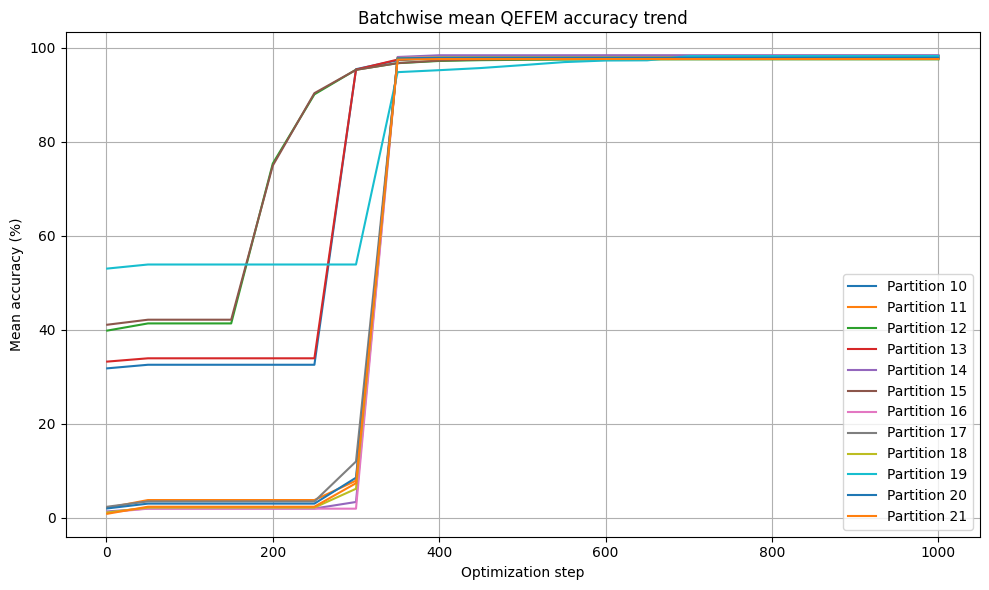

In [178]:
# ------------------------------------------------------------
# Plot 1: Mean accuracy trend by partition
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for partition_id in sorted(partition_step_mean_df["partition"].unique()):
    dfp = partition_step_mean_df[
        partition_step_mean_df["partition"] == partition_id
    ]

    plt.plot(
        dfp["step"],
        dfp["mean_accuracy_percent"],
        label=f"Partition {partition_id}",
    )

plt.xlabel("Optimization step")
plt.ylabel("Mean accuracy (%)")
plt.title("Batchwise mean QEFEM accuracy trend")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_trend_path = PLOT_DIR / "batchwise_mean_accuracy_trend.png"
plt.savefig(accuracy_trend_path, dpi=200)
plt.show()

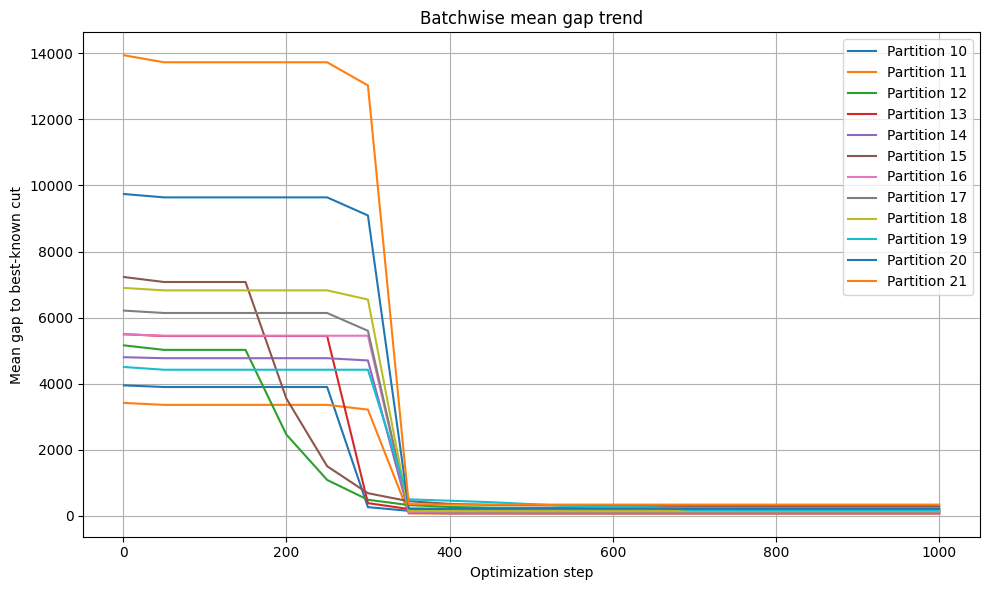

In [179]:
# ------------------------------------------------------------
# Plot 2: Mean gap trend by partition
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for partition_id in sorted(partition_step_mean_df["partition"].unique()):
    dfp = partition_step_mean_df[
        partition_step_mean_df["partition"] == partition_id
    ]

    plt.plot(
        dfp["step"],
        dfp["mean_gap"],
        label=f"Partition {partition_id}",
    )

plt.xlabel("Optimization step")
plt.ylabel("Mean gap to best-known cut")
plt.title("Batchwise mean gap trend")
plt.legend()
plt.grid(True)
plt.tight_layout()

gap_trend_path = PLOT_DIR / "batchwise_mean_gap_trend.png"
plt.savefig(gap_trend_path, dpi=200)
plt.show()

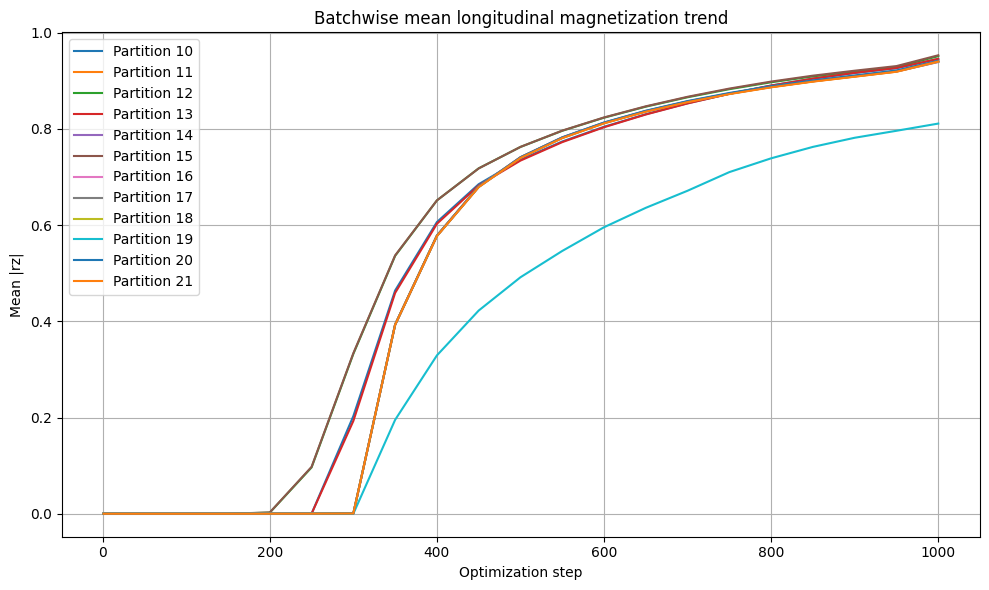

In [181]:
# ------------------------------------------------------------
# Plot 4: Mean |rz| trend by partition
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for partition_id in sorted(partition_step_mean_df["partition"].unique()):
    dfp = partition_step_mean_df[
        partition_step_mean_df["partition"] == partition_id
    ]

    plt.plot(
        dfp["step"],
        dfp["mean_rz_abs"],
        label=f"Partition {partition_id}",
    )

plt.xlabel("Optimization step")
plt.ylabel("Mean |rz|")
plt.title("Batchwise mean longitudinal magnetization trend")
plt.legend()
plt.grid(True)
plt.tight_layout()

rz_trend_path = PLOT_DIR / "batchwise_mean_abs_rz_trend.png"
plt.savefig(rz_trend_path, dpi=200)
plt.show()




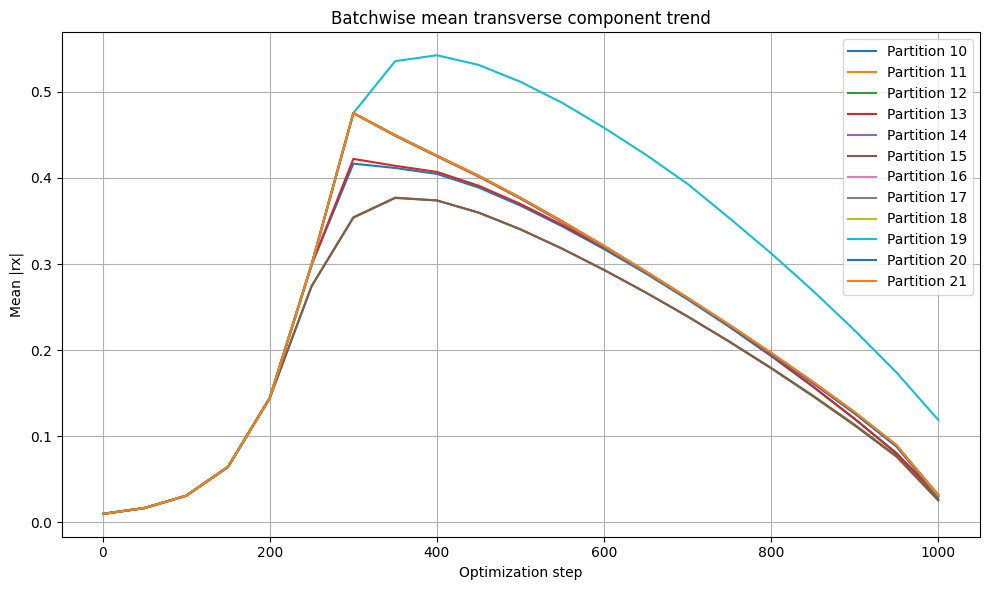

In [182]:
# ------------------------------------------------------------
# Plot 5: Mean |rx| trend by partition
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for partition_id in sorted(partition_step_mean_df["partition"].unique()):
    dfp = partition_step_mean_df[
        partition_step_mean_df["partition"] == partition_id
    ]

    plt.plot(
        dfp["step"],
        dfp["mean_rx_abs"],
        label=f"Partition {partition_id}",
    )

plt.xlabel("Optimization step")
plt.ylabel("Mean |rx|")
plt.title("Batchwise mean transverse component trend")
plt.legend()
plt.grid(True)
plt.tight_layout()

rx_trend_path = PLOT_DIR / "batchwise_mean_abs_rx_trend.png"
plt.savefig(rx_trend_path, dpi=200)
plt.show()

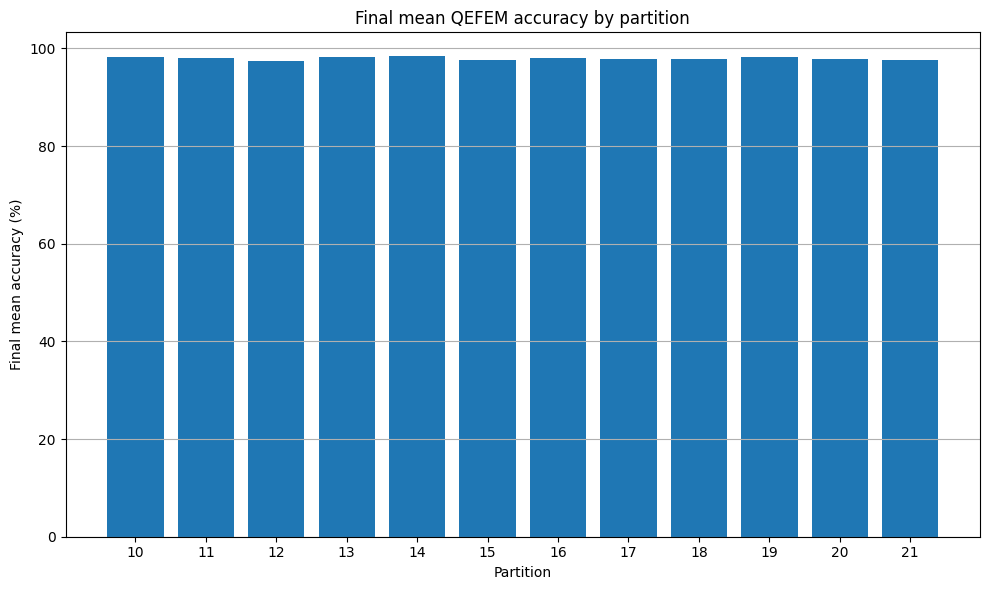

In [183]:
# ------------------------------------------------------------
# Plot 6: Final mean accuracy by partition
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    partition_final_mean_df["partition"].astype(str),
    partition_final_mean_df["mean_accuracy_percent"],
)

plt.xlabel("Partition")
plt.ylabel("Final mean accuracy (%)")
plt.title("Final mean QEFEM accuracy by partition")
plt.grid(True, axis="y")
plt.tight_layout()

final_accuracy_path = PLOT_DIR / "final_mean_accuracy_by_partition.png"
plt.savefig(final_accuracy_path, dpi=200)
plt.show()

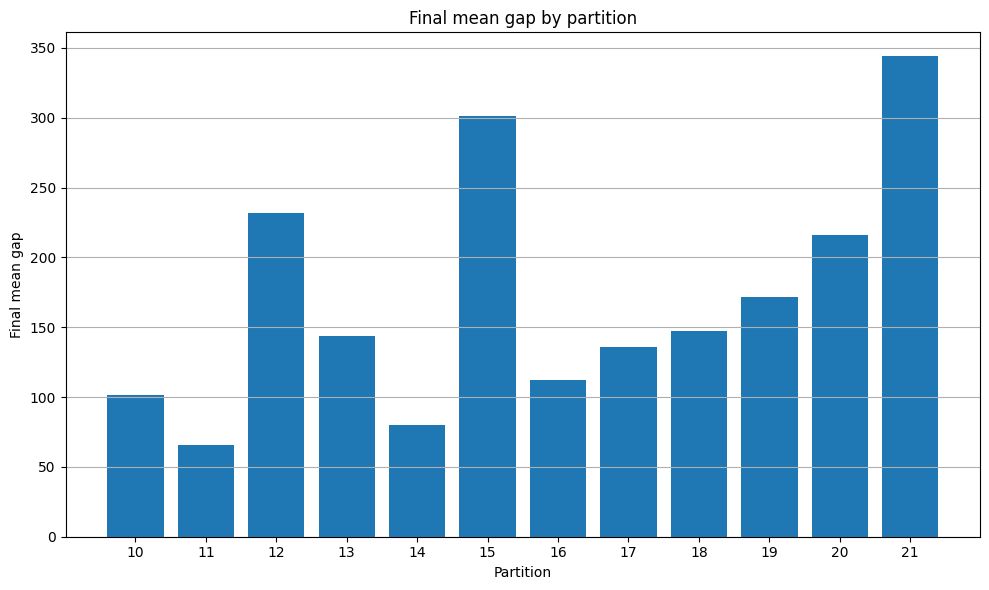


Saved plots:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/plots/batchwise_mean_accuracy_trend.png
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/plots/batchwise_mean_gap_trend.png
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/plots/batchwise_mean_abs_rz_trend.png
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/plots/batchwise_mean_abs_rx_trend.png
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/plots/final_mean_accuracy_by_partition.png
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_big_gset_outputs/plots/final_mean_gap_by_partition.png


In [184]:
# ------------------------------------------------------------
# Plot 7: Final mean gap by partition
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    partition_final_mean_df["partition"].astype(str),
    partition_final_mean_df["mean_gap"],
)

plt.xlabel("Partition")
plt.ylabel("Final mean gap")
plt.title("Final mean gap by partition")
plt.grid(True, axis="y")
plt.tight_layout()

final_gap_path = PLOT_DIR / "final_mean_gap_by_partition.png"
plt.savefig(final_gap_path, dpi=200)
plt.show()


# ------------------------------------------------------------
# Print saved plot paths
# ------------------------------------------------------------

print("\nSaved plots:")
print(accuracy_trend_path.resolve())
print(gap_trend_path.resolve())
print(rz_trend_path.resolve())
print(rx_trend_path.resolve())
print(final_accuracy_path.resolve())
print(final_gap_path.resolve())


# ------------------------------------------------------------
# Final checks
# ------------------------------------------------------------

assert all_history_path.exists()
assert all_summary_path.exists()
assert partition_step_mean_path.exists()
assert partition_final_mean_path.exists()

assert accuracy_trend_path.exists()
assert gap_trend_path.exists()
assert best_cut_trend_path.exists()
assert rz_trend_path.exists()
assert rx_trend_path.exists()
assert final_accuracy_path.exists()
assert final_gap_path.exists()